# MetroPT-3 — Exploratory Data Analysis and Preprocessing (v4)

**PdM-Agent · AI 894 capstone, Group 6 (Project 06)**
Rosh Chathoth Sreedharan · Ashok Reddy Buthukuri · Gayatri Suresh Chaudhari

This notebook is our pass over the MetroPT-3 dataset before any modeling work, and the pipeline that turns the
raw file into model-ready windows. Everything downstream — the detector, the diagnostic checks, the evaluation
harness — reads what this notebook establishes, so every decision here is written down with the evidence
behind it.

### How to read this notebook

The notebook runs top to bottom (*Runtime → Run all*) in a few minutes. It has three parts:

| Part | Sections | What it settles |
|---|---|---|
| **Look at the data** | 1–4 | record count, sampling rate, coverage and gaps, logger freezes, what each of the 15 signals means and how it behaves |
| **Understand the failures** | 5–6 | the failure signature, the two label sources and how they agree, what precedes a failure, which data are healthy |
| **Build the pipeline** | 7–8 | a regular 10 s grid, one zone label per instant, 10-minute windows, 42 features per window, the folds and splits, the leakage checks, and the files saved for modeling |

Section 9 closes with a fact sheet printed from the code (so the numbers are the run's own) and what each
finding feeds in PdM-Agent.

**Names used throughout.** `df` is the raw file as rows; `ts` is the same, indexed by time; `tsu` is `ts`
with the logger freezes removed (Section 2.2), and every analysis from Section 3 on uses `tsu`; `grid` is the
regular 10 s grid of Section 7; `windows` is the window table of Section 8. All times are UTC. A *failure*
without qualification is one of the four air leaks that forced a repair (F1–F4); the maintenance expert's
fuller log, 21 failures, is introduced in Section 5.1 and called *expert-reported*.

**Inputs and outputs.** The raw CSV is fetched from the UCI archive on first run. The label inputs (failure
windows, repair hours, freeze masks, uncertain episodes, the expert's log) are written out in Section 0 and
checked against `profiles/metropt3_apu/events.yaml` v0.3 when that file is present. The outputs go to
`data/processed/` (Section 8.6).

### What changed in v4 (Oct 4, 2026)

Corrected, after the Oct 4 review of the detector-selection run and of this notebook:

- **The three "heavy LPS" uncertain periods were an artifact.** The daily LPS figure multiplied the share of
  *recorded* rows by 24, so a few minutes of low-pressure-switch activity on a day with an hour of data read as
  three or four hours. Counted properly (Section 4), the campaign has no LPS-heavy day that is not a reported
  failure or a restart refill. The periods are gone from `events.yaml` v0.3, and about 250 hours return to the
  healthy pool.
- **The expert's log is now the second label source.** Davari et al. (2021) list 21 failures reported by the
  maintenance expert between April and July; the four UCI labels are the subset that forced a repair. Section 5.1
  matches our continuous-load rule against the log: at 30 minutes it recovers 18 of the 21 with one exception.
  Three readings of v3.3 change with it: the Apr 12 episode we read as heavy demand is the expert's failure #1,
  the May 13 and May 19–20 episodes are failures #6 and #9–10 rather than an early stage of F2, and the Jun 3
  charge we called "a busy hour" is failure #15. The 13 expert failures outside F1–F4 get their own zone
  (Section 7.2), so none of them is training or calibration data any more: #4, #5, #7 and #8 were.
- **The episode finder tolerates short holes and runs at the scale that matches the log.** A single missing
  minute kept F4 out of the 4 h table; runs may now hold up to two missing minutes. At 30 minutes the rule
  recovers 18 of the expert's 21 failures with one exception, so the uncertain periods are now the eight runs of
  30 minutes or more with no report, all in March, before the log begins; v3.3 had the three of 4 hours or more.
- **Freezes are masked in every figure**, including the distributions and the correlation matrix, which still
  held the frozen rows in v3.3.

Added:

- **Section 2.3, restarts:** what the data look like when recording resumes, measured over every restart, as the
  evidence for the gap-edge decision.
- **Features:** the 6-hour shares now need one hour of data instead of three and come with a coverage feature;
  five *state* features describe the last restart; five *leak* features (refill rate, idle pressure loss,
  load-share trend, low-pressure-switch minutes, pressure lost across the last gap) carry what the diagnostic
  checks and the state-aware detector read. 42 features per window, grouped by role in the feature dictionary,
  with the 21 the frozen detector uses flagged.
- **Splits and keys:** the three-way `neg_role` (fit / calibrate / check), an `aligned` flag for non-overlapping
  windows and a `group_id` for grouped validation, written by this notebook rather than re-derived downstream.
- **Scaler:** mean and standard deviation (what the detector uses) beside median and IQR, with the imputation
  medians; the redundancy drop list is a column of the feature dictionary.
- **Data-quality events** (load commanded with the motor off; large pressure losses across gaps) printed in the
  form `events.yaml` takes, so the checks registry reads data rather than a table in a notebook.

Earlier revisions: v3.3 (Sep 27) corrected the Sep 24 run against the raw file — the COMP cycling "precursor"
and two "unlabeled episodes" were logger freezes, the 11–13 s "jitter" was the freezes too — and added the gap
taxonomy, freeze masks, the DV_pressure regime change, the digital-channel readings, the six load episodes, the
window-level healthy count, and Sections 7–8.

## Dataset notes

MetroPT-3 (UCI ML Repository, dataset 791, CC BY 4.0) contains readings from the Air Production Unit (APU)
compressor of a Metro do Porto train, recorded from February 1 to September 1, 2020: 7 analog and 8 digital
channels, 1,516,948 records. Failure information comes from two sources: the operator's maintenance reports
as tabulated in the dataset paper (Veloso et al., 2022, *The MetroPT dataset for predictive maintenance*) and
the UCI description PDF (`data/Data Description_Metro.pdf`), which give the four air leaks that forced a repair;
and the maintenance expert's own log as tabulated by Davari et al. (2021, Table II), which lists 21 failures
between April and July, the four among them.

Two numbers about this dataset circulate in our own documents — 1,516,948 records and 15.2 M readings.
The load cell below checks the file itself; 1,516,948 is the row count we hold ourselves to. The PDF's
15,169,480 instances is exactly ten times the file: the count at the original 1 Hz, before the data were
released at 0.1 Hz.

### Signal dictionary

Descriptions paraphrased from the dataset paper. The last column is what the data shows (Sections 3
and 4); where the two disagree, the diagnostic checks follow the data.

| Signal | Type | Unit | Description (per Veloso et al., 2022) | What the data shows |
|---|---|---|---|---|
| TP2 | analog | bar | Pressure at the compressor | — |
| TP3 | analog | bar | Pressure at the pneumatic panel | Same as Reservoirs to 0.01 bar (3.2) |
| H1 | analog | bar | Pressure drop at the cyclonic separator filter | Mirrors TP2 (r = −0.96) |
| DV_pressure | analog | bar | Pressure drop at the towers' discharge | Flat after the Jun 8 repair (3.1) |
| Reservoirs | analog | bar | Downstream reservoir pressure (tracks TP3) | Same as TP3 |
| Oil_temperature | analog | °C | Compressor oil temperature | — |
| Motor_current | analog | A | Current of one motor phase (~0 off, ~4 A off-load, ~7 A under load) | — |
| COMP | digital | 0/1 | Air-intake valve signal; active when there is no air intake | As described: 0 while loading |
| DV_eletric | digital | 0/1 | Outlet valve signal; active when compressor runs under load | As described; a few hours read 1 with the motor off (5.3) |
| Towers | digital | 0/1 | Which air-drying tower is in service | Switches only under load |
| MPG | digital | 0/1 | Starts the compressor under load when pressure < 8.2 bar | Mirrors COMP |
| LPS | digital | 0/1 | Low-pressure switch; activates below 7 bar | Fires with Reservoirs below 7 bar |
| Pressure_switch | digital | 0/1 | Detects discharge in the drying towers | 0 is the rare event, tied to load |
| Oil_level | digital | 0/1 | Active when oil level is below expected | 0 almost only in August; never during a leak. Its polarity matters for the 2022 campaign, which has an oil leak |
| Caudal_impulses | digital | 0/1 | Flowmeter (airflow) pulse signal | 0 only in March |

(The spellings `DV_eletric` and `Caudal_impulses` are the dataset's own.)

## 0 · Setup

Built to run in **Google Colab**: the data cell fetches MetroPT-3 straight from the UCI archive on first run
(a one-time download of roughly 60 MB). Running locally works the same way; if you already have
`MetroPT3(AirCompressor).csv`, put it next to the notebook or under `data/` and the download is skipped.

The two cells after the imports hold every label input the notebook uses, written out so it runs on its own:
the four failure windows and repair hours from the UCI PDF, the expert's 21 failures, the ten freeze masks, the
three uncertain episodes, the grey period, and the paddings. They are the entries of `events.yaml` v0.3; when
that file is found beside the repository the notebook reads it and prints whether the two agree, so the file
and the notebook cannot drift apart silently. Sections 2.2 and 5.1 re-derive the masks and the episodes from
the data as well.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import LinearSegmentedColormap
from cycler import cycler

pd.set_option('display.width', 120)
pd.set_option('display.max_columns', 40)

# --- data location: edit if your copy lives elsewhere -------------------
_CANDIDATES = [
    Path('MetroPT3(AirCompressor).csv'),
    Path('data/MetroPT3(AirCompressor).csv'),
    Path('../data/MetroPT3(AirCompressor).csv'),
    Path('/content/MetroPT3(AirCompressor).csv'),
]
EVENTS_FILE = next((p for p in [Path('../profiles/metropt3_apu/events.yaml'),
                                Path('profiles/metropt3_apu/events.yaml')] if p.exists()), None)

EXPECTED_RECORDS = 1_516_948   # UCI dataset page (not 15.2 M)

ANALOG = ['TP2', 'TP3', 'H1', 'DV_pressure', 'Reservoirs',
          'Oil_temperature', 'Motor_current']
DIGITAL = ['COMP', 'DV_eletric', 'Towers', 'MPG', 'LPS',
           'Pressure_switch', 'Oil_level', 'Caudal_impulses']
UNITS = {'TP2': 'bar', 'TP3': 'bar', 'H1': 'bar', 'DV_pressure': 'bar',
         'Reservoirs': 'bar', 'Oil_temperature': 'degC', 'Motor_current': 'A'}
T = pd.Timestamp

# --- label source 1: the four air leaks that forced a repair (UCI description PDF,
#     data/Data Description_Metro.pdf, checked to the minute on 2026-09-25). The PDF
#     prints the second repair as "30Apr at 12:00"; it is 30 May. F1 lists no repair.
FAILURE_WINDOWS = [(T(s), T(e), n) for s, e, n in [
    ('2020-04-18 00:00', '2020-04-18 23:59', 'Air leak 1'),
    ('2020-05-29 23:30', '2020-05-30 06:00', 'Air leak 2'),
    ('2020-06-05 10:00', '2020-06-07 14:30', 'Air leak 3'),
    ('2020-07-15 14:30', '2020-07-15 19:00', 'Air leak 4'),
]]
REPAIRS = [None, T('2020-05-30 12:00'), T('2020-06-08 16:00'), T('2020-07-16 00:00')]

# --- label source 2: the maintenance expert's log, 21 failures between April and July
#     (Davari et al., 2021, Table II). Given to the minute; the end minute counts.
#     #2-3, #12-13, #16-18 and #20 are F1-F4; the other 13 forced no repair.
EXPERT_REPORTED = [(n, T('2020-' + a), T('2020-' + b)) for n, (a, b) in enumerate([
    ('04-12 11:50', '04-12 23:30'), ('04-18 00:00', '04-18 23:59'), ('04-19 00:00', '04-19 01:30'),
    ('04-29 03:20', '04-29 04:00'), ('04-29 22:00', '04-29 22:20'), ('05-13 14:00', '05-13 23:59'),
    ('05-18 05:00', '05-18 05:30'), ('05-19 10:10', '05-19 11:00'), ('05-19 22:10', '05-19 23:59'),
    ('05-20 00:00', '05-20 20:00'), ('05-23 09:50', '05-23 10:10'), ('05-29 23:30', '05-29 23:59'),
    ('05-30 00:00', '05-30 06:00'), ('06-01 15:00', '06-01 15:40'), ('06-03 10:00', '06-03 11:00'),
    ('06-05 10:00', '06-05 23:59'), ('06-06 00:00', '06-06 23:59'), ('06-07 00:00', '06-07 14:30'),
    ('07-08 17:30', '07-08 19:00'), ('07-15 14:30', '07-15 19:00'), ('07-17 04:30', '07-17 05:30')], start=1)]
EXPERT_PERIOD = (T('2020-04-01'), T('2020-08-01'))     # the months the log covers

In [2]:
# The exclusion lists of events.yaml v0.3, restated so the notebook runs on its own.
# Sections 2.2 and 5.1 re-derive the freeze masks and the load episodes from the data
# and print whether they still match.

FREEZE_MASKS = [(T(s), T(e)) for s, e in [       # logger freezes (Section 2.2)
    ('2020-04-13 18:29:20', '2020-04-13 19:27:16'),
    ('2020-04-17 09:20:43', '2020-04-18 00:18:07'),
    ('2020-04-20 04:49:17', '2020-04-21 01:16:52'),
    ('2020-05-26 09:19:36', '2020-05-27 13:43:45'),
    ('2020-05-27 13:54:04', '2020-05-28 03:16:28'),
    ('2020-06-12 02:01:56', '2020-06-12 17:00:07'),
    ('2020-06-22 15:06:21', '2020-06-23 02:56:00'),
    ('2020-06-23 02:56:35', '2020-06-25 05:08:35'),
    ('2020-07-21 13:45:12', '2020-07-21 22:03:16'),
    ('2020-07-22 06:43:44', '2020-07-22 13:04:24'),
]]

# Continuous-load runs of 30 min or more with no report in either source (Section 5.1). All
# eight are in March, before the expert's log begins. The tag says whether TP3 fell against the
# prior week or held; both tags take the same policy. v0.2 held three of these (the runs of 4 h
# or more) plus Apr 12, May 13-14 and May 19-20, which the log reports as failures #1, #6 and
# #9-10, and three "heavy LPS" day spans that Section 4 shows were an artifact; those are gone.
UNCERTAIN = [(T(s), T(e), tag) for s, e, tag in [
    ('2020-03-06 21:42:35', '2020-03-06 22:59:53', 'load_held'),
    ('2020-03-11 05:15:30', '2020-03-11 06:10:11', 'probable_leak'),
    ('2020-03-11 18:29:41', '2020-03-11 18:59:14', 'probable_leak'),
    ('2020-03-12 00:16:16', '2020-03-12 11:49:50', 'load_held'),
    ('2020-03-26 04:00:40', '2020-03-26 04:52:52', 'load_held'),
    ('2020-03-27 07:12:20', '2020-03-27 11:38:11', 'load_held'),
    ('2020-03-28 07:22:34', '2020-03-28 08:49:39', 'probable_leak'),
    ('2020-03-28 23:21:14', '2020-03-29 19:49:14', 'probable_leak'),
]]
GREY = [(T('2020-06-08 11:48'), T('2020-06-08 16:00'))]   # data resume before the F3 repair

# Paddings (events.yaml: guard_band, expert_band, healthy_buffer).
GUARD_BEFORE, GUARD_AFTER = pd.Timedelta(hours=24), pd.Timedelta(hours=12)   # F1-F4 are day-granular
EXPERT_BEFORE, EXPERT_AFTER = pd.Timedelta(hours=1), pd.Timedelta(hours=6)   # the log is to the minute;
                                                                              # 6 h after = the gate's hold-off
BUFFER_BEFORE = pd.Timedelta(days=7)    # healthy_buffer.before_failure
BUFFER_AFTER = pd.Timedelta(hours=48)   # healthy_buffer.after_repair, from the repair hour
REGIME_SPLITS = [T('2020-03-01'), T('2020-06-08 16:00')]   # light duty | normal | DV_pressure flat

# --- cross-check against events.yaml v0.3 when the file is beside the repository ---
def _span(entry):
    return T(entry['start']), T(entry['end'])


def _same_spans(from_file, from_notebook, tolerance=pd.Timedelta(minutes=1)):
    """Two span lists agree when they pair up to the minute (the file carries seconds in places)."""
    return len(from_file) == len(from_notebook) and all(
        abs(a[0] - b[0]) < tolerance and abs(a[1] - b[1]) < tolerance and a[2:] == b[2:]
        for a, b in zip(from_file, from_notebook))


if EVENTS_FILE is None:
    print('events.yaml not found beside the notebook: using the lists above as written')
else:
    import yaml
    ev = yaml.safe_load(EVENTS_FILE.read_text())
    if str(ev.get('schema_version')) != '0.3':
        raise SystemExit(f'{EVENTS_FILE} is schema {ev.get("schema_version")}; this notebook carries the v0.3 lists. '
                         'Replace the file with events.yaml v0.3 (or remove it) and run again.')
    checks = {
        'failures': _same_spans([_span(f) for f in ev['failures']], [(s, e) for s, e, _ in FAILURE_WINDOWS]),
        'repairs': [None if f.get('maintenance') is None else T(f['maintenance']) for f in ev['failures']] == REPAIRS,
        'expert_reported': _same_spans([(*_span(r), r['n']) for r in ev['expert_reported']],
                                       [(s, e, n) for n, s, e in EXPERT_REPORTED]),
        'freeze masks': _same_spans([_span(m) for m in ev['data_quality_masks']], FREEZE_MASKS),
        'uncertain periods': _same_spans([(*_span(u), u['tag']) for u in ev['uncertain_periods']], UNCERTAIN),
        'grey periods': _same_spans([_span(x) for x in ev['grey_periods']], GREY),
        'expert band': (ev['expert_band']['before'], ev['expert_band']['after']) == ('1h', '6h'),
    }
    bad = [k for k, ok in checks.items() if not ok]
    print(f'{EVENTS_FILE}: ' + ('every list matches the notebook' if not bad else 'MISMATCH in ' + ', '.join(bad)))

../profiles/metropt3_apu/events.yaml: every list matches the notebook


In [3]:
# Get the data. In Colab (or anywhere with internet) this downloads the
# official zip from UCI on first run; it is skipped once the CSV exists.
import io
import zipfile
import urllib.request

if not any(p.exists() for p in _CANDIDATES):
    print('Downloading MetroPT-3 from the UCI archive ...')
    req = urllib.request.Request(
        'https://archive.ics.uci.edu/static/public/791/metropt+3+dataset.zip',
        headers={'User-Agent': 'Mozilla/5.0'})
    with urllib.request.urlopen(req) as r:
        buf = io.BytesIO(r.read())
    data_dir = Path('data')
    data_dir.mkdir(exist_ok=True)
    with zipfile.ZipFile(buf) as z:
        member = next(m for m in z.namelist() if m.endswith('.csv'))
        extracted = Path(z.extract(member, data_dir))
    target = data_dir / 'MetroPT3(AirCompressor).csv'
    if extracted != target:
        extracted.rename(target)
    print(f'Saved {target}')

DATA_PATH = next((p for p in _CANDIDATES if p.exists()), _CANDIDATES[0])
print(f'Using: {DATA_PATH}')

Using: ../data/MetroPT3(AirCompressor).csv


In [4]:
# Chart style: one restrained palette, hairline grid, red reserved for failures.
SURFACE, GRID = '#fcfcfb', '#e1e0d9'
INK, INK2, MUTED = '#0b0b0b', '#52514e', '#898781'
BLUE, ORANGE, AQUA, YELLOW = '#2a78d6', '#eb6834', '#1baf7a', '#eda100'
CRITICAL = '#d03b3b'
DIVERGING = LinearSegmentedColormap.from_list('div', ['#2a78d6', '#f0efec', '#d03b3b'])

plt.rcParams.update({
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE,
    'axes.edgecolor': '#c3c2b7', 'axes.linewidth': 0.8,
    'axes.grid': True, 'grid.color': GRID, 'grid.linewidth': 0.7,
    'axes.spines.top': False, 'axes.spines.right': False,
    'xtick.color': MUTED, 'ytick.color': MUTED,
    'axes.labelcolor': INK2, 'text.color': INK,
    'font.size': 10, 'axes.titlesize': 11, 'axes.titleweight': 'bold',
    'axes.titlelocation': 'left', 'figure.dpi': 110,
    'axes.prop_cycle': cycler(color=[BLUE, ORANGE, AQUA, YELLOW]),
})


def shade_failures(ax):
    """Red wash over the four report windows (F1-F4)."""
    for s, e, _ in FAILURE_WINDOWS:
        ax.axvspan(s, e, color=CRITICAL, alpha=0.18, lw=0)


def shade_expert(ax):
    """Thin red marks at the expert-reported failures that forced no repair."""
    inside = set()
    for n, s, e in EXPERT_REPORTED:
        if not any(fs <= s <= fe for fs, fe, _ in FAILURE_WINDOWS):
            ax.axvspan(s, e, color=CRITICAL, alpha=0.35, lw=0)

## 1 · Load and first checks

Record count against the UCI figure, time span, and schema. The file is clean in the ordinary sense: no
nulls, no duplicate timestamps, strictly binary digital channels. What is not ordinary is the recording itself
(gaps and freezes), which is Section 2.

In [5]:
df = pd.read_csv(DATA_PATH, index_col=0, parse_dates=['timestamp'])
df = df.sort_values('timestamp').reset_index(drop=True)

match = 'match' if len(df) == EXPECTED_RECORDS else 'MISMATCH -- investigate'
print(f'File:    {DATA_PATH}')
print(f'Records: {len(df):,}  (expected {EXPECTED_RECORDS:,} -> {match})')
print(f'Span:    {df.timestamp.min()}  ->  {df.timestamp.max()}')
print(f'Memory:  {df.memory_usage(deep=True).sum() / 1e6:,.0f} MB')
missing_cols = [c for c in ANALOG + DIGITAL if c not in df.columns]
print('Schema:  all 15 expected signals present' if not missing_cols
      else f'Schema:  MISSING {missing_cols} -- continuing with what is present')

# If the schema ever drifts, analyze the columns that exist rather than crash.
ANALOG = [c for c in ANALOG if c in df.columns]
DIGITAL = [c for c in DIGITAL if c in df.columns]
df.head()

File:    ../data/MetroPT3(AirCompressor).csv
Records: 1,516,948  (expected 1,516,948 -> match)
Span:    2020-02-01 00:00:00  ->  2020-09-01 03:59:50
Memory:  194 MB
Schema:  all 15 expected signals present


,timestamp,TP2,TP3,H1,DV_pressure,Reservoirs,Oil_temperature,Motor_current,COMP,DV_eletric,Towers,MPG,LPS,Pressure_switch,Oil_level,Caudal_impulses
0,2020-02-01 00:00:00,-0.012,9.358,9.340,-0.024,9.358,53.600,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
1,2020-02-01 00:00:10,-0.014,9.348,9.332,-0.022,9.348,53.675,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
2,2020-02-01 00:00:19,-0.012,9.338,9.322,-0.022,9.338,53.600,0.0425,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
3,2020-02-01 00:00:29,-0.012,9.328,9.312,-0.022,9.328,53.425,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
4,2020-02-01 00:00:39,-0.012,9.318,9.302,-0.022,9.318,53.475,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0


In [6]:
# Integrity: digital channels binary? constant columns? duplicate timestamps?
issues = []
for c in DIGITAL:
    vals = set(df[c].dropna().unique())
    if not vals <= {0, 1}:
        issues.append((c, sorted(vals)[:10]))
print('All digital channels are strictly binary (0/1).' if not issues
      else f'Non-binary digital channels: {issues}')

const = [c for c in ANALOG + DIGITAL if df[c].nunique() <= 1]
print('Constant columns:', const if const else 'none')

dup_ts = int(df.timestamp.duplicated().sum())
print(f'Duplicated timestamps: {dup_ts:,}')
print(f'Nulls: {int(df.isna().sum().sum()):,}')
df[ANALOG].describe().T.round(2)

All digital channels are strictly binary (0/1).
Constant columns: none
Duplicated timestamps: 0
Nulls: 0


,count,mean,std,min,25%,50%,75%,max
TP2,1516948.0,1.37,3.25,-0.03,-0.01,-0.01,-0.01,10.68
TP3,1516948.0,8.98,0.64,0.73,8.49,8.96,9.49,10.30
H1,1516948.0,7.57,3.33,-0.04,8.25,8.78,9.37,10.29
DV_pressure,1516948.0,0.06,0.38,-0.03,-0.02,-0.02,-0.02,9.84
Reservoirs,1516948.0,8.99,0.64,0.71,8.49,8.96,9.49,10.30
Oil_temperature,1516948.0,62.64,6.52,15.40,57.78,62.70,67.25,89.05
Motor_current,1516948.0,2.05,2.30,0.02,0.04,0.04,3.81,9.30


## 2 · Sampling rate and coverage

Our sources disagreed between 1 Hz and 0.1 Hz. The timestamps settle it: the median delta is 10 s, an
effective rate of **0.1 Hz**. Real steps are 9–10 s; the 11–13 s steps in the table below are almost all
logger freezes (Section 2.2). Windowing code should mask the freezes first, then resample to a regular 10 s
grid rather than assume one. This number goes into the asset profile, and the proposal's 1 Hz mention was
corrected to match.

Coverage is the other headline: about 82 % of the span is recorded, across 331 gaps totalling roughly 38 days.
Nearly half of the missing time is overnight stops, and most of the rest is 15 long outages (Section 2.1).
Several gaps exceed a full day, and a 21-hour gap starts just before the third failure window ends — repair
downtime, most likely. Windows that straddle a gap are dropped, not bridged (Section 7.1).

In [7]:
dt = df.timestamp.diff().dt.total_seconds().dropna()
step = float(dt.median())      # the nominal sampling step in seconds: 10

print('Most common timestamp deltas (seconds):')
print(dt.value_counts().head(8).rename('count').to_frame())
print()
print(f'Median delta: {step:g} s  ->  effective sampling rate {1 / step:.3g} Hz')

span_s = (df.timestamp.max() - df.timestamp.min()).total_seconds()
print(f'Signal time: {len(df):,} records x {step:g} s '
      f'= {len(df) * step / 86400:,.1f} days over a '
      f'{span_s / 86400:,.1f}-day span ({len(df) * step / span_s:.1%} coverage)')

Most common timestamp deltas (seconds):
             count
timestamp         
10.0       1337521
9.0         128277
12.0         38321
13.0          7988
11.0          4471
21.0            10
19.0             5
22.0             4

Median delta: 10 s  ->  effective sampling rate 0.1 Hz
Signal time: 1,516,948 records x 10 s = 175.6 days over a 213.2-day span (82.4% coverage)


In [8]:
# Gaps: any delta well beyond the median step. GAP_FACTOR x step = 50 s is the profile's
# gap_labels.min_gap. `big` is the gap table every later section reads.
GAP_FACTOR = 5
g = pd.DataFrame({
    'gap_start': df.timestamp.shift(1),
    'gap_end': df.timestamp,
    'delta_s': df.timestamp.diff().dt.total_seconds(),
}).dropna()
big = g[g.delta_s > GAP_FACTOR * step].sort_values('delta_s', ascending=False)

print(f'{len(big)} gaps longer than {GAP_FACTOR}x the median step; '
      f'{big.delta_s.sum() / 3600:,.1f} h missing in total')
print('Ten longest:')
(big.head(10)
    .assign(duration=lambda x: pd.to_timedelta(x.delta_s, unit='s'))
    [['gap_start', 'gap_end', 'duration']]
    .reset_index(drop=True))

331 gaps longer than 5x the median step; 909.5 h missing in total
Ten longest:


,gap_start,gap_end,duration
0,2020-04-25 01:10:51,2020-04-27 01:12:49,2 days 00:01:58
1,2020-06-27 10:53:07,2020-06-28 23:07:43,1 days 12:14:36
2,2020-02-28 23:57:08,2020-03-01 04:00:09,1 days 04:03:01
3,2020-08-04 07:42:28,2020-08-05 08:23:01,1 days 00:40:33
4,2020-05-24 00:39:23,2020-05-25 01:14:14,1 days 00:34:51
5,2020-07-07 15:24:51,2020-07-08 15:20:51,0 days 23:56:00
6,2020-08-22 19:11:44,2020-08-23 18:51:01,0 days 23:39:17
7,2020-05-10 00:31:17,2020-05-10 22:48:58,0 days 22:17:41
8,2020-06-07 14:19:39,2020-06-08 11:48:04,0 days 21:28:25
9,2020-04-01 13:15:40,2020-04-02 09:59:17,0 days 20:43:37


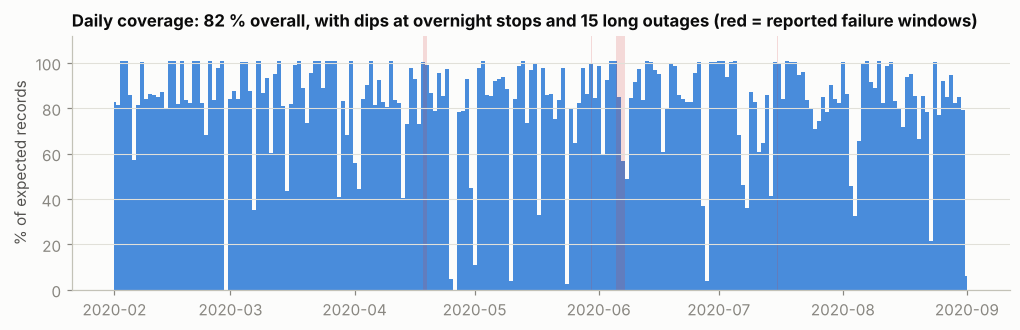

In [9]:
ts = df.set_index('timestamp')
daily = ts.resample('D').size()
expected_daily = 86400 / step

fig, ax = plt.subplots(figsize=(11, 3))
ax.fill_between(daily.index, daily / expected_daily * 100,
                step='mid', color=BLUE, alpha=0.85, lw=0)
shade_failures(ax)
ax.set_ylabel('% of expected records')
ax.set_ylim(0, 112)
ax.set_title('Daily coverage: 82 % overall, with dips at overnight stops and 15 long outages (red = reported failure windows)')
ax.grid(axis='x', visible=False)
plt.show()

### 2.1 · What the gaps are

The gaps fall into three groups. The short dropouts under 3 h add up to little. The gaps of 3–12 h hold nearly
half of the missing time, and most of them start between 19:00 and 03:00 UTC with end times clustered at
04:20–05:05, when service starts: that is the train parked overnight. A day with 75–90 % coverage usually
lost one night stop, not scattered samples. The gaps of 12 h or more are the real outages, and the survival
model should censor at them rather than at every overnight stop.

The clock is fixed UTC. Portugal moved to summer time at 01:00 UTC on 2020-03-29, and the file records straight
through that hour at the normal rate, with no jump and no hole.

In [10]:
# Gap taxonomy: overnight stops vs. outages (`big` = gaps longer than 5x the step).
gap_h = big.delta_s / 3600
short_, mid, long_ = big[gap_h < 3], big[(gap_h >= 3) & (gap_h < 12)], big[gap_h >= 12]
print(pd.DataFrame({'gaps': [len(short_), len(mid), len(long_)],
                    'hours missing': [x.delta_s.sum() / 3600 for x in (short_, mid, long_)]},
                   index=['under 3 h', '3 to 12 h', '12 h or more']).round(1))

night = mid.gap_start.dt.hour.isin([19, 20, 21, 22, 23, 0, 1, 2])
over_by_6 = mid.gap_end.dt.hour < 6
end_clock = mid.gap_end[night].dt.strftime('%H:%M')
print(f'\n3-12 h gaps starting 19:00-03:00 UTC: {night.sum()} of {len(mid)}; '
      f'over by 06:00: {(night & over_by_6).sum()}; '
      f'ending 04:20-05:05: {end_clock.between("04:20", "05:05").sum()}')
print('their end hour (UTC): ' + ', '.join(f'{h}h {n}' for h, n in
                                          end_clock.str[:2].value_counts().sort_index().items()))

# How much of a 75-90 % coverage day is gap time?
cov = daily / expected_daily
dip_days = cov[(cov >= 0.75) & (cov < 0.90)].index
gap_hours = [(big.gap_end.clip(upper=d + pd.Timedelta(days=1))
              - big.gap_start.clip(lower=d)).dt.total_seconds().clip(lower=0).sum() / 3600
             for d in dip_days]
print(f'{len(dip_days)} days with 75-90 % coverage; median gap time on those days: '
      f'{np.median(gap_hours):.1f} h')

# Timezone: Portugal moved to summer time at 2020-03-29 01:00 UTC.
print('\nRows per half hour across the DST change (UTC):')
print(ts.loc['2020-03-28 23:30':'2020-03-29 02:59:59'].resample('30min').size().to_string())

              gaps  hours missing
under 3 h      225          134.8
3 to 12 h       91          435.1
12 h or more    15          339.6

3-12 h gaps starting 19:00-03:00 UTC: 76 of 91; over by 06:00: 57; ending 04:20-05:05: 27
their end hour (UTC): 00h 12, 01h 8, 02h 3, 03h 2, 04h 26, 05h 6, 06h 2, 07h 3, 08h 1, 10h 1, 22h 4, 23h 8
79 days with 75-90 % coverage; median gap time on those days: 4.0 h

Rows per half hour across the DST change (UTC):
timestamp
2020-03-28 23:30:00    182
2020-03-29 00:00:00    182
2020-03-29 00:30:00    181
2020-03-29 01:00:00    182
2020-03-29 01:30:00    181
2020-03-29 02:00:00    182
2020-03-29 02:30:00    182
Freq: 30min


### 2.2 · Logger freezes

The 12 s and 13 s steps in the delta table are not jitter. They come in long runs during which all seven
analog channels repeat the same value exactly while COMP keeps toggling: the logger kept writing rows, but
the analog inputs had stopped updating. We call a run a **freeze** when every analog channel is unchanged
from row to row, every step is 15 s or less, and the run lasts at least 30 minutes. That rule finds ten runs
in eight episodes — about 170 h, 3.3 % of all rows — and they hold 99.5 % of the 11–13 s steps in the file.

Freezes are dangerous, not just noisy. The Jun 22–25 pair holds a *loaded* snapshot (TP2 8.39 bar, 5.58 A)
for 62 h, which looks exactly like the failure signature. And the profile's 30 s bridge rule would let 12 s
frozen data straight through resampling. So freezes are masked explicitly, before any feature is computed,
and excluded from training, scoring and evaluation. From here on every analysis uses `tsu`, the rows outside
the freezes. In operation a freeze is an NE 107 *function check* on the data, not an asset alarm, and the
streaming path needs its own online version of this check (Section 8.5).

In [11]:
def freeze_runs(df, analog, min_minutes=30, max_step_s=15):
    """Runs of rows where every analog channel repeats exactly and every step is <= max_step_s,
    lasting at least min_minutes. Returns one row per run: first, last, size, hours."""
    step = df.timestamp.diff().dt.total_seconds()
    same = (df[analog].diff().abs().sum(axis=1) == 0) & (step <= max_step_s)
    run = (same != same.shift()).cumsum()
    runs = df[same].groupby(run[same]).timestamp.agg(['first', 'last', 'size'])
    runs['hours'] = (runs['last'] - runs['first']).dt.total_seconds() / 3600
    return runs[runs.hours >= min_minutes / 60].reset_index(drop=True)


freezes = freeze_runs(df, ANALOG)
frozen = np.zeros(len(df), dtype=bool)
for first, last in zip(freezes['first'], freezes['last']):
    frozen |= ((df.timestamp >= first) & (df.timestamp <= last)).to_numpy()
df['frozen'] = frozen
ts['frozen'] = frozen          # ts has the same row order as df
tsu = ts[~ts.frozen]           # unfrozen rows: every analysis below uses these


def shade_freezes(ax):
    """Grey wash over the logger freezes."""
    for first, last in zip(freezes['first'], freezes['last']):
        ax.axvspan(first, last, color=MUTED, alpha=0.2, lw=0)


steps = df.timestamp.diff().dt.total_seconds()
odd = steps.between(11, 13)
print(f'{len(freezes)} freeze runs, {freezes.hours.sum():.1f} h, {frozen.sum():,} rows '
      f'({frozen.mean():.1%} of the file)')
print(f'11-13 s steps inside freezes: {(odd & frozen).sum():,} of {odd.sum():,} '
      f'({(odd & frozen).sum() / odd.sum():.1%})')
outside = steps[~frozen].value_counts(normalize=True)
print('steps outside freezes: '
      + ', '.join(f'{s:g} s {p:.1%}' for s, p in outside.head(2).items())
      + f', anything else {1 - outside.head(2).sum():.2%}')
one_s = pd.Timedelta(seconds=1)
matches = len(freezes) == len(FREEZE_MASKS) and all(
    abs(f - s) <= one_s and abs(l - e) <= one_s
    for f, l, (s, e) in zip(freezes['first'], freezes['last'], FREEZE_MASKS))
print('matches the events.yaml v0.3 masks:', 'yes' if matches else 'NO -- update FREEZE_MASKS')

held = ts.loc[freezes['first'], ['TP2', 'Motor_current']].to_numpy()
pd.DataFrame({
    'start': freezes['first'],
    'end': freezes['last'],
    'hours': freezes.hours.round(1),
    'median step (s)': [steps[(df.timestamp > f) & (df.timestamp <= l)].median()
                        for f, l in zip(freezes['first'], freezes['last'])],
    'state held': [('off' if a < 1 else 'loaded' if a > 4.5 else 'off-load')
                   + f' (TP2 {p:.2f} bar, {a:.2f} A)' for p, a in held],
})

10 freeze runs, 169.8 h, 50,677 rows (3.3% of the file)
11-13 s steps inside freezes: 50,536 of 50,780 (99.5%)
steps outside freezes: 10 s 91.2%, 9 s 8.7%, anything else 0.04%
matches the events.yaml v0.3 masks: yes


,start,end,hours,median step (s),state held
0,2020-04-13 18:29:20,2020-04-13 19:27:16,1.0,12.0,"off-load (TP2 0.00 bar, 4.10 A)"
1,2020-04-17 09:20:43,2020-04-18 00:18:07,15.0,12.0,"off (TP2 -0.02 bar, 0.04 A)"
2,2020-04-20 04:49:17,2020-04-21 01:16:52,20.5,12.0,"off-load (TP2 -0.01 bar, 3.92 A)"
3,2020-05-26 09:19:36,2020-05-27 13:43:45,28.4,12.0,"off (TP2 -0.01 bar, 0.04 A)"
4,2020-05-27 13:54:04,2020-05-28 03:16:28,13.4,12.0,"off (TP2 -0.01 bar, 0.04 A)"
5,2020-06-12 02:01:56,2020-06-12 17:00:07,15.0,12.0,"off (TP2 -0.02 bar, 0.04 A)"
6,2020-06-22 15:06:21,2020-06-23 02:56:00,11.8,12.0,"loaded (TP2 8.39 bar, 5.58 A)"
7,2020-06-23 02:56:35,2020-06-25 05:08:35,50.2,12.0,"loaded (TP2 8.39 bar, 5.58 A)"
8,2020-07-21 13:45:12,2020-07-21 22:03:16,8.3,12.0,"off (TP2 -0.01 bar, 0.04 A)"
9,2020-07-22 06:43:44,2020-07-22 13:04:24,6.3,12.0,"off-load (TP2 -0.02 bar, 3.74 A)"


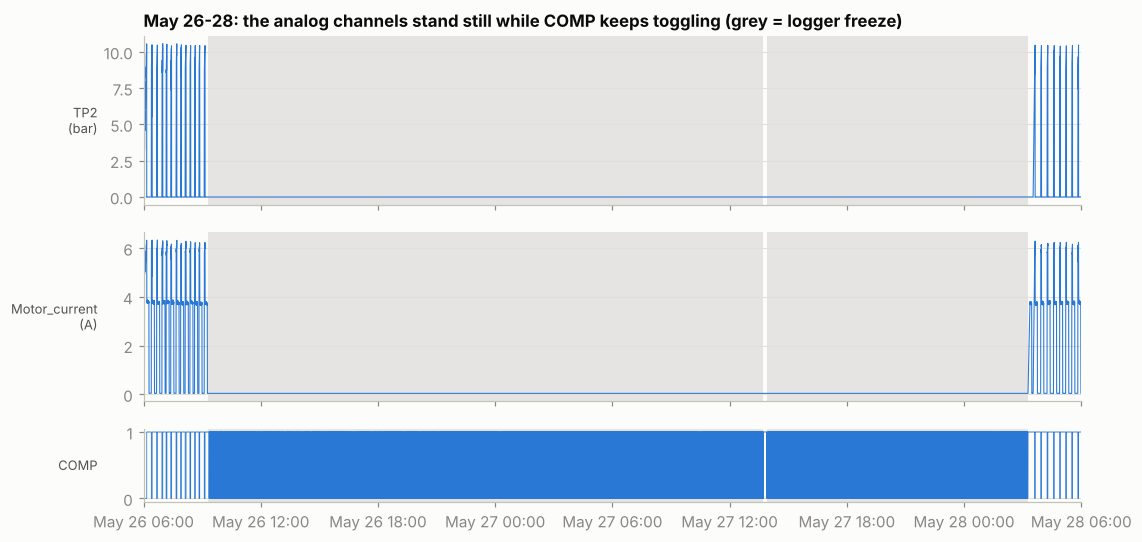

In [12]:
# One freeze episode up close: May 26-28, two runs back to back.
z0, z1 = pd.Timestamp('2020-05-26 06:00'), pd.Timestamp('2020-05-28 06:00')
seg = ts.loc[z0:z1]
fig, axes = plt.subplots(3, 1, figsize=(11, 5.5), sharex=True,
                         gridspec_kw={'height_ratios': [3, 3, 1.3]})
axes[0].plot(seg.index, seg.TP2, color=BLUE, lw=0.7)
axes[1].plot(seg.index, seg.Motor_current, color=BLUE, lw=0.7)
axes[2].step(seg.index, seg.COMP, where='post', color=BLUE, lw=0.5)
axes[2].set_yticks([0, 1])
for ax, label in zip(axes, ['TP2\n(bar)', 'Motor_current\n(A)', 'COMP']):
    ax.set_ylabel(label, rotation=0, ha='right', va='center', fontsize=8.5)
    shade_freezes(ax)
    ax.set_xlim(z0, z1)
    ax.grid(axis='x', visible=False)
axes[0].set_title('May 26-28: the analog channels stand still while COMP keeps toggling '
                  '(grey = logger freeze)')
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%b %d %H:%M'))
fig.align_ylabels(axes)
plt.show()

### 2.3 · Restarts: what the data look like when recording resumes

When the logger comes back after a stop of 30 minutes or more, the compressor is often refilling an empty
panel: pressure is low, the motor runs without a pause until the panel is back at its cut-out level, and the
low-pressure switch is active for the first minutes. That is ordinary behaviour, but it is also what a leak
looks like for a few minutes, so the pipeline has to tell the two apart. Section 7.2 does it with a *gap
edge*, a grey span after every such gap, set in v0.2 at 15 minutes from the share of restarts with TP3 below
its healthy 1st percentile. The detector's false alarms on restarts, though, open 24–25 minutes after data
resume (the earliest the persistence gate allows), so this cell measures the transient directly, over every
restart: pressure and oil at resume, how long the panel takes to reach 8 bar, and how long the motor runs before
its first rest, which is where the refill ends. Half the restarts resume with the panel near empty. Pressure is
back at 8 bar within ten minutes in nine such restarts out of ten, so the 15-minute edge covers the pressure
transient; but the refill run lasts longer, a median of 13 minutes and 19 at the 90th percentile, and in about
one restart in five the motor has not rested when the edge ends, in one in ten not when the first alarm can
open. That is what the detector reacts to: a run without a rest, which Section 5.1 shows is a failure almost
everywhere else. These numbers are the evidence for the gap-edge decision, which is open at the sync: keep the
fixed 15 minutes and leave restarts to the agent's restart check, or make the edge state-based, grey until the
motor's first rest after resume, capped at 30 minutes.

190 restarts after gaps of 30 min or more; TP3 at resume below its 1st percentile (7.87 bar) in 56% of them, below 7 bar in 50%; motor loaded at the first sample in 74%
                   count  mean   std   min   10%   50%   90%   max  never within 2 h
TP3 at resume      190.0   6.6   3.0   0.7   2.6   7.0   9.9  10.2               NaN
oil at resume      190.0  45.2  13.7  15.4  28.8  44.3  65.3  73.0               NaN
min to 8 bar       186.0   3.0   6.7   0.0   0.0   0.8   7.0  56.0               4.0
min to first rest  177.0  11.4   9.5   0.0   4.2  10.4  17.0  86.2              13.0

restarts with TP3 below 8 bar at resume: 108; their time to 8 bar: median 4 min, 90th percentile 10 min; their time to the first rest: median 13 min, 90th percentile 19 min
restarts where the motor had not rested 24 min after resume (the earliest a gated alarm can open): 11%; after 15 min (the gap edge): 22%


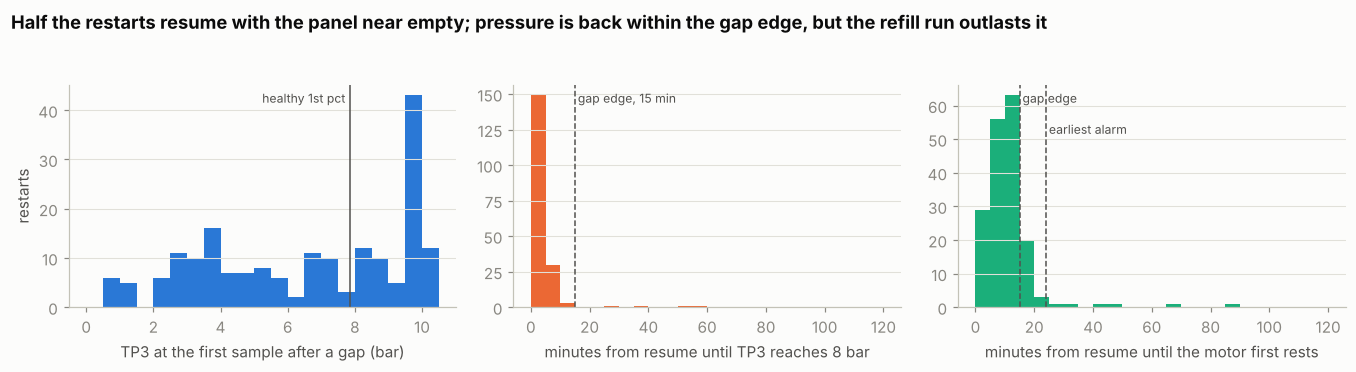

In [13]:
STOP_MIN = pd.Timedelta(minutes=30)                      # a recording gap this long counts as a stop
stops = big[big.delta_s >= STOP_MIN.total_seconds()].sort_values('gap_end')
RECOVER_BAR = 8.0                                        # the panel's normal operating band starts here

rows = []
for gs, ge, d in stops[['gap_start', 'gap_end', 'delta_s']].itertuples(index=False):
    after = tsu.loc[ge: ge + pd.Timedelta(hours=2)]       # the first two hours after data resume
    if len(after) == 0:
        continue
    recovered = after.index[(after.TP3 >= RECOVER_BAR).to_numpy()]
    rested = after.index[(after.Motor_current < 1).to_numpy()]        # the refill run ends at the first rest
    rows.append({'resume': ge, 'gap_h': d / 3600, 'TP3 at resume': after.TP3.iloc[0],
                 'oil at resume': after.Oil_temperature.iloc[0],
                 'min to 8 bar': (recovered[0] - ge).total_seconds() / 60 if len(recovered) else np.nan,
                 'min to first rest': (rested[0] - ge).total_seconds() / 60 if len(rested) else np.nan,
                 'loaded at resume': after.Motor_current.iloc[0] > 4.5})
restarts = pd.DataFrame(rows)
p1_tp3 = tsu.TP3.quantile(0.01)
low_at_resume = restarts['TP3 at resume'] < p1_tp3
print(f'{len(restarts)} restarts after gaps of 30 min or more; TP3 at resume below its 1st percentile '
      f'({p1_tp3:.2f} bar) in {low_at_resume.mean():.0%} of them, below 7 bar in '
      f'{(restarts["TP3 at resume"] < 7).mean():.0%}; motor loaded at the first sample in '
      f'{restarts["loaded at resume"].mean():.0%}')
summary = restarts[['TP3 at resume', 'oil at resume', 'min to 8 bar', 'min to first rest']].describe(percentiles=[.1, .5, .9]).T
summary['never within 2 h'] = [np.nan, np.nan, restarts['min to 8 bar'].isna().sum(), restarts['min to first rest'].isna().sum()]
print(summary.round(1).to_string())
empty = restarts['TP3 at resume'] < RECOVER_BAR
print(f"\nrestarts with TP3 below {RECOVER_BAR:.0f} bar at resume: {empty.sum()}; their time to {RECOVER_BAR:.0f} bar: median "
      f"{restarts.loc[empty, 'min to 8 bar'].median():.0f} min, 90th percentile {restarts.loc[empty, 'min to 8 bar'].quantile(0.9):.0f} min; "
      f"their time to the first rest: median {restarts.loc[empty, 'min to first rest'].median():.0f} min, "
      f"90th percentile {restarts.loc[empty, 'min to first rest'].quantile(0.9):.0f} min")
print(f"restarts where the motor had not rested 24 min after resume (the earliest a gated alarm can open): "
      f"{(restarts['min to first rest'].fillna(999) > 24).mean():.0%}; after 15 min (the gap edge): "
      f"{(restarts['min to first rest'].fillna(999) > 15).mean():.0%}")

fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.4))
axes[0].hist(restarts['TP3 at resume'].dropna(), bins=np.arange(0, 11, 0.5), color=BLUE, lw=0)
axes[0].axvline(p1_tp3, color=INK2, lw=1)
axes[0].text(p1_tp3 - 0.15, axes[0].get_ylim()[1] * 0.92, 'healthy 1st pct', ha='right', fontsize=8, color=INK2)
axes[0].set_xlabel('TP3 at the first sample after a gap (bar)')
axes[0].set_ylabel('restarts')
axes[1].hist(restarts['min to 8 bar'].dropna(), bins=np.arange(0, 125, 5), color=ORANGE, lw=0)
axes[1].axvline(15, color=INK2, lw=1, ls='--')
axes[1].text(16, axes[1].get_ylim()[1] * 0.92, 'gap edge, 15 min', fontsize=8, color=INK2)
axes[1].set_xlabel(f'minutes from resume until TP3 reaches {RECOVER_BAR:.0f} bar')
axes[2].hist(restarts['min to first rest'].dropna(), bins=np.arange(0, 125, 5), color=AQUA, lw=0)
for x, label in [(15, 'gap edge'), (24, 'earliest alarm')]:
    axes[2].axvline(x, color=INK2, lw=1, ls='--')
    axes[2].text(x + 1, axes[2].get_ylim()[1] * (0.92 if x == 15 else 0.78), label, fontsize=8, color=INK2)
axes[2].set_xlabel('minutes from resume until the motor first rests')
for ax in axes:
    ax.grid(axis='x', visible=False)
fig.suptitle('Half the restarts resume with the panel near empty; pressure is back within the gap edge, but the refill run outlasts it',
             x=0.01, ha='left', fontweight='bold')
fig.tight_layout(rect=(0, 0, 1, 0.93))
plt.show()

## 3 · Analog signals

Distributions first, then the whole period at a glance, then one hour of raw signal, and finally the
correlation structure, all on the unfrozen rows. Four things stand out:

- Normal operation is **short load bursts** — the compressor is under load only ~16 % of the time (the hour of
  raw signal below shows a single two-minute charge in an hour). That is what makes TP2 and Motor_current
  strongly bimodal, plain thresholds useless, and reconstruction-based detection attractive.
- **February is a different operating regime**: light duty throughout, LPS silent, and the shift happens
  across the Feb 28 – Mar 1 gap. The detector should not be fit on February alone, and train/validation
  splits should respect the regime change.
- **DV_pressure changes regime at the Jun 8 repair** (Section 3.1), a second boundary the splits have to respect.
- **TP3 and Reservoirs are duplicates** (r = 1.00): one of them suffices as a detector input. Their divergence
  is a free sensor-health check, but it never fires in 2020 (Section 3.2). TP2 and H1 mirror each other
  (r = −0.96), so H1 adds little linear information — but its failure behavior (Section 5) is the crispest
  signature in the dataset.

In the seven-month chart the freezes are the grey bands; with their rows removed they show as gaps in the line.

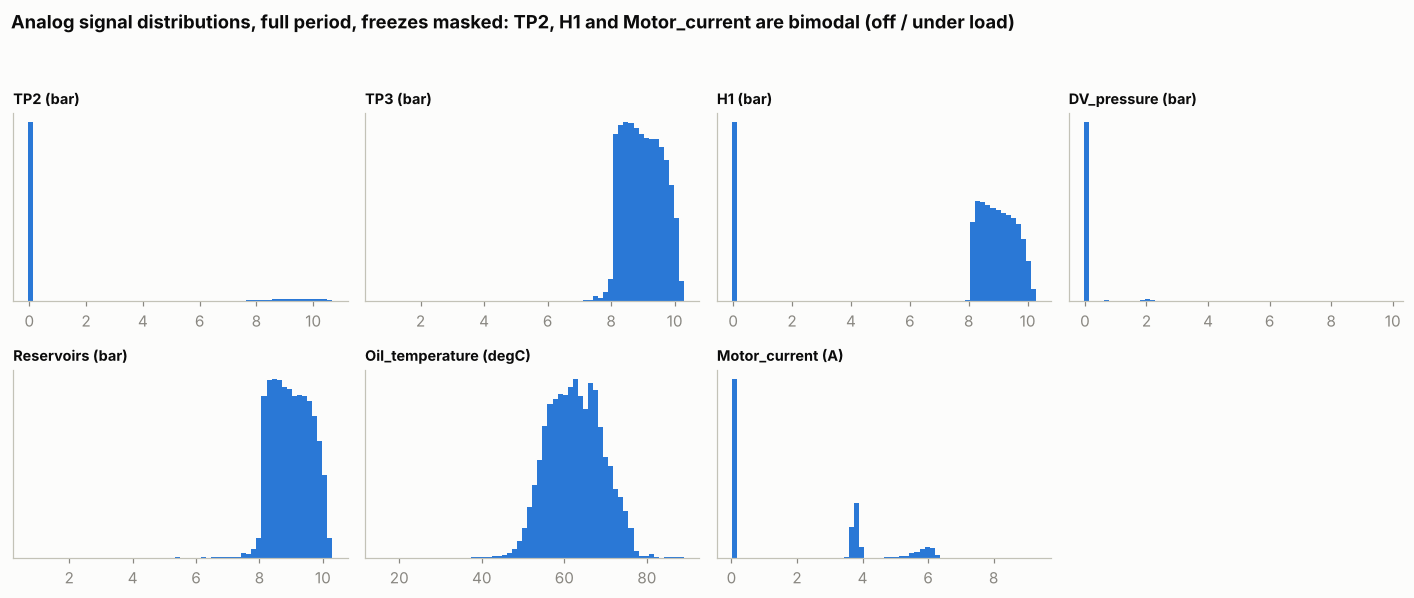

In [14]:
fig, axes = plt.subplots(2, 4, figsize=(13, 5.5))
for ax, c in zip(axes.flat, ANALOG):
    ax.hist(tsu[c].dropna(), bins=60, color=BLUE, lw=0)
    ax.set_title(f'{c} ({UNITS[c]})', fontsize=9.5)
    ax.set_yticks([])
    ax.grid(axis='x', visible=False)
axes.flat[-1].axis('off')
fig.suptitle('Analog signal distributions, full period, freezes masked: TP2, H1 and Motor_current are bimodal (off / under load)',
             x=0.01, ha='left', fontweight='bold')
fig.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

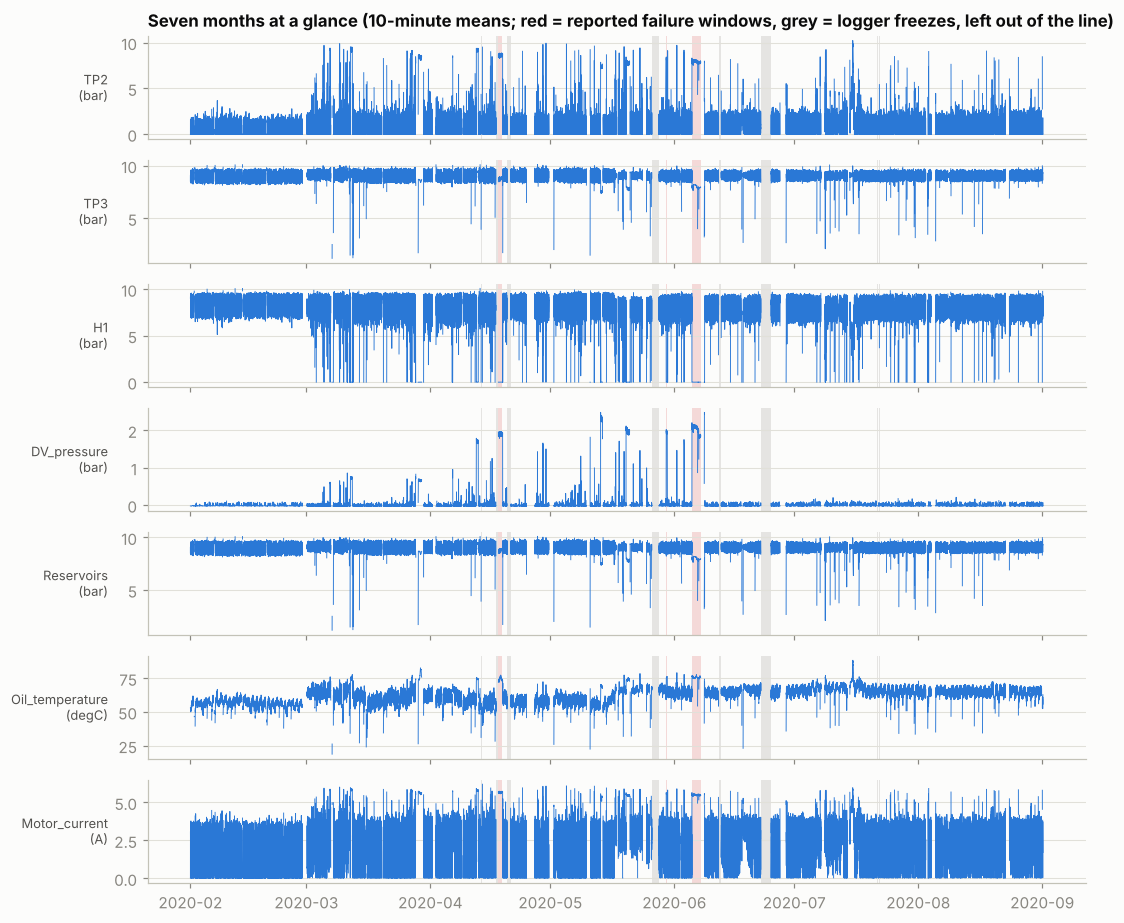

In [15]:
res = tsu[ANALOG].resample('10min').mean()
fig, axes = plt.subplots(len(ANALOG), 1, figsize=(11, 10), sharex=True)
for ax, c in zip(axes, ANALOG):
    ax.plot(res.index, res[c], color=BLUE, lw=0.6)
    shade_failures(ax)
    shade_freezes(ax)
    ax.set_ylabel(f'{c}\n({UNITS[c]})', rotation=0, ha='right',
                  va='center', fontsize=8.5)
    ax.grid(axis='x', visible=False)
axes[0].set_title('Seven months at a glance (10-minute means; red = reported failure windows, '
                  'grey = logger freezes, left out of the line)')
fig.align_ylabels(axes)
plt.show()

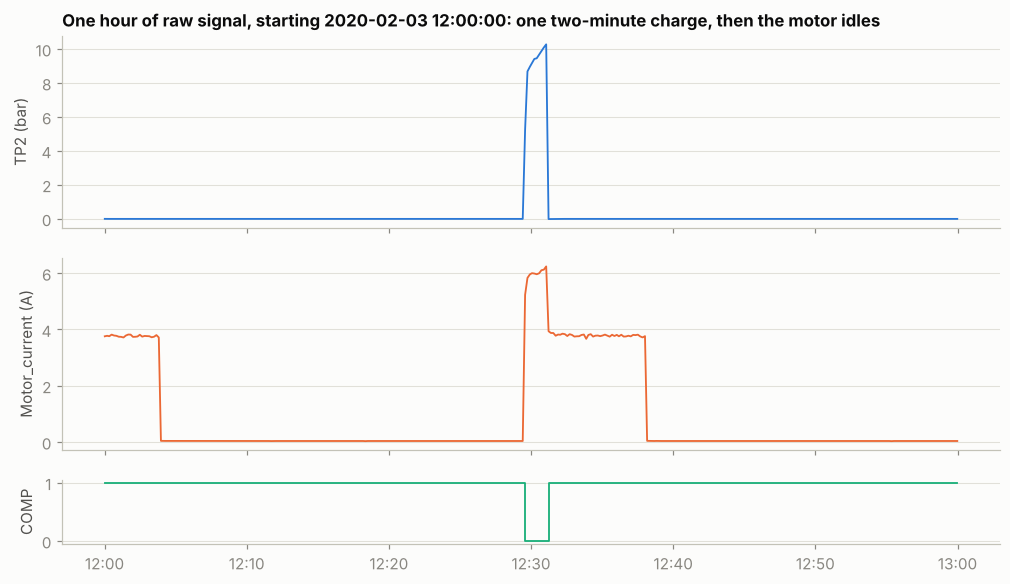

In [16]:
# One hour of raw signal: pick an early hour with near-complete coverage.
hourly = tsu.resample('h').size()
full_hours = hourly[hourly >= 0.95 * 3600 / step]
zoom_start = (full_hours.index[min(48, len(full_hours) - 1)]
              if len(full_hours) else tsu.index[0])
zoom = tsu.loc[zoom_start: zoom_start + pd.Timedelta(hours=1)]

fig, axes = plt.subplots(3, 1, figsize=(11, 6), sharex=True,
                         gridspec_kw={'height_ratios': [3, 3, 1]})
axes[0].plot(zoom.index, zoom.TP2, color=BLUE, lw=1.2)
axes[0].set_ylabel('TP2 (bar)')
axes[1].plot(zoom.index, zoom.Motor_current, color=ORANGE, lw=1.2)
axes[1].set_ylabel('Motor_current (A)')
axes[2].step(zoom.index, zoom.COMP, where='post', color=AQUA, lw=1.2)
axes[2].set_ylabel('COMP')
axes[2].set_yticks([0, 1])
axes[0].set_title(f'One hour of raw signal, starting {zoom_start}: one two-minute charge, then the motor idles')
for ax in axes:
    ax.grid(axis='x', visible=False)
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.show()

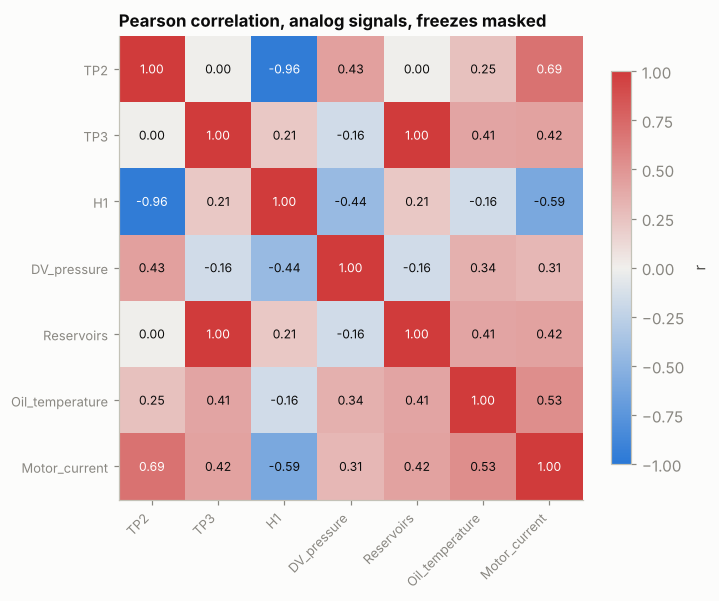

In [17]:
corr = tsu[ANALOG].corr()
n = len(ANALOG)
fig, ax = plt.subplots(figsize=(6.8, 5.8))
im = ax.imshow(corr, cmap=DIVERGING, vmin=-1, vmax=1)
ax.set_xticks(range(n), ANALOG, rotation=45, ha='right', fontsize=8.5)
ax.set_yticks(range(n), ANALOG, fontsize=8.5)
for i in range(n):
    for j in range(n):
        v = corr.iloc[i, j]
        ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=8,
                color='#0b0b0b' if abs(v) < 0.65 else '#ffffff')
ax.set_title('Pearson correlation, analog signals, freezes masked')
ax.grid(False)
fig.colorbar(im, ax=ax, shrink=0.8, label='r')
plt.show()

### 3.1 · DV_pressure goes flat after the Jun 8 repair

DV_pressure carries signal until the F3 repair on Jun 8 at 16:00, then goes flat: its 99th percentile drops
from about 2.2 bar to zero, and the share of samples above 0.5 bar from 7 % to 0.2 %. F1–F3 all fall before
the change and F4 after it, so the channel has two different "normals". A fit weighted toward either side will
score the other side's ordinary load cycles as anomalies. We drop DV_pressure from the detector inputs (or,
if the healthy fit suffers, split the fit at Jun 8 16:00) and keep the boundary as a regime in `events.yaml`.

                            before Jun 8 16:00  after
99th percentile (bar)                     2.21  -0.01
% of samples above 0.5 bar                7.30   0.20


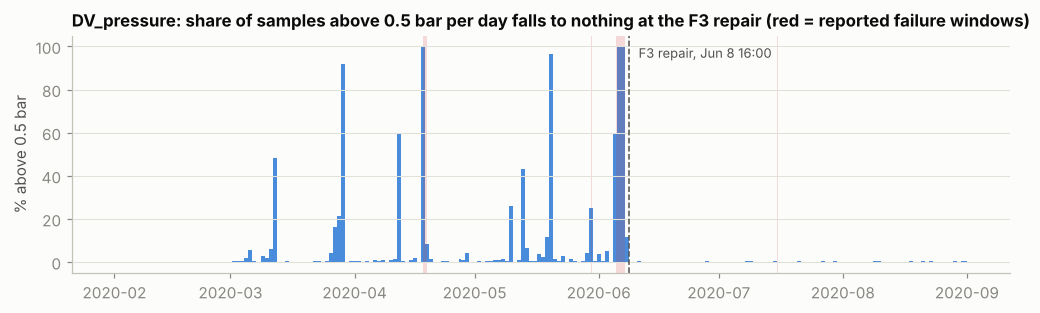

In [18]:
split = REGIME_SPLITS[1]
before = tsu.DV_pressure[tsu.index < split]
after = tsu.DV_pressure[tsu.index >= split]
print(pd.DataFrame({'before Jun 8 16:00': [before.quantile(0.99), (before > 0.5).mean() * 100],
                    'after': [after.quantile(0.99), (after > 0.5).mean() * 100]},
                   index=['99th percentile (bar)', '% of samples above 0.5 bar']).round(2))

daily_dv = (tsu.DV_pressure > 0.5).resample('D').mean() * 100
fig, ax = plt.subplots(figsize=(11, 2.8))
ax.fill_between(daily_dv.index, daily_dv, step='mid', color=BLUE, alpha=0.85, lw=0)
shade_failures(ax)
ax.axvline(split, color=INK2, lw=1, ls='--')
ax.annotate('F3 repair, Jun 8 16:00', (split, 0.96), xycoords=('data', 'axes fraction'),
            xytext=(6, 0), textcoords='offset points', color=INK2, fontsize=8.5, va='top')
ax.set_ylabel('% above 0.5 bar')
ax.set_title('DV_pressure: share of samples above 0.5 bar per day falls to nothing at the F3 repair (red = reported failure windows)')
ax.grid(axis='x', visible=False)
plt.show()

### 3.2 · TP3 vs Reservoirs: the divergence check never fires

The two channels agree to within 0.010 bar at the 99.9th percentile. Only three rows in seven months differ
by more than 0.1 bar, and never two in a row, so the profile's rule (more than 0.1 bar, sustained over 10
minutes) never fires on 2020 data. The check stays, since it costs nothing, but Journey C will need injected
sensor faults to exercise it.

In [19]:
div = (tsu.TP3 - tsu.Reservoirs).abs()
wide = div > 0.1
print(f'|TP3 - Reservoirs|: 99.9th percentile {div.quantile(0.999):.3f} bar; '
      f'rows above 0.1 bar: {wide.sum()}; two in a row: '
      f'{(wide & wide.shift(fill_value=False)).sum()}')
tsu.loc[wide, ['TP3', 'Reservoirs']]

|TP3 - Reservoirs|: 99.9th percentile 0.010 bar; rows above 0.1 bar: 3; two in a row: 0


,TP3,Reservoirs
timestamp,,
2020-03-12 11:59:34,8.296,8.466
2020-04-06 10:02:19,4.728,4.910
2020-05-16 23:25:44,6.606,6.768


## 4 · Digital signals

Duty cycles over the whole period first, then the cycling and low-pressure story. Three findings:

- **The digital channels mostly mean what the paper says.** Section 4.1 reads each one against the analog
  signals. COMP, DV_eletric, MPG and LPS behave as described, and the odd duty cycles have plain explanations:
  Towers only switches while the compressor is loaded, Pressure_switch's eventful state is 0, and Oil_level
  and Caudal_impulses drop to 0 almost only within single months (August and March) and never at a failure.
- **Cycling rate is not a precursor.** The raw count spikes to 380–1,400 cycles a day on seven days, and our
  first run read that as warning before F1 and F2. All seven days sit inside logger freezes (Section 2.2),
  where COMP chatters while the analog channels stand still. With freezes masked, those days show 0–55 cycles
  against a campaign median of 55, and none of the four failures is preceded by elevated cycling (table below).
  The lead-time evidence we do have is in load share (Section 5.2).
- **Low-pressure-switch activity is minutes, not hours.** Our earlier runs reported "heavy LPS days" and made
  three of them uncertain periods. The figure behind that multiplied the share of *recorded* rows by 24, so on
  a day with an hour of data, ten minutes of LPS read as four hours. Counted as rows × 10 s, no day in the
  campaign reaches an hour of LPS except two reported failures (Jul 15 and Jul 17), and every day above
  20 minutes is a reported failure, a restart refilling the panel after a recording gap, or load commanded
  with the motor off (table below). The three periods are gone from `events.yaml` v0.3; the yellow bands in the figure mark where
  they were.

One caveat stands: at a 10 s sampling interval, cycles shorter than a couple of samples alias, so cycle
counts are a lower bound.

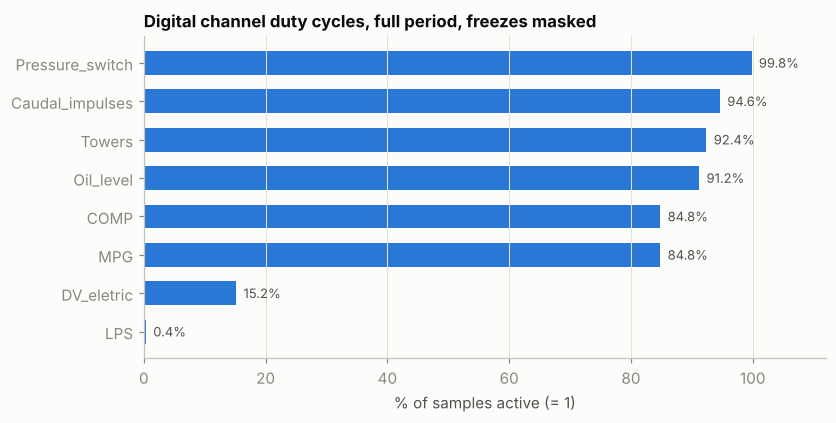

In [20]:
duty = tsu[DIGITAL].mean().sort_values() * 100
fig, ax = plt.subplots(figsize=(8, 3.8))
ax.barh(duty.index, duty, color=BLUE, height=0.62)
for y, v in enumerate(duty):
    ax.text(v + 1.2, y, f'{v:.1f}%', va='center', fontsize=8.5, color=INK2)
ax.set_xlabel('% of samples active (= 1)')
ax.set_xlim(0, 112)
ax.set_title('Digital channel duty cycles, full period, freezes masked')
ax.grid(axis='y', visible=False)
plt.show()

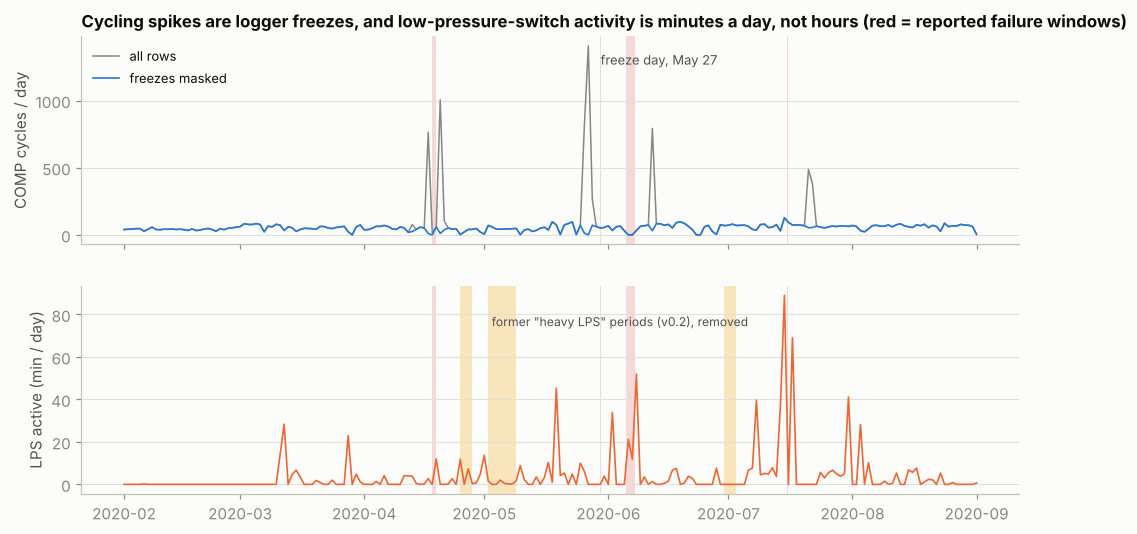

In [21]:
# COMP cycles per day, with and without the freezes; LPS minutes per day, counted as rows x 10 s.
flip = ts.COMP.diff().abs() == 1
both_live = ~ts.frozen & ~ts.frozen.shift(fill_value=False)
has_rows = ts.COMP.resample('D').size() > 0
comp_raw = (flip.resample('D').sum() / 2)[has_rows]
comp_cycles = ((flip & both_live).resample('D').sum() / 2)[has_rows]
lps_minutes = tsu.LPS.resample('D').sum() * step / 60          # minutes of LPS = 1 per day
lps_inflated = tsu.LPS.resample('D').mean() * 24                # the v3.3 figure: share of recorded rows x 24 "hours"
FORMER_LPS_PERIODS = [(T('2020-04-25'), T('2020-04-28')), (T('2020-05-02'), T('2020-05-09')),
                      (T('2020-06-30'), T('2020-07-03'))]     # the v0.2 lps_heavy spans, removed in v0.3

fig, axes = plt.subplots(2, 1, figsize=(11, 5.4), sharex=True)
axes[0].plot(comp_raw.index, comp_raw, color=MUTED, lw=1.0, label='all rows')
axes[0].plot(comp_cycles.index, comp_cycles, color=BLUE, lw=1.1, label='freezes masked')
peak = comp_raw.idxmax()
axes[0].annotate(f'freeze day, {peak:%b %d}', (peak, comp_raw.max()), xytext=(8, -4),
                 textcoords='offset points', color=INK2, fontsize=8.5, va='top')
axes[0].legend(loc='upper left', frameon=False, fontsize=8.5)
axes[0].set_ylabel('COMP cycles / day')
axes[1].plot(lps_minutes.index, lps_minutes, color=ORANGE, lw=1.1)
for a, b in FORMER_LPS_PERIODS:
    axes[1].axvspan(a, b, color=YELLOW, alpha=0.25, lw=0)
axes[1].text(FORMER_LPS_PERIODS[1][0], lps_minutes.max() * 0.9, ' former "heavy LPS" periods (v0.2), removed',
             fontsize=8, color=INK2, va='top')
axes[1].set_ylabel('LPS active (min / day)')
for ax in axes:
    shade_failures(ax)
    ax.grid(axis='x', visible=False)
axes[0].set_title('Cycling spikes are logger freezes, and low-pressure-switch activity is minutes a day, not hours '
                  '(red = reported failure windows)')
plt.show()

In [22]:
spikes = comp_raw[comp_raw >= 300]
print('Days with 300 or more raw cycles, and the same days with freezes masked:')
print(pd.DataFrame({'all rows': spikes, 'freezes masked': comp_cycles[spikes.index]})
        .astype(int).rename(index=lambda d: d.strftime('%b %d')).rename_axis(None).to_string())
print(f'\nFreezes masked, whole campaign: median {comp_cycles.median():.0f} cycles/day, '
      f'95th percentile {comp_cycles.quantile(0.95):.0f}')
print('\nCycles on the three days before each reported failure (freezes masked):')
pre_days = {name: [comp_cycles.get(s.normalize() - pd.Timedelta(days=k)) for k in (3, 2, 1)]
            for s, e, name in FAILURE_WINDOWS}
pd.DataFrame(pre_days, index=['3 days before', '2 days before', 'day before']).T.astype(int)

Days with 300 or more raw cycles, and the same days with freezes masked:
        all rows  freezes masked
Apr 17       764              10
Apr 20      1006              11
May 26       806              13
May 27      1407               0
Jun 12       793              31
Jul 21       488              53
Jul 22       381              55

Freezes masked, whole campaign: median 55 cycles/day, 95th percentile 83

Cycles on the three days before each reported failure (freezes masked):


,3 days before,2 days before,day before
Air leak 1,58,51,10
Air leak 2,13,0,72
Air leak 3,33,61,65
Air leak 4,58,76,30


In [23]:
# Where the LPS activity is: every LPS = 1 sample gets one cause, highest precedence first.
one_min = pd.Timedelta(minutes=1)
lps_rows = tsu.index[(tsu.LPS == 1).to_numpy()]
cause = np.full(len(lps_rows), 'other', dtype=object)
gaps5m = big[big.delta_s >= 300].sort_values('gap_end')                   # recording gaps of 5 min or more
resume_times = gaps5m.gap_end.to_numpy()
k = np.searchsorted(resume_times, lps_rows.to_numpy(), side='right') - 1
since_resume = (lps_rows.to_numpy() - resume_times[np.maximum(k, 0)]) / np.timedelta64(1, 'm')
cause[(k >= 0) & (since_resume <= 30)] = 'restart refill'                 # the panel refilling after a gap
stop_times = np.sort(gaps5m.gap_start.to_numpy())
j = np.searchsorted(stop_times, lps_rows.to_numpy(), side='left')
until_stop = (stop_times[np.minimum(j, len(stop_times) - 1)] - lps_rows.to_numpy()) / np.timedelta64(1, 'm')
cause[(j < len(stop_times)) & (until_stop <= 30) & (cause == 'other')] = 'pressure falling before a gap'
cmd_rows = ((tsu.DV_eletric == 1) & (tsu.Motor_current < 1)).to_numpy()[(tsu.LPS == 1).to_numpy()]
cause[cmd_rows] = 'load commanded, motor off'
for s, e, tag in UNCERTAIN:
    cause[(lps_rows >= s) & (lps_rows <= e)] = 'March episode (uncertain)'
for n, s, e in EXPERT_REPORTED:
    cause[(lps_rows >= s) & (lps_rows <= e + one_min)] = f'expert-reported #{n}'
for s, e, name in FAILURE_WINDOWS:
    cause[(lps_rows >= s) & (lps_rows <= e)] = name.replace('Air leak ', 'F')
by_day = pd.DataFrame({'cause': cause}, index=lps_rows).groupby([lps_rows.floor('D'), 'cause']).size().unstack(fill_value=0)
busy = lps_minutes[lps_minutes >= 20].index
table = pd.DataFrame({
    'LPS minutes': lps_minutes[busy].round(0).astype(int),
    'hours of data': (tsu.LPS.resample('D').size()[busy] * step / 3600).round(1),
    'v3.3 figure ("h/day")': lps_inflated[busy].round(2),
    'main cause': [by_day.loc[d].idxmax() if d in by_day.index else '' for d in busy],
    'share of the day\'s LPS': [f'{by_day.loc[d].max() / by_day.loc[d].sum():.0%}' if d in by_day.index else '' for d in busy],
}).rename(index=lambda d: d.strftime('%b %d')).rename_axis(None)
print(f'days with 20 min or more of LPS: {len(busy)} of {int((lps_minutes > 0).sum())} days with any; '
      f'days with an hour or more: {int((lps_minutes >= 60).sum())}')
display(table)
print('the v0.2 "heavy LPS" spans, counted as rows x 10 s: '
      + '; '.join(f'{a:%b %d}-{(b - pd.Timedelta(days=1)):%b %d}: {lps_minutes.loc[a:b - pd.Timedelta(days=1)].max():.0f} min on the busiest day'
                  for a, b in FORMER_LPS_PERIODS))

days with 20 min or more of LPS: 12 of 95 days with any; days with an hour or more: 2
the v0.2 "heavy LPS" spans, counted as rows x 10 s: Apr 25-Apr 27: 12 min on the busiest day; May 02-May 08: 2 min on the busiest day; Jun 30-Jul 02: 0 min on the busiest day


,LPS minutes,hours of data,"v3.3 figure (""h/day"")",main cause,share of the day's LPS
Mar 12,28,22.8,0.50,restart refill,76%
Mar 28,23,9.8,0.94,restart refill,69%
May 19,45,20.6,0.88,"load commanded, motor off",90%
Jun 02,34,14.3,0.95,"load commanded, motor off",94%
Jun 06,21,20.4,0.42,F3,100%
Jun 08,52,11.8,1.77,restart refill,80%
Jul 08,40,8.6,1.84,expert-reported #19,69%
Jul 14,37,9.9,1.51,"load commanded, motor off",92%
Jul 15,89,24.1,1.48,F4,99%
Jul 17,69,20.2,1.37,expert-reported #21,75%


### 4.1 · Digital channels by operating state

Four channels had duty cycles that were hard to square with the paper, so here every channel is read against
the operating state from the analog side — *loaded* when Motor_current is above 4.5 A — with freezes masked.

- **COMP, MPG and DV_eletric** are consistent with the paper: COMP and MPG sit at 0 while loading, and
  nearly every DV_eletric = 1 sample has the motor loaded.
- **LPS** fires when the reservoirs fall below 7 bar: most LPS = 1 samples have Reservoirs below 7 bar, and
  most samples below 7 bar have LPS = 1.
- **Towers** averages 0.50 under load and 1.00 otherwise. The towers alternate only while the compressor
  loads, which is why the channel reads 92 % active.
- **Pressure_switch** is 0 in the rare, eventful state (about 22 transitions a day), and mostly under load.
  The zeros are a load effect, not a failure signal.
- **Oil_level** reads 0 almost only in August (most of Aug 5–14 and Aug 18–24, plus Jul 30) and never inside
  a failure window; **Caudal_impulses** reads 0 only in March. Neither carries failure information in 2020.
  Both go to the digital polarity audit, not to the detector. Oil_level is the one to settle before the 2022
  transfer test, whose campaign includes an oil leak: if its polarity is inverted, the one channel that should
  speak to an oil leak would read the wrong way.

In [24]:
loaded = tsu.Motor_current > 4.5
days_live = tsu.COMP.resample('D').size() > 0
by_state = pd.DataFrame({
    '% at 1, loaded': tsu.loc[loaded, DIGITAL].mean() * 100,
    '% at 1, not loaded': tsu.loc[~loaded, DIGITAL].mean() * 100,
    'transitions / day (median)': [
        (tsu[c].diff().abs() == 1).resample('D').sum()[days_live].median() for c in DIGITAL],
}).round(1)
print(f'DV_eletric = 1 samples with the motor loaded (> 4.5 A): '
      f'{loaded[tsu.DV_eletric == 1].mean():.1%}')
res_low = tsu.Reservoirs < 7
print(f'LPS = 1 samples with Reservoirs below 7 bar: {res_low[tsu.LPS == 1].mean():.0%}; '
      f'samples below 7 bar with LPS = 1: {(tsu.LPS[res_low] == 1).mean():.0%}')
by_state

DV_eletric = 1 samples with the motor loaded (> 4.5 A): 98.7%
LPS = 1 samples with Reservoirs below 7 bar: 84%; samples below 7 bar with LPS = 1: 96%


,"% at 1, loaded","% at 1, not loaded",transitions / day (median)
COMP,0.5,99.8,110.0
DV_eletric,99.5,0.2,110.0
Towers,50.1,99.9,188.0
MPG,0.4,99.8,110.0
LPS,1.9,0.1,0.0
Pressure_switch,99.1,99.9,22.0
Oil_level,92.5,91.0,0.0
Caudal_impulses,94.4,94.7,0.0


In [25]:
in_fail = np.zeros(len(tsu), dtype=bool)
for s, e, _ in FAILURE_WINDOWS:
    in_fail |= (tsu.index >= s) & (tsu.index <= e)
ld = loaded.to_numpy()
ps0 = (tsu.Pressure_switch == 0).to_numpy()
print('Pressure_switch = 0, share of samples:')
print(f'  loaded, in failure windows {ps0[ld & in_fail].mean():.2%} | loaded, outside failures '
      f'{ps0[ld & ~in_fail].mean():.2%} | not loaded {ps0[~ld & ~in_fail].mean():.2%}')
print(f'Oil_level = 0 in failure windows: {(tsu.Oil_level.to_numpy()[in_fail] == 0).mean():.1%}; '
      f'Caudal_impulses = 0 in failure windows: '
      f'{(tsu.Caudal_impulses.to_numpy()[in_fail] == 0).mean():.1%}')
oil_days = (tsu.Oil_level == 0).resample('D').mean()
print('days with Oil_level = 0 for more than half the samples: '
      + ', '.join(oil_days[oil_days > 0.5].index.strftime('%b %d')))
print('\nShare of samples at 0, by month (%):')
((tsu[['Oil_level', 'Caudal_impulses']] == 0).resample('MS').mean() * 100).round(1) \
    .rename(index=lambda d: d.strftime('%b')).rename_axis(None).T

Pressure_switch = 0, share of samples:
  loaded, in failure windows 0.47% | loaded, outside failures 1.00% | not loaded 0.06%
Oil_level = 0 in failure windows: 0.0%; Caudal_impulses = 0 in failure windows: 0.0%
days with Oil_level = 0 for more than half the samples: Jul 30, Aug 05, Aug 06, Aug 07, Aug 08, Aug 09, Aug 10, Aug 11, Aug 12, Aug 13, Aug 14, Aug 18, Aug 19, Aug 20, Aug 21, Aug 22, Aug 23, Aug 24

Share of samples at 0, by month (%):


,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep
Oil_level,0.0,0.4,0.0,0.0,0.0,2.7,55.3,0.0
Caudal_impulses,0.0,34.2,0.0,0.0,0.0,0.0,0.0,0.0


## 5 · Failure windows

Each reported failure, plus and minus three days, on the three most diagnostic signals. The pattern is the
same in all four windows: **normal cycling stops and the unit runs continuously under load** — TP2 pinned
near 8–9 bar, Motor_current flat around 5.6 A, oil temperature climbing to 75–90 °C (the fourth leak reaches
~89 °C, the dataset maximum), and H1 collapsed to ~0 for the whole window. Detecting a failure *while it is
happening* is therefore easy; the modeling problem worth solving is the precursor phase before it (Section 5.2).

The flat stretches just before F1 (Apr 17) and F2 (May 26–28) are logger freezes, shaded grey. Our first run
read them as the compressor parked; they are missing data, masked everywhere below.

Two label caveats. The first window spans exactly 00:00–23:59 and the others are given to the half hour, so
the reports mark roughly when a leak was noticed, not when it began — window edges are not precise timestamps,
and evaluation uses guard bands around them. And because TP2 and DV_pressure idle near zero (and H1 drops to
near zero under load), percentage change against baseline is misleading; the comparison below uses absolute
differences in each signal's own unit, with freezes masked (they sit in the baseline weeks of F1 and F2).

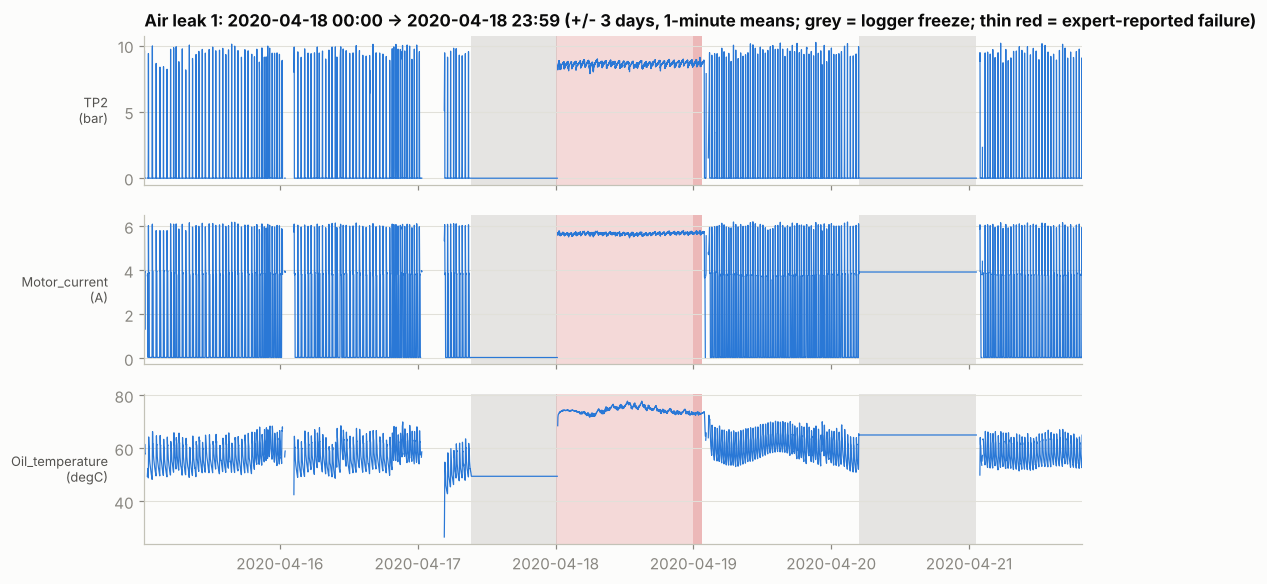

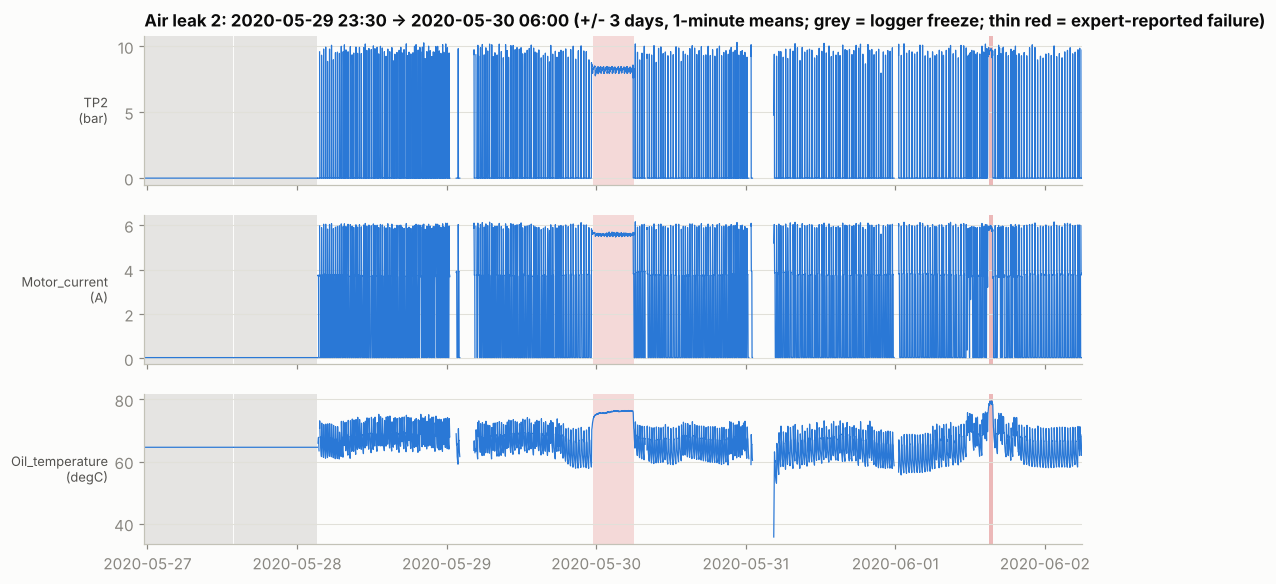

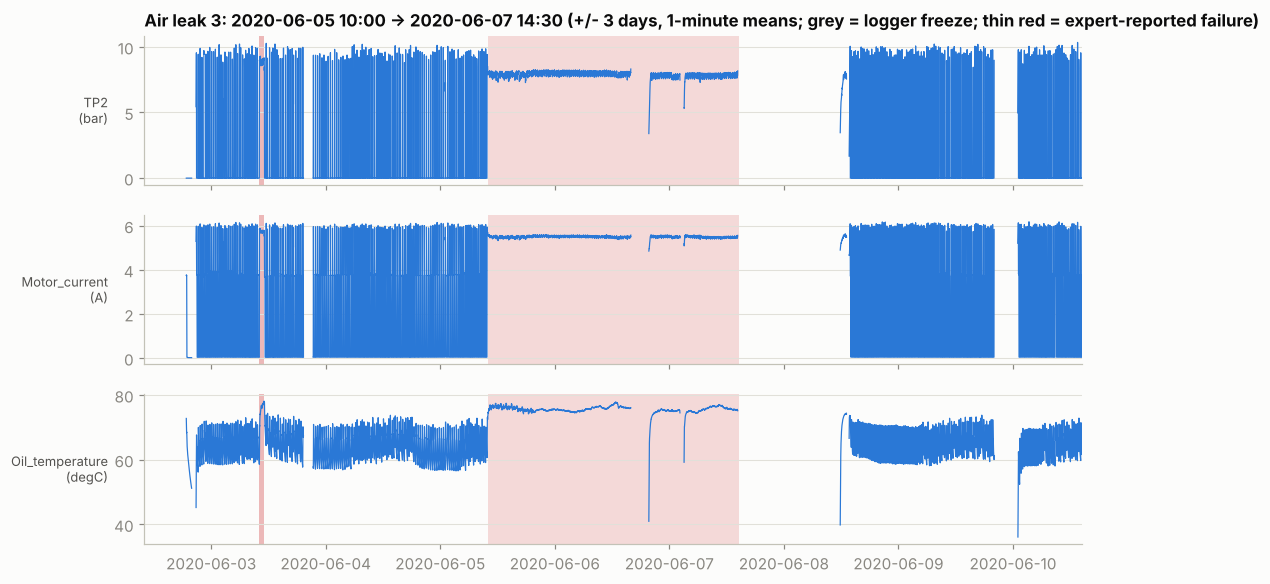

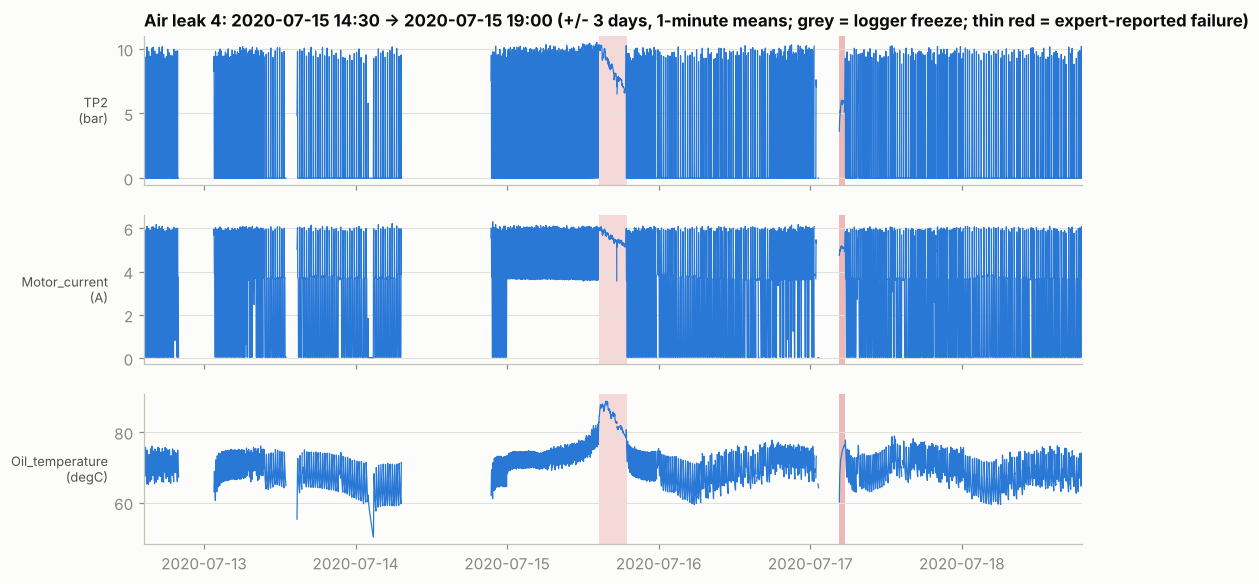

In [26]:
ZOOM_PAD = pd.Timedelta(days=3)
SIG3 = ['TP2', 'Motor_current', 'Oil_temperature']

for s, e, name in FAILURE_WINDOWS:
    seg = ts.loc[s - ZOOM_PAD: e + ZOOM_PAD, SIG3].resample('1min').mean()
    if seg.dropna(how='all').empty:
        print(f'{name}: no data within +/- 3 days of the window')
        continue
    fig, axes = plt.subplots(3, 1, figsize=(11, 6), sharex=True)
    for ax, c in zip(axes, SIG3):
        ax.plot(seg.index, seg[c], color=BLUE, lw=0.8)
        ax.axvspan(s, e, color=CRITICAL, alpha=0.18, lw=0)
        shade_freezes(ax)
        shade_expert(ax)
        ax.set_xlim(seg.index[0], seg.index[-1])
        ax.set_ylabel(f'{c}\n({UNITS[c]})', rotation=0, ha='right',
                      va='center', fontsize=8.5)
        ax.grid(axis='x', visible=False)
    axes[0].set_title(f'{name}: {s:%Y-%m-%d %H:%M} -> {e:%Y-%m-%d %H:%M} '
                      f'(+/- 3 days, 1-minute means; grey = logger freeze; thin red = expert-reported failure)')
    fig.align_ylabels(axes)
    plt.show()

In [27]:
BASELINE = pd.Timedelta(days=7)
rows = {}
for s, e, name in FAILURE_WINDOWS:
    during = tsu.loc[s:e, ANALOG].mean()
    before = tsu.loc[s - BASELINE: s, ANALOG].mean()
    rows[name] = during - before
chg = pd.DataFrame(rows).loc[ANALOG].round(2)
print('Mean level during each failure window minus the preceding 7 days, freezes masked')
print('(absolute change, in each signal unit -- bar, degC, A):')
chg

Mean level during each failure window minus the preceding 7 days, freezes masked
(absolute change, in each signal unit -- bar, degC, A):


,Air leak 1,Air leak 2,Air leak 3,Air leak 4
TP2,6.98,6.70,6.47,6.48
TP3,-0.23,-0.62,-0.96,-0.80
H1,-7.35,-7.45,-7.49,-6.91
DV_pressure,1.73,1.92,1.92,-0.00
Reservoirs,-0.23,-0.62,-0.96,-0.80
Oil_temperature,16.00,8.89,10.49,15.28
Motor_current,3.76,3.05,3.43,2.70


### 5.1 · Continuous load and the expert's log

The failure signature — hours of uninterrupted load — also appears without a repair-forcing report. We flag a
*continuous-load run* when every minute holds a loaded sample (TP2 above 6 bar and Motor_current above 4.5 A,
freezes masked), allowing up to two missing minutes inside a run: a single missing minute at 17:23 used to
split F4 into two pieces and keep it out of the table. v3.3 ran the rule at 4 hours and found six runs with no
report, which became uncertain periods.

The expert's log changes that reading. Davari et al. (2021, Table II) list 21 failures the maintenance expert
reported between April and July, from 20 minutes to 20 hours long; the four UCI labels are the subset that
forced a repair. The first table matches the rule against the log at four minimum lengths. Three of v3.3's six
"unreported" runs are in the log (Apr 12 is failure #1; May 13–14 is #6; May 19–20 is #9–10), and at 30
minutes the rule recovers 18 of the 21 with a single run the log does not have: Jun 8 at 12:01, the hour before
F3's repair, which is the grey period. The two it never reaches are #5, twenty minutes long, and #21, a restart
with the panel near empty. So the rule now runs at 30 minutes, the scale at which it matches the log, and the
runs that remain unreported are all in March, before the log begins: eight of them, three of four hours or more
(the uncertain periods of v3.3) and five of half an hour to an hour and a half. All eight are uncertain periods
in v0.3, tagged by whether TP3 fell against the prior week or held; the tag is descriptive, since the log reports
failures of both kinds. Four of the five shorter ones were the detector's "false alarms" on healthy weeks in the
Oct 1 selection, so the check-week false-alarm rate will fall with this change.

The second table lists every run of 30 minutes or more over the campaign with its status. The reading we had
for Apr 12 — "pressure held, so heavy demand rather than a leak" — does not survive the log: the expert
reported it, and pressure held because the compressor kept up. What separates leaks from demand in this data
is therefore not pressure alone, which is the argument for a multivariate detector followed by the agent's
checks rather than a rule.

In [28]:
loaded_row = (tsu.TP2 > 6) & (tsu.Motor_current > 4.5)
per_min = loaded_row.astype(float).resample('1min').max()     # NaN where the minute has no data


def load_runs(min_minutes, max_hole_min=2):
    """Continuous-load runs of at least min_minutes: every minute holds a loaded sample, with up to
    max_hole_min minutes of missing data tolerated inside a run. Returns (first, last) loaded samples."""
    s = per_min.ffill(limit=max_hole_min) if max_hole_min else per_min
    on = s.fillna(0).astype(bool)
    run_id = (on != on.shift()).cumsum()[on]
    spans = on.index[on].to_series().groupby(run_id).agg(['first', 'last'])
    spans = spans[spans['last'] - spans['first'] >= pd.Timedelta(minutes=min_minutes - 1)]
    hits = loaded_row.index[loaded_row]
    out = []
    for a, b in zip(spans['first'], spans['last']):
        inside = hits[(hits >= a) & (hits < b + one_min)]
        out.append((inside[0], inside[-1]))
    return out


def log_match(a, b):
    """The expert's failure numbers the run [a, b] overlaps, and the repair-forcing label if any."""
    numbers = [n for n, s, e in EXPERT_REPORTED if a <= e + one_min and b >= s]
    label = next((name.replace('Air leak ', 'F') for s, e, name in FAILURE_WINDOWS if a <= e and b >= s), '')
    return numbers, label


in_log = lambda t: EXPERT_PERIOD[0] <= t < EXPERT_PERIOD[1]
rows = []
for label, mm, hole in [('4 h, no holes (v3.3)', 240, 0), ('4 h', 240, 2), ('1 h', 60, 2), ('30 min', 30, 2), ('20 min', 20, 2)]:
    R = [(a, b) for a, b in load_runs(mm, hole) if in_log(a)]
    numbers = [log_match(a, b)[0] for a, b in R]
    covered = {n for ns in numbers for n in ns}
    extra = [(a, b) for (a, b), ns in zip(R, numbers) if not ns]
    rows.append({'minimum run': label, 'runs, Apr-Jul': len(R),
                 'on a logged failure': sum(bool(ns) for ns in numbers),
                 'logged failures covered (of 21)': len(covered),
                 'runs with no logged failure': ', '.join(f'{a:%b %d %H:%M} ({(b - a).total_seconds() / 3600:.1f} h)'
                                                          for a, b in extra) or 'none'})
print('the continuous-load rule against the expert\'s log, April to July:')
display(pd.DataFrame(rows).set_index('minimum run'))
R20 = [(a, b) for a, b in load_runs(20, 2) if in_log(a)]
never = [f'#{n} ({s:%b %d %H:%M}, {(e - s).total_seconds() / 60:.0f} min)' for n, s, e in EXPERT_REPORTED
         if not any(a <= e + one_min and b >= s for a, b in R20)]
print('logged failures that no run of 20 min reaches: ' + (', '.join(never) or 'none'))

the continuous-load rule against the expert's log, April to July:
logged failures that no run of 20 min reaches: #5 (Apr 29 22:00, 20 min), #21 (Jul 17 04:30, 60 min)


,"runs, Apr-Jul",on a logged failure,logged failures covered (of 21),runs with no logged failure
minimum run,,,,
"4 h, no holes (v3.3)",8,8,11,none
4 h,9,9,12,none
1 h,11,10,13,Jun 08 12:01 (1.1 h)
30 min,16,15,18,Jun 08 12:01 (1.1 h)
20 min,18,16,19,"May 10 22:55 (0.3 h), Jun 08 12:01 (1.1 h)"


In [29]:
# Every continuous-load run of 30 minutes or more over the campaign, with its status.
resume_sorted = stops.gap_end.sort_values().to_numpy()


def run_status(a, b):
    numbers, label = log_match(a, b)
    if label:
        return label + (f' (expert #{", #".join(map(str, numbers))})' if numbers else '')
    if numbers:
        return 'expert-reported #' + ', #'.join(map(str, numbers))
    if any(gs <= a <= ge for gs, ge in GREY):
        return 'grey period (before the F3 repair)'
    k = np.searchsorted(resume_sorted, np.datetime64(a), side='right') - 1
    short = (b - a) <= pd.Timedelta(minutes=30)
    if short and k >= 0 and (np.datetime64(a) - resume_sorted[k]) <= np.timedelta64(30, 'm'):
        return 'restart refill'                       # a short run that starts as data resume: the panel refilling
    return 'no report, before the log' if a < EXPERT_PERIOD[0] else 'no report'


rows = []
for a, b in load_runs(30, 2):
    base = tsu.TP3.loc[a - pd.Timedelta(days=7): a].mean()
    rows.append({'start': a, 'end': b, 'hours': round((b - a).total_seconds() / 3600, 1),
                 'status': run_status(a, b),
                 'dTP3 vs prior 7 d (bar)': round(tsu.TP3.loc[a:b].mean() - base, 2),
                 'TP3 min (bar)': round(tsu.TP3.loc[a:b].min(), 2),
                 'oil max (degC)': round(tsu.Oil_temperature.loc[a:b].max(), 1)})
episodes = pd.DataFrame(rows)
unrep = episodes[episodes.status.str.startswith('no report')].reset_index(drop=True)

# The unreported runs are the uncertain periods of events.yaml v0.3; check they still match, spans and tags.
matches = len(unrep) == len(UNCERTAIN) and all(
    abs(a - s) < one_min and abs(b - e) < one_min and (tag == 'probable_leak') == (d < 0)
    for a, b, d, (s, e, tag) in zip(unrep.start, unrep.end, unrep['dTP3 vs prior 7 d (bar)'], UNCERTAIN))
category = episodes.status.map(lambda x: 'F1-F4' if x.startswith('F') else x.split(' #')[0].split(' (')[0])
print(f'{len(episodes)} continuous-load runs of 30 min or more over the campaign: '
      + ', '.join(f'{v} {k}' for k, v in category.value_counts().items()))
print(f'{len(unrep)} with no report in either source, all in March; they match the events.yaml v0.3 '
      f'uncertain periods (spans and tags): {"yes" if matches else "NO"}')
s4, e4, _ = FAILURE_WINDOWS[3]
no_data = tsu.TP2.loc[s4:e4].resample('1min').size()
print('F4: minutes with no data inside the report window: '
      + (', '.join(no_data.index[no_data == 0].strftime('%H:%M')) or 'none') + ' (the hole the finder now tolerates)')
episodes

24 continuous-load runs of 30 min or more over the campaign: 9 expert-reported, 8 no report, before the log, 6 F1-F4, 1 grey period
8 with no report in either source, all in March; they match the events.yaml v0.3 uncertain periods (spans and tags): yes
F4: minutes with no data inside the report window: 17:23 (the hole the finder now tolerates)


,start,end,hours,status,dTP3 vs prior 7 d (bar),TP3 min (bar),oil max (degC)
0,2020-03-06 21:42:35,2020-03-06 22:59:53,1.3,"no report, before the log",0.22,8.18,76.6
1,2020-03-11 05:15:30,2020-03-11 06:10:11,0.9,"no report, before the log",-0.36,8.17,75.6
2,2020-03-11 18:29:41,2020-03-11 18:59:14,0.5,"no report, before the log",-1.81,7.31,71.2
3,2020-03-12 00:16:16,2020-03-12 11:49:50,11.6,"no report, before the log",0.37,7.95,78.0
4,2020-03-26 04:00:40,2020-03-26 04:52:52,0.9,"no report, before the log",0.21,8.05,74.8
5,2020-03-27 07:12:20,2020-03-27 11:38:11,4.4,"no report, before the log",0.22,8.15,77.8
6,2020-03-28 07:22:34,2020-03-28 08:49:39,1.5,"no report, before the log",-0.56,7.90,75.0
7,2020-03-28 23:21:14,2020-03-29 19:49:14,20.5,"no report, before the log",-0.43,5.73,83.1
8,2020-04-12 11:50:31,2020-04-12 23:36:00,11.8,expert-reported #1,0.43,8.04,76.3
9,2020-04-18 00:23:59,2020-04-19 01:55:36,25.5,"F1 (expert #2, #3)",-0.22,8.04,78.2


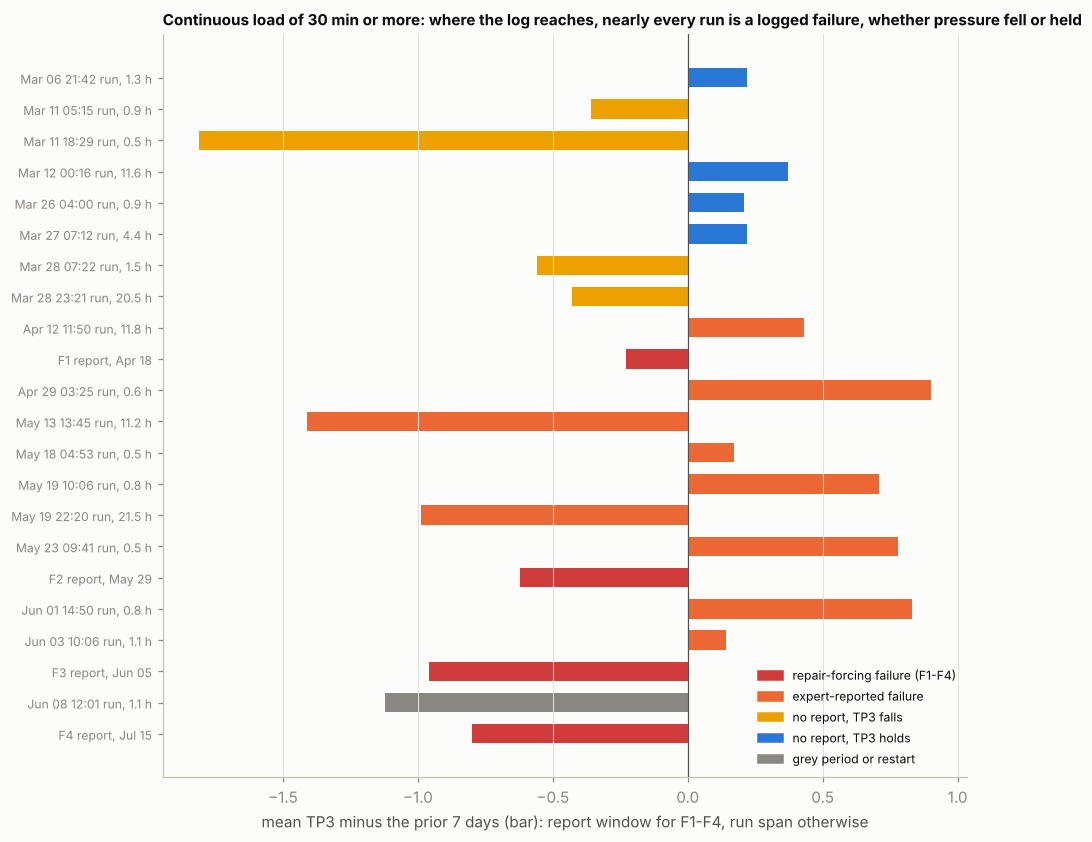

In [30]:
bars = [(s, f'F{i} report, {s:%b %d}', chg.loc['TP3', name], 'repair-forcing failure (F1-F4)')
        for i, (s, e, name) in enumerate(FAILURE_WINDOWS, start=1)]
for _, r in episodes[~episodes.status.str.startswith('F')].iterrows():
    d = r['dTP3 vs prior 7 d (bar)']
    if r.status.startswith('expert'):
        kind = 'expert-reported failure'
    elif r.status.startswith('no report'):
        kind = 'no report, TP3 falls' if d < 0 else 'no report, TP3 holds'
    else:
        kind = 'grey period or restart'
    bars.append((r['start'], f"{r['start']:%b %d %H:%M} run, {r['hours']:.1f} h", d, kind))
bars.sort(key=lambda b: b[0])
KIND = {'repair-forcing failure (F1-F4)': CRITICAL, 'expert-reported failure': ORANGE,
        'no report, TP3 falls': YELLOW, 'no report, TP3 holds': BLUE, 'grey period or restart': MUTED}

fig, ax = plt.subplots(figsize=(9, 0.28 * len(bars) + 1.6))
y = np.arange(len(bars))[::-1]
ax.barh(y, [b[2] for b in bars], color=[KIND[b[3]] for b in bars], height=0.62)
ax.set_yticks(y, [b[1] for b in bars], fontsize=8)
ax.axvline(0, color=INK2, lw=0.8)
ax.set_xlabel('mean TP3 minus the prior 7 days (bar): report window for F1-F4, run span otherwise')
ax.set_title('Continuous load of 30 min or more: where the log reaches, nearly every run is a logged failure, '
             'whether pressure fell or held', fontsize=10)
ax.legend([plt.Rectangle((0, 0), 1, 1, color=c) for c in KIND.values()], KIND.keys(),
          loc='lower right', frameon=False, fontsize=8)
ax.grid(axis='y', visible=False)
fig.tight_layout()
plt.show()

### 5.2 · What precedes the failures

With cycling ruled out, the question is what, if anything, moves before a leak is reported. The answer is
event-specific.

**F4 has a clear lead-up.** From midnight on Jul 15 the compressor never switches off. The hourly share of
time under load climbs from about 0.35 overnight to 0.50 at noon, 0.86 at 14:00 and 1.00 from 15:00 to 17:00,
and oil temperature rises from 75.5 °C in the noon hour to the campaign maximum of 89.05 °C at 15:52. The
rise starts some 14 hours before the report window opens at 14:30, and it may start earlier: recording stops
on Jul 14 from 07:16 to 21:28, and when it resumes the compressor is already switched off only 25–30 % of each
hour, against a median of 57 % before the gap. The change began inside the gap, so the lead-up may be longer
than the data show. A week earlier, on Jul 8 at 17:30–19:00, the expert logged failure #19 (the pressure drop
Section 8.3 picks out), and the detector-selection notebook found that each repair-forcing failure came four
to seven days after a shorter logged one — a clustering worth more than any single precursor here.

**F1, F2 and F3 show nothing comparable.** For F1 that is partly a data problem: a 15-hour freeze runs until
00:18 on the report day, so the hours before it are not in the data. F2 has 41 hours of unfrozen data in the
three days before its report; the load-share rule stays quiet in them, though Section 8.2 finds a moderate shift
on the load features that the season may partly explain. The off-load current rise before F3 in our Sep 19
notes is not in the data: 12-hour medians of off-load current from Jun 1 to the report sit inside the
campaign's 5th–95th percentile band.

**An indicative rule.** The share of samples with the motor loaded over the trailing 6 h, at a threshold of
0.25, fires 13.4 h before F4 and 47 h before F3, never before F1 or F2, and a few times in negative time
(table). The F3 alarm comes from the charge of about an hour on Jun 3 at 10:00 — which v3.3 read as "a
busy hour" and which the log records as failure #15. So the rule's F3 "lead" is a detection of a different,
shorter failure, not a warning of F3; the table now counts alarms inside expert-reported episodes on their own.
At 0.35 the rule keeps F4 (9.0 h) and drops to a few alarms a week. The threshold was picked by looking at the
four events, so the harness has to re-derive it under leave-one-event-out before any of this is quoted as lead
time.

The feature is built on motor current, not DV_eletric, for a concrete reason given in Section 5.3: in parts of
15 clock hours the valves command load while the motor stays off and pressure falls, and a DV_eletric-based
share would count those minutes as load, handing F4 a 36 h "lead" from one such event.

recording gap in the lead-up: Jul 14 07:16 to Jul 14 21:28 (14.2 h)
recording gap in the lead-up: Jul 13 12:59 to Jul 13 14:44 (1.8 h)
median hourly shares from Jul 13 12:00 to the long gap: under load 0.11, switched off 0.57
                     load share  rest share  oil (degC)
timestamp                                              
2020-07-14 21:00:00        0.27        0.25       66.48
2020-07-14 22:00:00        0.16        0.29       68.74
2020-07-14 23:00:00        0.22        0.30       68.88
2020-07-15 00:00:00        0.35        0.00       71.94
2020-07-15 01:00:00        0.34        0.00       72.36
2020-07-15 02:00:00        0.36        0.00       72.36
2020-07-15 03:00:00        0.36        0.00       72.42
2020-07-15 04:00:00        0.35        0.00       72.25
2020-07-15 05:00:00        0.39        0.00       72.13
2020-07-15 06:00:00        0.40        0.00       72.64
2020-07-15 07:00:00        0.39        0.00       72.94
2020-07-15 08:00:00        0.41        0.00   

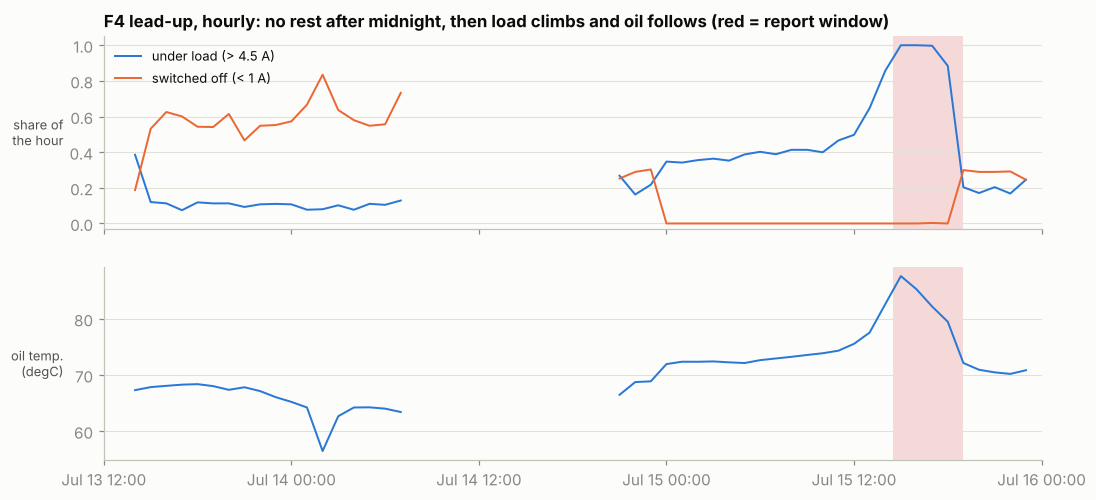

In [31]:
motor_loaded = (tsu.Motor_current > 4.5).astype(float)
motor_off = (tsu.Motor_current < 1).astype(float)
z0, z1 = pd.Timestamp('2020-07-13 12:00'), pd.Timestamp('2020-07-16 00:00')
hourly = pd.DataFrame({'load share': motor_loaded.loc[z0:z1].resample('h').mean(),
                       'rest share': motor_off.loc[z0:z1].resample('h').mean(),
                       'oil (degC)': tsu.Oil_temperature.loc[z0:z1].resample('h').mean()})

fig, axes = plt.subplots(2, 1, figsize=(11, 5), sharex=True)
axes[0].plot(hourly.index, hourly['load share'], color=BLUE, lw=1.3, label='under load (> 4.5 A)')
axes[0].plot(hourly.index, hourly['rest share'], color=ORANGE, lw=1.3, label='switched off (< 1 A)')
axes[0].set_ylim(-0.03, 1.05)
axes[0].set_ylabel('share of\nthe hour', rotation=0, ha='right', va='center', fontsize=8.5)
axes[0].legend(loc='upper left', frameon=False, fontsize=8.5)
axes[1].plot(hourly.index, hourly['oil (degC)'], color=BLUE, lw=1.3)
axes[1].set_ylabel('oil temp.\n(degC)', rotation=0, ha='right', va='center', fontsize=8.5)
for ax in axes:
    shade_failures(ax)
    ax.set_xlim(z0, z1)
    ax.grid(axis='x', visible=False)
axes[0].set_title('F4 lead-up, hourly: no rest after midnight, then load climbs and oil follows '
                  '(red = report window)')
axes[1].xaxis.set_major_locator(mdates.HourLocator(byhour=[0, 12]))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %d %H:%M'))
fig.align_ylabels(axes)
plt.show()

lead_gaps = big[(big.gap_end > z0) & (big.gap_start < FAILURE_WINDOWS[3][0]) & (big.delta_s >= 3600)]
for gs, ge, d in lead_gaps[['gap_start', 'gap_end', 'delta_s']].itertuples(index=False):
    print(f'recording gap in the lead-up: {gs:%b %d %H:%M} to {ge:%b %d %H:%M} ({d / 3600:.1f} h)')
before_gap = hourly.loc[:lead_gaps.gap_start.max()]
print(f"median hourly shares from Jul 13 12:00 to the long gap: under load {before_gap['load share'].median():.2f}, "
      f"switched off {before_gap['rest share'].median():.2f}")
print(hourly.loc['2020-07-14 21:00':'2020-07-15 18:00'].round(2).to_string())
peak = tsu.Oil_temperature.loc['2020-07-15'].idxmax()
print(f'oil maximum on Jul 15: {tsu.Oil_temperature.loc[peak]:.1f} degC at {peak:%H:%M} '
      f'(campaign maximum {tsu.Oil_temperature.max():.1f} degC)')

In [32]:
def share_alarms(signal, thr, window='6h', min_cover=0.5, hold_off=pd.Timedelta(hours=6)):
    """Onsets of `trailing share >= thr`, scored at every sample; a window holding less than
    min_cover of its expected samples is not scored; onsets within hold_off of the last count once."""
    share = signal.rolling(window).mean()
    cover = signal.rolling(window).count() / (pd.Timedelta(window).total_seconds() / step)
    on = (share >= thr) & (cover >= min_cover)
    onsets, last = [], None
    for t in on.index[on & ~on.shift(fill_value=False)]:
        if last is None or t - last >= hold_off:
            onsets.append(t)
            last = t
    return on, onsets


fail_zones = [(s - pd.Timedelta(hours=72), (r if r is not None else e) + BUFFER_AFTER)
              for (s, e, _), r in zip(FAILURE_WINDOWS, REPAIRS)]
unc_zones = [(s, e) for s, e, _ in UNCERTAIN]
exp_zones = [(s - EXPERT_BEFORE, e + one_min + EXPERT_AFTER) for n, s, e in EXPERT_REPORTED
             if not any(fs <= s <= fe for fs, fe, _ in FAILURE_WINDOWS)]


def inside(t, zones):
    return any(a <= t <= b for a, b in zones)


# Negative time: recorded, unfrozen, outside the failure zones, the expert-reported episodes and the uncertain periods.
neg = np.ones(len(tsu), dtype=bool)
for a, b in fail_zones + unc_zones + exp_zones:
    neg &= ~((tsu.index >= a) & (tsu.index <= b))
neg_weeks = neg.sum() * step / (7 * 86400)


def evaluate(signal, thr):
    on, onsets = share_alarms(signal, thr)
    row = {}
    for i, (s, e, _) in enumerate(FAILURE_WINDOWS, start=1):
        before = on.loc[s - pd.Timedelta(hours=72): s]
        row[f'F{i} lead (h)'] = (round((s - before.index[before.to_numpy()][0]).total_seconds()
                                       / 3600, 1) if before.any() else '-')
    false_ = [t for t in onsets if not inside(t, fail_zones + unc_zones + exp_zones)]
    row['alarms, negative time'] = len(false_)
    row['per week'] = round(len(false_) / neg_weeks, 2)
    row['alarms, expert-reported episodes'] = sum(inside(t, exp_zones) and not inside(t, fail_zones) for t in onsets)
    row['alarms, uncertain periods'] = sum(inside(t, unc_zones) and not inside(t, fail_zones) for t in onsets)
    return row


rule = {f'motor loaded, share >= {thr:.2f}': evaluate(motor_loaded, thr)
        for thr in (0.25, 0.30, 0.35)}
rule['DV_eletric = 1, share >= 0.25'] = evaluate(tsu.DV_eletric, 0.25)
print(f'6-hour trailing share, freezes masked; negative time = {neg_weeks:.1f} weeks of recorded data outside '
      'the failure zones (72 h before to 48 h after repair), the expert-reported episodes and the uncertain periods')
pd.DataFrame(rule).T

6-hour trailing share, freezes masked; negative time = 20.6 weeks of recorded data outside the failure zones (72 h before to 48 h after repair), the expert-reported episodes and the uncertain periods


,F1 lead (h),F2 lead (h),F3 lead (h),F4 lead (h),"alarms, negative time",per week,"alarms, expert-reported episodes","alarms, uncertain periods"
"motor loaded, share >= 0.25",-,-,47.0,13.4,3,0.15,8,6
"motor loaded, share >= 0.30",-,-,-,10.6,1,0.05,5,5
"motor loaded, share >= 0.35",-,-,-,9.0,0,0.0,4,5
"DV_eletric = 1, share >= 0.25",-,-,59.3,35.6,5,0.24,8,6


In [33]:
# How much unfrozen data is there in the 72 h before each report?
avail = [((tsu.index >= s - pd.Timedelta(hours=72)) & (tsu.index < s)).sum() * step / 3600
         for s, e, _ in FAILURE_WINDOWS]
print('hours of unfrozen data in the 72 h before each report: '
      + ', '.join(f'F{i} {h:.1f}' for i, h in enumerate(avail, start=1)))

# F3: is off-load current (motor running, not loaded) elevated before the report?
offload = tsu.Motor_current[(tsu.Motor_current > 1) & (tsu.Motor_current <= 4.5)]
lo, hi = offload.quantile([0.05, 0.95])
before_f3 = offload.loc['2020-06-01':'2020-06-05 09:59:59'].resample('12h').median().dropna()
print(f'off-load current, campaign 5th-95th percentile: {lo:.2f}-{hi:.2f} A')
print('12-hour medians, Jun 1 to the F3 report: ' + ', '.join(f'{v:.2f}' for v in before_f3))
s3 = FAILURE_WINDOWS[2][0]
charges = [(a, b) for a, b in load_runs(30, 2) if s3 - pd.Timedelta(hours=72) <= a and b < s3]
print('continuous load of 30 min or more in the 72 h before F3: '
      + ('; '.join(f'{a:%b %d %H:%M}-{b:%H:%M} ({(b - a).total_seconds() / 3600:.1f} h, {run_status(a, b)})'
                   for a, b in charges) or 'none'))

hours of unfrozen data in the 72 h before each report: F1 51.1, F2 41.0, F3 60.7, F4 50.7
off-load current, campaign 5th-95th percentile: 3.65-3.93 A
12-hour medians, Jun 1 to the F3 report: 3.78, 3.73, 3.76, 3.79, 3.81, 3.75, 3.76, 3.75, 3.78
continuous load of 30 min or more in the 72 h before F3: Jun 03 10:06-11:10 (1.1 h, expert-reported #15)


### 5.3 · Load commanded with the motor off

In parts of 15 clock hours of the campaign the valves command load (DV_eletric = 1, COMP = 0) while the motor
stays off and pressure falls. On Jul 14 from 02:00 to 02:50, TP3 fell from 8.2 to 4.9 bar before the motor
started. A share built on DV_eletric counts those minutes as load; one built on motor current does not, which
is why the engineered channels use motor current.

These spells are not in either label source, and they are not asset faults in the leak sense: the compressor
is being asked to load and is not running. The detector-selection run showed they are the detector's most
frequent "false" alarms and that an LLM reading the evidence refused to dismiss them (a compressor that will
not start is worth a look). So they become *data-quality events* in `events.yaml` v0.3: they stay negative for
training, the diagnostic check C1 reads them, and the false-alarm rate is reported with and without alarms that
open on them. The cell prints them in the form the file takes.

In [34]:
cmd = ((tsu.DV_eletric == 1) & (tsu.Motor_current < 1))
cmd_t = tsu.index[cmd.to_numpy()]
new_event = np.r_[True, np.diff(cmd_t.to_numpy()) > np.timedelta64(1, 'h')]       # a new spell after an hour's quiet
spells = pd.DataFrame({'t': cmd_t, 'id': np.cumsum(new_event)}).groupby('id').t.agg(['first', 'last', 'size'])
spells = spells[spells['size'] >= 30].reset_index(drop=True)                        # 5 minutes of samples or more
spells['minutes'] = (spells['size'] * step / 60).round(0).astype(int)
spells['TP3 min (bar)'] = [tsu.TP3.loc[a:b].min() for a, b in zip(spells['first'], spells['last'])]
spells['TP3 at start (bar)'] = [tsu.TP3.loc[a] for a in spells['first']]
next_fail = []
for a in spells['first']:
    ahead = [(s - a) for s, e, _ in FAILURE_WINDOWS if s > a] + [(s - a) for n, s, e in EXPERT_REPORTED if s > a]
    next_fail.append(min(ahead).total_seconds() / 86400 if ahead else np.nan)
spells['days to the next reported failure'] = np.round(next_fail, 1)
print(f'DV_eletric = 1 with Motor_current < 1 A: {cmd.mean():.2%} of samples (COMP = 0 in '
      f'{(tsu.COMP[cmd] == 0).mean():.0%} of them); {len(spells)} spells of 5 minutes or more, '
      f'{int(spells.minutes.sum())} minutes in all')
display(spells.drop(columns='size').round({'TP3 min (bar)': 2, 'TP3 at start (bar)': 2}))
print('events.yaml v0.3, data_quality_events.motor_off_command:')
for a, b, m, p in zip(spells['first'], spells['last'], spells['minutes'], spells['TP3 min (bar)']):
    print(f'    - {{start: {a:%Y-%m-%d %H:%M:%S}, end: {b:%Y-%m-%d %H:%M:%S}, minutes: {m}, tp3_min_bar: {p:.2f}}}')

DV_eletric = 1 with Motor_current < 1 A: 0.14% of samples (COMP = 0 in 100% of them); 11 spells of 5 minutes or more, 322 minutes in all
events.yaml v0.3, data_quality_events.motor_off_command:
    - {start: 2020-04-06 11:27:52, end: 2020-04-06 11:52:09, minutes: 25, tp3_min_bar: 7.73}
    - {start: 2020-04-25 00:34:20, end: 2020-04-25 01:10:51, minutes: 37, tp3_min_bar: 6.49}
    - {start: 2020-05-19 01:50:10, end: 2020-05-19 02:40:33, minutes: 51, tp3_min_bar: 4.69}
    - {start: 2020-06-02 19:05:00, end: 2020-06-02 19:54:35, minutes: 50, tp3_min_bar: 5.57}
    - {start: 2020-07-14 01:14:09, end: 2020-07-14 02:50:17, minutes: 53, tp3_min_bar: 4.95}
    - {start: 2020-07-17 01:14:28, end: 2020-07-17 01:19:17, minutes: 5, tp3_min_bar: 1.45}
    - {start: 2020-07-18 00:52:51, end: 2020-07-18 01:37:27, minutes: 6, tp3_min_bar: 7.55}
    - {start: 2020-07-28 03:35:54, end: 2020-07-28 04:03:09, minutes: 6, tp3_min_bar: 7.61}
    - {start: 2020-07-31 01:19:11, end: 2020-07-31 02:09:04, minu

,first,last,minutes,TP3 min (bar),TP3 at start (bar),days to the next reported failure
0,2020-04-06 11:27:52,2020-04-06 11:52:09,25,7.73,8.82,6.0
1,2020-04-25 00:34:20,2020-04-25 01:10:51,37,6.49,8.12,4.1
2,2020-05-19 01:50:10,2020-05-19 02:40:33,51,4.69,8.08,0.3
3,2020-06-02 19:05:00,2020-06-02 19:54:35,50,5.57,8.09,0.6
4,2020-07-14 01:14:09,2020-07-14 02:50:17,53,4.95,8.08,1.6
5,2020-07-17 01:14:28,2020-07-17 01:19:17,5,1.45,1.89,0.1
6,2020-07-18 00:52:51,2020-07-18 01:37:27,6,7.55,8.08,NaN
7,2020-07-28 03:35:54,2020-07-28 04:03:09,6,7.61,8.10,NaN
8,2020-07-31 01:19:11,2020-07-31 02:09:04,50,5.24,8.11,NaN
9,2020-08-03 09:53:27,2020-08-03 10:25:10,32,6.02,8.10,NaN


## 6 · Healthy windows for detector training

The detector interface fits on healthy data only. Our first run picked healthy *days* (at least 90 % coverage,
two days clear of a failure) and found 80. That was too loose, because it let logger freezes, unreported load
episodes and pre-failure days through, and too strict, because a day with one overnight stop is mostly usable.

Here healthy data is counted at window level, as an independent cross-check of the pipeline in Section 7,
which does the same job on the resampled grid. A 10-minute window on a fixed grid is *clean* when it holds at
least 57 of its 60 raw samples and no step into or within it exceeds 30 s. It is *healthy* when it is clean
and touches none of the `events.yaml` v0.3 exclusions:

- from 7 days before each repair-forcing failure to 48 h after its repair (after the window end for F1, which
  has no repair time);
- each expert-reported failure with its band, an hour before to six hours after;
- the ten logger-freeze masks;
- the three uncertain periods (the March load episodes);
- the grey period, Jun 8 11:48–16:00.

The second table re-checks the day-level candidates in `events.yaml` against the same rule: with the "heavy
LPS" periods gone, H1 keeps all seven days and H5 is back. The pipeline's own rule (Section 7.3: all 60 grid
points observed or bridged, plus gap edges and a look-back rule) is the definition the port must reproduce;
this section's count is a sanity check on it, and Section 7.3 explains the few windows on which the two differ.

In [35]:
EPS = pd.Timedelta(seconds=1)       # event spans include their end instant
EXCLUSIONS = [(s - BUFFER_BEFORE, (r if r is not None else e) + BUFFER_AFTER, 'failure buffer')
              for (s, e, _), r in zip(FAILURE_WINDOWS, REPAIRS)]
EXCLUSIONS += [(s - EXPERT_BEFORE, e + one_min + EXPERT_AFTER, 'expert-reported') for n, s, e in EXPERT_REPORTED]
EXCLUSIONS += [(s, e + EPS, 'logger freeze') for s, e in FREEZE_MASKS]
EXCLUSIONS += [(s, e + EPS, tag) for s, e, tag in UNCERTAIN]
EXCLUSIONS += [(s, e + EPS, 'grey') for s, e in GREY]

win = df.timestamp.dt.floor('10min')
w = pd.DataFrame({'rows': win.groupby(win).size(),
                  'max_step_s': steps.groupby(win).max()})
w['clean'] = (w.rows >= 57) & (w.max_step_s <= 30)
starts = w.index
ends = starts + pd.Timedelta(minutes=10)
w['excluded by'] = ''
for s, e, why in EXCLUSIONS:                       # first matching exclusion names the reason
    hit = (starts < e) & (ends > s) & (w['excluded by'] == '').to_numpy()
    w.loc[hit, 'excluded by'] = why
w['healthy'] = w.clean & (w['excluded by'] == '')

edges = [pd.Timestamp('2020-02-01'), *REGIME_SPLITS, pd.Timestamp('2020-09-02')]
w['regime'] = pd.cut(starts, edges, right=False,
                     labels=['Feb (light duty)', 'Mar 1 to Jun 8 16:00', 'after Jun 8 16:00'])
by_regime = w.groupby('regime', observed=False).agg(clean=('clean', 'sum'),
                                                    healthy=('healthy', 'sum'))
by_regime.index = by_regime.index.astype(str)
by_regime.loc['total'] = by_regime.sum()
by_regime['healthy days'] = (by_regime.healthy * 10 / 1440).round(1)

lost = w.loc[w.clean & ~w.healthy, 'excluded by'].value_counts()
print(f'{int(w.clean.sum()):,} clean 10-minute windows; {int(w.healthy.sum()):,} healthy '
      f'after the v0.3 exclusions (~{w.healthy.sum() * 10 / 1440:.0f} days)')
print('clean windows lost, by first matching exclusion: '
      + ', '.join(f'{k} {v:,}' for k, v in lost.items()))

grid_h = w.healthy.reindex(pd.date_range(starts.min(), starts.max(), freq='10min'), fill_value=False)
run_no = (~grid_h).cumsum()[grid_h]
run_len = run_no.value_counts()
longest = run_no.index[run_no == run_len.idxmax()]
print(f'longest unbroken healthy stretch: {run_len.max() * 10 / 60:.1f} h, '
      f'{longest[0]:%b %d %H:%M} to {longest[-1] + pd.Timedelta(minutes=10):%b %d %H:%M}')
by_regime

23,943 clean 10-minute windows; 19,365 healthy after the v0.3 exclusions (~134 days)
clean windows lost, by first matching exclusion: failure buffer 3,932, expert-reported 395, probable_leak 138, load_held 111, logger freeze 2
longest unbroken healthy stretch: 71.5 h, Jun 30 01:10 to Jul 03 00:40


,clean,healthy,healthy days
regime,,,
Feb (light duty),3518,3518,24.4
Mar 1 to Jun 8 16:00,10954,7678,53.3
after Jun 8 16:00,9471,8169,56.7
total,23943,19365,134.5


In [36]:
CANDIDATES = [('H1', '2020-06-29', '2020-07-05'), ('H2', '2020-07-18', '2020-07-22'),
              ('H3', '2020-06-13', '2020-06-16'), ('H4', '2020-03-21', '2020-03-23'),
              ('H5', '2020-05-06', '2020-05-08'), ('H6', '2020-03-25', '2020-03-27'),
              ('H7', '2020-08-06', '2020-08-08')]
cand = []
for cid, a, b in CANDIDATES:
    sub = w.loc[a: pd.Timestamp(b) + pd.Timedelta(hours=23, minutes=50)]
    lost_to = sorted(set(sub.loc[sub.clean & ~sub.healthy, 'excluded by']))
    cand.append({'candidate': cid,
                 'days': f'{pd.Timestamp(a):%b %d} to {pd.Timestamp(b):%b %d}',
                 'clean windows': int(sub.clean.sum()),
                 'healthy windows': int(sub.healthy.sum()),
                 'lost to': ', '.join(lost_to) or '-'})
print('Day-level healthy candidates from events.yaml, re-checked at window level:')
pd.DataFrame(cand).set_index('candidate')

Day-level healthy candidates from events.yaml, re-checked at window level:


,days,clean windows,healthy windows,lost to
candidate,,,,
H1,Jun 29 to Jul 05,990,990,-
H2,Jul 18 to Jul 22,625,624,logger freeze
H3,Jun 13 to Jun 16,560,560,-
H4,Mar 21 to Mar 23,423,423,-
H5,May 06 to May 08,394,394,-
H6,Mar 25 to Mar 27,432,399,load_held
H7,Aug 06 to Aug 08,415,415,-


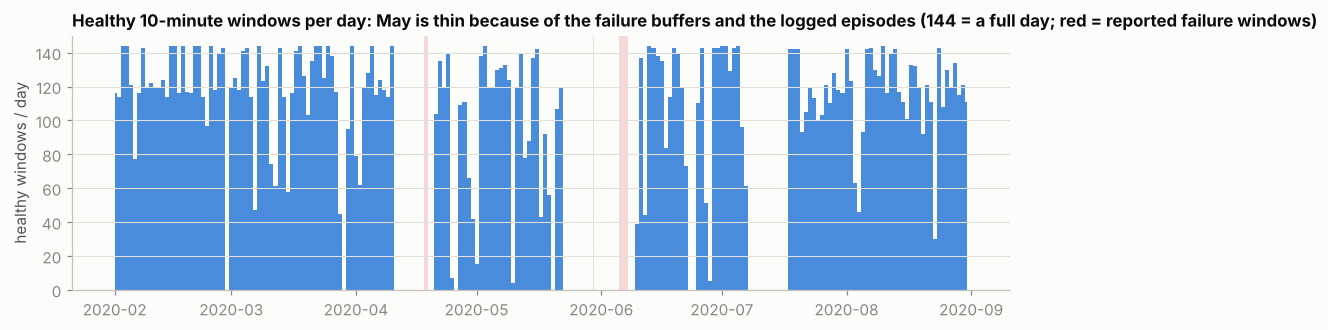

In [37]:
per_day = w.healthy.groupby(starts.floor('D')).sum()
per_day = per_day.reindex(pd.date_range('2020-02-01', '2020-08-31'), fill_value=0)
fig, ax = plt.subplots(figsize=(11, 3))
ax.fill_between(per_day.index, per_day, step='mid', color=BLUE, alpha=0.85, lw=0)
shade_failures(ax)
ax.set_ylim(0, 150)
ax.set_ylabel('healthy windows / day')
ax.set_title('Healthy 10-minute windows per day: May is thin because of the failure buffers and the logged episodes '
             '(144 = a full day; red = reported failure windows)')
ax.grid(axis='x', visible=False)
plt.show()

## 7 · Data preprocessing

This section turns the raw file into the form every model reads: a regular 10 s grid, one zone label per grid
point, and 10-minute windows with a 1-minute stride. It follows `asset_profile.yaml` v0.2, `events.yaml` v0.3
and the gap policy. The functions (`freeze_runs` from Section 2.2, then `to_grid`, `gap_edges`, `zone_codes`,
`window_ends`, `make_windows`, `add_folds` and `window_features`), fed by the raw gap table of Section 2.1,
are pure functions of their inputs and are written to move into `pdm_common` (build plan T5–T7, T12a); the
move swaps the notebook constants they read for the profile and events files. The outputs are saved at the end
of Section 8.

Why these steps, in one paragraph. The logger's steps are 9–10 s with jitter, so features computed on raw rows
would depend on where the jitter fell; a fixed grid removes that. Freezes are dropped *before* resampling so
that a resampler cannot carry a frozen value forward. Short holes are bridged because a 10-minute window should
not be lost to one missed sample, but anything longer stays missing, because a filled hour is invented data.
Zones give every instant exactly one label, with a precedence order, so that "healthy" means one thing in
every notebook and service. Windows are dropped rather than repaired because a repaired window is a window the
detector did not see. And the folds and splits are written into the table so that no consumer re-derives them.

### 7.1 · A regular 10 s grid

Frozen rows are dropped first, so a freeze becomes missing data instead of a flat line the resampler could
carry forward. The remaining rows go onto a fixed 10 s UTC grid. Analog channels take the mean of the samples
in each bin (a few thousand bins hold two samples, because of the 9 s steps), and digital channels take the last
value. An interior run of one or two empty points is bridged (linear interpolation for analog, forward fill for
digital) and flagged. That covers every raw gap of 30 s or less and, depending on where a gap falls against the
bins, some shorter than 40 s. Anything longer stays missing. The file has almost no short gaps: under a hundred
points are bridged, against about a thousand hours missing to gaps and freezes.

In [38]:
STEP = '10s'           # asset_profile.yaml: sampling.resample_rule
MAX_BRIDGE_S = 30      # gap_policy.max_bridge_seconds


def to_grid(df, frozen, analog=ANALOG, digital=DIGITAL, step=STEP, max_bridge_s=MAX_BRIDGE_S):
    """Resample the raw rows onto a regular UTC grid with epoch-aligned bins.

    Frozen rows are dropped first, so a freeze becomes missing data. Analog channels take the mean of
    each bin, digital channels the last value. An interior run of empty bins is bridged when
    (run + 1) x step <= max_bridge_s: analog interpolated in time, digital carried forward, and flagged
    in `bridged`. Runs at either end of the data are never bridged. `observed` marks bins that held a
    sample for every analog channel."""
    live = df.loc[~frozen, ['timestamp'] + analog + digital].set_index('timestamp')
    idx = pd.date_range(df.timestamp.min().floor(step), df.timestamp.max().floor(step),
                        freq=step, name='timestamp')
    a = live[analog].resample(step, origin='epoch').mean().reindex(idx)
    d = live[digital].resample(step, origin='epoch').last().reindex(idx)
    observed = a.notna().all(axis=1).to_numpy()
    missing = ~observed
    run_id = np.cumsum(np.r_[True, missing[1:] != missing[:-1]])
    run_len = np.bincount(run_id)[run_id]
    at_edge = (run_id == run_id[0]) | (run_id == run_id[-1])
    step_s = pd.Timedelta(step).total_seconds()
    bridged = missing & ~at_edge & ((run_len + 1) * step_s <= max_bridge_s)
    values_a = np.where(bridged[:, None], a.interpolate(method='time', limit_area='inside').to_numpy(),
                        a.to_numpy())
    values_d = np.where(bridged[:, None], d.ffill().to_numpy(), d.to_numpy())
    cols = {c: values_a[:, j] for j, c in enumerate(analog)}
    cols.update({c: values_d[:, j] for j, c in enumerate(digital)})
    grid = pd.DataFrame(cols, index=idx)
    grid['observed'] = observed
    grid['bridged'] = bridged
    return grid


grid = to_grid(df, frozen)
grid_valid = (grid.observed | grid.bridged).to_numpy()
two_samples = int((df.timestamp[~frozen].dt.floor(STEP).value_counts() > 1).sum())
counts = pd.Series({'observed': int(grid.observed.sum()),
                    'bridged (a run of one or two empty points)': int(grid.bridged.sum()),
                    'missing (gaps and freezes)': int((~grid_valid).sum())})
print(f'{len(grid):,} grid points of 10 s, {grid.index[0]} to {grid.index[-1]}')
print(f'bins holding two samples (from 9 s steps), averaged: {two_samples:,}')
pd.DataFrame({'grid points': counts, 'hours': (counts / 360).round(2)})

1,841,760 grid points of 10 s, 2020-02-01 00:00:00 to 2020-09-01 03:59:50
bins holding two samples (from 9 s steps), averaged: 12,840


,grid points,hours
observed,1453431,4037.31
bridged (a run of one or two empty points),86,0.24
missing (gaps and freezes),388243,1078.45


### 7.2 · Zones

Every grid point gets exactly one zone, in order of precedence:

1. **masked** — a logger freeze;
2. **positive** — a repair-forcing report window (F1–F4) with its guard band, 24 h before and 12 h after;
3. **expert_reported** — one of the expert's failures that forced no repair, an hour before to six hours after
   (the six hours are the persistence gate's hold-off, so the detector's trailing alarm is not a false alarm);
4. **grey** — the three uncertain periods, the Jun 8 grey period, the first 15 minutes after each recording
   gap of 30 minutes or more (the gap edges of `events.yaml`), and the rest of each healthy buffer;
5. **negative** — everything else.

Negative time is the only detector training data. Grey and expert-reported time is scored; alarms in grey time
are audited rather than counted as false, and alarms in expert-reported time count as detections for the
harness that scores against the log. An alarm in positive time counts as a detection of F1–F4. Lead time is
measured back from the report start at the 2, 24 and 72 h horizons of `events.yaml`, so at 72 h the harness
also reads alarms in the buffer before the guard band; how it scores those is its call. The `zone_detail`
column keeps the finer label, so the false-alarm rate can be reported with and without the uncertain periods.

The data set the gap edge. When recording resumes after a stop, TP3 is below its healthy 1st percentile in
most cases at the first point and in few by fifteen minutes later; before a stop the share stays flat, with no
transient, so the shutdown side needs no edge. Section 2.3 measured the whole transient (time to 8 bar per
restart); whether the edge stays at 15 minutes or becomes state-based is the open decision recorded there.
Gaps are raw timestamp gaps; a freeze keeps its timestamps and gets no edge.

In [39]:
GAP_EDGE = pd.Timedelta(minutes=15)     # events.yaml "gap edges": grey after a stop (see below)
ZONE_DETAIL = ['negative', 'buffer', 'gap_edge', 'grey_period', 'uncertain:load_held',
               'uncertain:probable_leak', 'expert_reported', 'failure', 'masked']
ZONE_OF = np.array(['negative', 'grey', 'grey', 'grey', 'grey', 'grey', 'grey', 'positive', 'masked'])
CODE = {name: i for i, name in enumerate(ZONE_DETAIL)}


def gap_edges(gaps, min_gap=STOP_MIN, length=GAP_EDGE, step=STEP):
    """Grey spans after each recording gap of min_gap or more. `gaps` holds raw-timestamp gaps
    (gap_start, gap_end, delta_s), so a freeze, which keeps its timestamps, is not a gap."""
    stops = gaps[gaps.delta_s >= pd.Timedelta(min_gap).total_seconds()]
    return [(t.floor(step), t + length) for t in stops.gap_end.sort_values()]


GAP_EDGES = gap_edges(big)


def zone_codes(times, gap_edges=GAP_EDGES):
    """One code per timestamp (an index into ZONE_DETAIL); the higher code wins where spans overlap.
    `times` must be sorted."""
    code = np.zeros(len(times), dtype=np.int8)

    def paint(start, end, c, closed=True):
        i0, i1 = times.searchsorted(start), times.searchsorted(end, side='right' if closed else 'left')
        code[i0:i1] = np.maximum(code[i0:i1], c)

    for (s, e, _), r in zip(FAILURE_WINDOWS, REPAIRS):
        paint(s - BUFFER_BEFORE, (r if r is not None else e) + BUFFER_AFTER, CODE['buffer'], closed=False)
        paint(s - GUARD_BEFORE, e + GUARD_AFTER, CODE['failure'])
    for s, e in gap_edges:
        paint(s, e, CODE['gap_edge'], closed=False)
    for s, e in GREY:
        paint(s, e, CODE['grey_period'])
    for s, e, tag in UNCERTAIN:
        paint(s, e, CODE['uncertain:' + tag])
    for n, s, e in EXPERT_REPORTED:             # inside F1-F4 the failure code wins, as it should
        paint(s - EXPERT_BEFORE, e + one_min + EXPERT_AFTER, CODE['expert_reported'])
    for s, e in FREEZE_MASKS:
        paint(s, e, CODE['masked'])
    return code


grid['zone_code'] = zone_codes(grid.index)
grid['zone'] = pd.Categorical(ZONE_OF[grid.zone_code], categories=['negative', 'grey', 'positive', 'masked'])
grid['zone_detail'] = pd.Categorical(np.array(ZONE_DETAIL)[grid.zone_code], categories=ZONE_DETAIL)

# Why 15 minutes: TP3 right after each stop, against the healthy 1st percentile.
tp3 = grid.TP3.to_numpy()
p1 = np.nanpercentile(tp3[(grid.zone_code.to_numpy() == 0) & grid_valid], 1)
first = grid.index.searchsorted(stops.gap_end, side='right') - 1  # first point after the gap
last = grid.index.searchsorted(stops.gap_start, side='right') - 1  # last point before it
low = {}
for m in [0, 5, 10, 15, 30]:
    after, before = tp3[np.minimum(first + 6 * m, len(tp3) - 1)], tp3[np.maximum(last - 6 * m, 0)]
    low[f'{m} min'] = {'after the stop': (after[~np.isnan(after)] < p1).mean(),
                       'before the stop': (before[~np.isnan(before)] < p1).mean()}
print(f'{len(stops)} recording gaps of 30 min or more. Share with TP3 below the healthy 1st '
      f'percentile ({p1:.2f} bar), by minutes from the gap:')
print(pd.DataFrame(low).round(2).to_string())

zone_hours = pd.DataFrame({
    'zone': pd.Series(ZONE_OF, index=ZONE_DETAIL),
    'hours': grid.groupby('zone_detail', observed=False).size() / 360,
    'hours with data': grid[grid_valid].groupby('zone_detail', observed=False).size() / 360,
}).round(1)
zone_hours

190 recording gaps of 30 min or more. Share with TP3 below the healthy 1st percentile (8.08 bar), by minutes from the gap:
                 0 min  5 min  10 min  15 min  30 min
after the stop    0.58   0.21    0.07    0.04    0.04
before the stop   0.09   0.07    0.09    0.10    0.11


,zone,hours,hours with data
negative,negative,3953.9,3231.4
buffer,grey,551.0,416.6
gap_edge,grey,44.5,40.5
grey_period,grey,4.2,3.7
uncertain:load_held,grey,18.2,18.2
uncertain:probable_leak,grey,23.3,23.3
expert_reported,grey,134.6,119.6
failure,positive,216.5,184.3
masked,masked,169.8,0.0


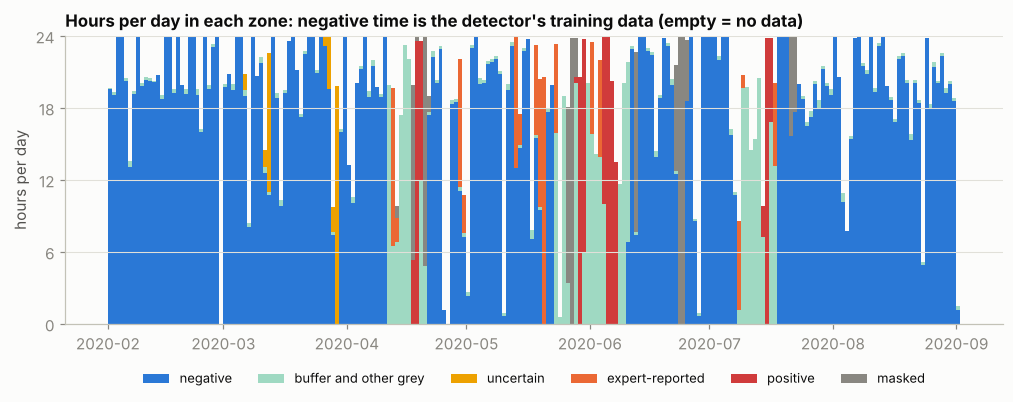

In [40]:
# Hours per day in each zone; freezes get their own colour and missing data is left empty.
kind = np.select([grid.zone_code == CODE['masked'], ~grid_valid, grid.zone_code == CODE['failure'],
                  grid.zone_code == CODE['expert_reported'],
                  grid.zone_code.isin([CODE['uncertain:load_held'], CODE['uncertain:probable_leak']]),
                  grid.zone_code >= CODE['buffer']],
                 ['masked', 'no data', 'positive', 'expert-reported', 'uncertain', 'buffer and other grey'],
                 default='negative')
per_day = pd.crosstab(grid.index.floor('D'), kind) / 360
ZONE_STYLE = [('negative', BLUE), ('buffer and other grey', '#9fd9c2'), ('uncertain', YELLOW),
              ('expert-reported', ORANGE), ('positive', CRITICAL), ('masked', MUTED)]
fig, ax = plt.subplots(figsize=(11, 3.4))
bottom = np.zeros(len(per_day))
for name, colour in ZONE_STYLE:
    hours = per_day[name].to_numpy() if name in per_day else np.zeros(len(per_day))
    ax.bar(per_day.index, hours, bottom=bottom, width=1.0, align='edge', color=colour, lw=0, label=name)
    bottom += hours
ax.set_ylim(0, 24)
ax.set_yticks([0, 6, 12, 18, 24])
ax.set_ylabel('hours per day')
ax.set_title('Hours per day in each zone: negative time is the detector\'s training data (empty = no data)')
ax.legend(ncol=6, loc='upper center', bbox_to_anchor=(0.5, -0.12), frameon=False, fontsize=8.5)
ax.grid(axis='x', visible=False)
plt.show()

### 7.3 · Windows

Windows are 10 minutes (60 grid points) with a 1-minute stride, each starting on the full minute, and a window
takes the highest-precedence zone any of its points has. A window is complete when all 60 points are observed
or bridged. Incomplete windows are dropped, never repaired. One more rule applies at window level: a negative
window whose 6 h look-back reaches an uncertain period, an expert-reported episode or a report becomes grey
(`after_uncertain`): after a load episode its 6 h shares still carry the episode.

Two columns are new in v4 and exist so that no consumer re-derives them: `aligned` marks the windows that
start on a ten-minute boundary, which do not overlap each other, and `group_id` is the window's hour, for
validation splits that keep neighbouring windows together (overlapping windows are near-copies of each other,
so a random split of windows is not a split).

The cross-check against Section 6 counts non-overlapping negative windows both ways, under Section 6's
exclusions (no gap edges, no look-back rule). The handful that differ come from how each side reads missing
data: Section 6 looks at raw rows per ten-minute block and does not look past a block's end, while the grid
sees every missing point. The grid's rule is the definition; the pipeline test expects its counts.

In [41]:
WIN_BINS = 60                      # windowing.length: 10 min of 10 s points
WIN_LEN = pd.Timedelta(minutes=10)
LOOKBACK = pd.Timedelta(hours=6)   # longest short look-back among the features (load and rest share)


def window_ends(grid, win_bins=WIN_BINS):
    """Grid positions of the last point of every window that starts on a full minute
    (windowing.stride: 1 min)."""
    last = np.arange(win_bins - 1, len(grid))
    return last[grid.index[last - (win_bins - 1)].second == 0]


def make_windows(grid, ends, win_bins=WIN_BINS, lookback=LOOKBACK, step=STEP):
    """One row per window: complete when all points are observed or bridged; the zone is the
    highest-precedence zone of its own points. A negative window whose look-back (`lookback` before
    its start) reaches an uncertain period, an expert-reported episode or a report becomes grey,
    'after_uncertain'. Adds the regime, the `aligned` flag and the `group_id`."""
    valid = (grid.observed | grid.bridged).astype('int16')
    n_valid = valid.rolling(win_bins).sum().to_numpy()[ends]
    top = grid.zone_code.rolling(win_bins).max().to_numpy()[ends].astype(int)
    episode = grid.zone_code.between(CODE['uncertain:load_held'], CODE['failure']).astype('int8')
    reach = win_bins + int(lookback / pd.Timedelta(step))
    touched = episode.rolling(reach, min_periods=1).max().to_numpy()[ends] > 0
    zone = ZONE_OF[top].astype(object)
    detail = np.array(ZONE_DETAIL, dtype=object)[top]
    after = (zone == 'negative') & touched
    zone[after], detail[after] = 'grey', 'after_uncertain'
    start = grid.index[ends - (win_bins - 1)]
    out = pd.DataFrame({'window_start': start, 'window_end': start + WIN_LEN,
                        'complete': n_valid == win_bins, 'zone': zone, 'zone_detail': detail})
    out['regime'] = pd.cut(out.window_start, [pd.Timestamp('2020-02-01'), *REGIME_SPLITS,
                                              pd.Timestamp('2020-09-02')],
                           right=False, labels=['light_duty', 'normal', 'dv_pressure_flat'])
    out['aligned'] = (out.window_start.dt.minute % 10 == 0)          # non-overlapping subset
    out['group_id'] = out.window_start.dt.strftime('%Y-%m-%dT%H')    # the hour, for grouped splits
    return out


win_end_pos = window_ends(grid)
windows_all = make_windows(grid, win_end_pos)
done = windows_all[windows_all.complete]
print(f'{len(windows_all):,} candidate windows; {len(done):,} complete '
      f'({len(windows_all) - len(done):,} dropped for missing data or freezes)')

# Cross-check with Section 6, which applies the same exclusions without the gap edges and the
# look-back rule: count non-overlapping negative windows both ways and explain the ones that differ.
on_ten = windows_all.aligned.to_numpy()
base_top = pd.Series(zone_codes(grid.index, gap_edges=[])).rolling(WIN_BINS).max().to_numpy()[win_end_pos]
base = windows_all[windows_all.complete.to_numpy() & on_ten & (base_top == 0)]
swap = sorted(set(base.window_start) ^ set(w.index[w.healthy]))
gap_t = grid.index[~grid_valid]


def seconds_to_missing(ws):
    """Distance from the window [ws, ws + 10 min) to the nearest missing grid point."""
    i, j = gap_t.searchsorted(ws), gap_t.searchsorted(ws + WIN_LEN)
    if j > i:
        return 0.0
    near = [ws - gap_t[i - 1] if i > 0 else pd.Timedelta.max,
            gap_t[j] - (ws + WIN_LEN) if j < len(gap_t) else pd.Timedelta.max]
    return min(near).total_seconds()


sw = pd.DataFrame({'start': swap})
sw['grid_only'] = sw.start.isin(set(base.window_start))
sw['to_missing_s'] = [seconds_to_missing(t) for t in sw.start]
sw['s6_max_step_s'] = w.max_step_s.reindex(sw.start).to_numpy()
only6, only_grid = sw[~sw.grid_only], sw[sw.grid_only]
resume, slow = only_grid[only_grid.to_missing_s <= 10], only_grid[only_grid.to_missing_s > 10]
print(f'Section 6 check: {len(base):,} non-overlapping negative windows on the grid against '
      f'{int(w.healthy.sum()):,} there. Of the {len(swap)} that differ:')
print(f'  {len(only6)} pass only in Section 6; {int((only6.to_missing_s == 0).sum())} of them have a missing '
      'grid point inside (a gap starts before the window ends)')
if len(resume):
    print(f'  {len(resume)} pass only on the grid and start as data resume; Section 6 counts the step into '
          f'the window ({resume.s6_max_step_s.min():.0f} s to {resume.s6_max_step_s.max() / 3600:.0f} h)')
if len(slow):
    print(f'  {len(slow)} pass only on the grid, on {slow.start.min():%b %d %H:%M}-{slow.start.max() + WIN_LEN:%H:%M}, '
          f'where rows arrive every {WIN_LEN.total_seconds() / w.rows.reindex(slow.start).mean():.0f} s '
          f'(steps up to {slow.s6_max_step_s.max():.0f} s) and the grid bridges the empty points')
aligned_neg = done[done.aligned.to_numpy() & (done.zone == 'negative').to_numpy()]
print(f'with the gap edges and the look-back rule: {len(aligned_neg):,} non-overlapping negative '
      'windows; by regime: ' + ', '.join(f'{k} {v:,}' for k, v in aligned_neg.regime.value_counts(sort=False).items()))
done.zone_detail.value_counts().rename('complete windows').to_frame()

306,951 candidate windows; 239,172 complete (67,779 dropped for missing data or freezes)
Section 6 check: 19,363 non-overlapping negative windows on the grid against 19,365 there. Of the 14 that differ:
  8 pass only in Section 6; 7 of them have a missing grid point inside (a gap starts before the window ends)
  6 pass only on the grid and start as data resume; Section 6 counts the step into the window (129 s to 28 h)
with the gap edges and the look-back rule: 18,845 non-overlapping negative windows; by regime: light_duty 3,496, normal 7,259, dv_pressure_flat 8,090


,complete windows
zone_detail,
negative,188293
buffer,24534
failure,10958
expert_reported,7195
after_uncertain,3338
gap_edge,2116
uncertain:probable_leak,1400
uncertain:load_held,1128
grey_period,210


### 7.4 · Evaluation blocks and the splits

Leave-one-event-out needs a test block per repair-forcing event: its healthy buffer, from 7 days before the
report to 48 h after the repair (after the report's end for F1). F2 and F3 are six days apart, so their
buffers overlap. Following `events.yaml`, the blocks are asymmetric: a block stops short of another event's
positive zone and never holds another event's positive windows. F3's block therefore starts where F2's guard
band ends, and the two blocks share only grey windows. The `event` column tags each positive window with its
event, so lead time is scored per event and F2 and F3 are reported as a pair. A second column,
`expert_failure`, tags every window that overlaps one of the expert's 21 failures with its number(s), for the
harness that scores against the log.

Negative windows lie outside every block, so a detector that reads the raw sequences sees the same training
data in every fold. The engineered channels look back further: a negative window up to 7 days after a block
still reads it through `tp3_deficit_7d` and `load_share_trend`. The `lookback_F1` to `lookback_F4` columns
flag those windows, and fold *i* leaves them out of fitting and calibration. Beyond that, the folds matter
for anything tuned on the events themselves, such as the load-share threshold or the persistence gate.

Calibration must not reuse the windows a detector was fitted on, and the false-alarm rate must come from
weeks neither the model nor its threshold has seen. Negative windows therefore take a **role** by ISO calendar
week: even weeks are `fit`, odd weeks alternate between `calibrate` (week mod 4 = 1) and `check` (week mod
4 = 3). Weeks keep neighbouring windows together apart from the few that straddle a Monday midnight, and all
three roles cover all three regimes. The older two-way `neg_split` (fit / calibrate, where calibrate is every
odd week) is kept for the notebooks that still read it. Non-negative windows carry `none` in both.

In [42]:
def add_folds(win):
    """Leave-one-event-out columns and the negative-window roles.

    Test block: the event's healthy buffer, 7 days before the report to 48 h after the repair (after the
    report's end without a repair). A block stops short of another event's positive zone and never holds
    another event's positive windows, so F3's block starts where F2's guard band ends (the asymmetric
    blocks of events.yaml). Adds event, expert_failure, block_F*, lookback_F*, neg_split and neg_role;
    returns the block spans."""
    event = np.full(len(win), 'none', dtype=object)
    for i, (s, e, _) in enumerate(FAILURE_WINDOWS, start=1):
        touches = (win.window_start <= e + GUARD_AFTER) & (win.window_end > s - GUARD_BEFORE)
        event[(win.zone == 'positive').to_numpy() & touches.to_numpy()] = f'F{i}'
    win['event'] = event
    expert = np.full(len(win), '', dtype=object)
    for n, s, e in EXPERT_REPORTED:            # the expert's failure numbers a window overlaps, e.g. '9,10'
        hit = ((win.window_start < e + one_min) & (win.window_end > s)).to_numpy()
        expert[hit] = np.where(expert[hit] == '', str(n), expert[hit] + ',' + str(n))
    win['expert_failure'] = np.where(expert == '', 'none', expert)
    positive_zone = [(s - GUARD_BEFORE, e + GUARD_AFTER) for s, e, _ in FAILURE_WINDOWS]
    spans = {}
    for i, ((s, e, _), r) in enumerate(zip(FAILURE_WINDOWS, REPAIRS)):
        a, b = s - BUFFER_BEFORE, (r if r is not None else e) + BUFFER_AFTER
        for j, (ps, pe) in enumerate(positive_zone):
            if j < i and pe > a:
                a = pe
            if j > i and ps < b:
                b = ps
        fold = f'F{i + 1}'
        spans[fold] = (a, b)
        other = (win.event != 'none') & (win.event != fold)
        win[f'block_{fold}'] = (win.window_start < b) & (win.window_end > a) & ~other
        # Negative windows outside the block whose 7-day look-back reaches into it.
        reach = (win.window_start - pd.Timedelta(days=7) < b) & (win.window_end > a)
        win[f'lookback_{fold}'] = reach & ~win[f'block_{fold}'] & (win.zone == 'negative')
    # Roles by ISO week: even = fit; odd = calibrate (week mod 4 = 1) or check (week mod 4 = 3).
    week = win.window_start.dt.isocalendar().week.astype(int).to_numpy()
    negative = (win.zone == 'negative').to_numpy()
    win['neg_split'] = np.where(~negative, 'none', np.where(week % 2 == 0, 'fit', 'calibrate'))
    win['neg_role'] = np.select([~negative, week % 2 == 0, week % 4 == 1], ['none', 'fit', 'calibrate'], 'check')
    return spans


BLOCKS = add_folds(windows_all)
blocks = []
for fold, (a, b) in BLOCKS.items():
    in_block = windows_all.complete & windows_all[f'block_{fold}']
    other = (windows_all.event != 'none') & (windows_all.event != fold)
    blocks.append({'fold': fold, 'test block': f'{a:%b %d %H:%M} to {b:%b %d %H:%M}',
                   'complete windows': int(in_block.sum()),
                   'positive, own event': int((in_block & (windows_all.event == fold)).sum()),
                   'positive, other events': int((in_block & other).sum()),
                   'expert-reported windows': int((in_block & (windows_all.zone_detail == 'expert_reported')).sum()),
                   'negative with look-back into it': int((windows_all.complete & windows_all[f'lookback_{fold}']).sum())})
overlap = windows_all.complete & windows_all.block_F2 & windows_all.block_F3
print(f'F2 and F3 test blocks share {int(overlap.sum()):,} windows, all of them '
      f'{"/".join(sorted(windows_all.zone_detail[overlap].unique()))} '
      f'({windows_all.window_start[overlap].min():%b %d %H:%M} to {windows_all.window_end[overlap].max():%b %d %H:%M})')
neg_done = windows_all[windows_all.complete & (windows_all.zone == 'negative')]
print('negative windows by regime and role:')
print(pd.crosstab(neg_done.regime, neg_done.neg_role, margins=True).to_string())
exp_done = windows_all[windows_all.complete & (windows_all.expert_failure != 'none')]
print(f'\ncomplete windows on an expert-reported failure: {len(exp_done):,}; by zone: '
      + ', '.join(f'{k} {v:,}' for k, v in exp_done.zone.value_counts().items())
      + ' (none negative: the band and the buffers cover all 21)')
pd.DataFrame(blocks).set_index('fold')

F2 and F3 test blocks share 2,223 windows, all of them buffer/gap_edge (May 30 18:01 to Jun 01 12:09)
negative windows by regime and role:
neg_role          calibrate  check    fit     All
regime                                           
light_duty             8659   8816  17470   34945
normal                15480  19816  37209   72505
dv_pressure_flat      20092  26954  33797   80843
All                   44231  55586  88476  188293

complete windows on an expert-reported failure: 8,102; by zone: positive 5,015, grey 3,087 (none negative: the band and the buffers cover all 21)


,test block,complete windows,"positive, own event","positive, other events",expert-reported windows,negative with look-back into it
fold,,,,,,
F1,Apr 11 00:00 to Apr 20 23:59,9961,2397,0,911,6052
F2,May 22 23:30 to Jun 01 12:00,8424,2297,0,451,0
F3,May 30 18:00 to Jun 10 16:00,12701,4280,0,962,8541
F4,Jul 08 14:30 to Jul 18 00:00,10397,1984,0,906,8537


## 8 · Feature engineering

Features are computed per window from the grid, using only grid points up to the window's last point. The two
exceptions sit upstream, in bridging and the freeze masks (Section 8.5). There are five groups, and the
feature dictionary saved in 8.6 names the group of every feature:

- **summary statistics** of the five detector inputs: mean, standard deviation, minimum, maximum and the
  change across the window (25 features);
- **engineered channels** that Sections 4 and 5 point to: the 6-hour load and rest shares, hours since the
  motor last rested, the pressure deficit against the past week, the hour's oil rise (5);
- **state** — how long ago data resumed, how long the gap was, what pressure and oil temperature were at
  resume, and how much of the trailing 6 h has data (5). A restart looks like a leak for a few minutes
  (Section 2.3); these let a detector or a check tell the two apart instead of being blind to them;
- **leak** — the refill rate while loading, the pressure lost per hour while idle, the 6-hour load share
  against the week's, the low-pressure-switch minutes in the past day, and the pressure lost across the last
  recording gap (5). These are what the diagnostic checks read, computed here once rather than in each
  consumer;
- **data-quality flags** that feed the checks rather than the detector (2).

That is 42 features. The frozen detector of Oct 1 (PCA v1) reads 21 of them, the summary statistics and
engineered channels less nine redundant ones (Section 8.4); the dictionary flags those 21, so a consumer can
select them without a list of its own. Deep detectors read the raw 60-point sequences from the saved grid
instead of the summaries.

### 8.1 · The engineered, state and leak channels

- **`load_share_6h`, `rest_share_6h`**: the share of the trailing 6 h with the motor loaded (above 4.5 A) or
  stopped (below 1 A), scored once an hour of the 6 h has data (v3.3 asked for three hours, which left the
  first three hours after every restart blank and made the sequence models blind to F1's first hours of
  continuous running). `share_coverage_6h` says how much of the 6 h had data, so a consumer can weigh the
  share. They use motor current because DV_eletric reads 1 with the motor off in parts of 15 clock hours
  (Section 5.3).
- **`hours_since_rest`**: hours since the motor last stopped. In normal operation the motor stops every few
  minutes, so the value sits near zero, and every continuous-load episode shows up as a steady climb. A data
  gap or masked freeze of 30 minutes or more counts as a stop, because the motor's state there is unknown; a
  rest inside a shorter gap is missed.
- **`tp3_deficit_7d`**: the window's mean TP3 minus the *median* of per-minute TP3 over the 7 days before the
  window, scored when at least a quarter of those days has data. v3.3 used the mean, which carries a week of
  failure-time pressure into the healthy windows after each repair; the median does not.
- **`oil_rise_1h`**: the window's mean oil temperature minus the same an hour earlier.
- **State** (`minutes_since_data_resumed`, `gap_hours`, `panel_pressure_at_resume`, `oil_at_resume`): read off
  the last resumption after a missing run of 30 minutes or more, for the first 6 h after it; beyond that the
  minutes read 360, the gap 0, and the two values are missing.
- **Leak** (`refill_rate_6h` in bar per minute while the motor loads below the 9.5 bar cut-out, needing 5
  minutes of such data; `idle_loss_6h` in bar per hour while the motor is not loaded, needing an hour;
  `load_share_trend`, the 6 h share minus the trailing 7-day share; `lps_minutes_24h`; `gap_leak_down`, the
  TP3 lost per hour across the last gap of 30 minutes or more when it ended within the past 6 h).

The table lists everything but the summary statistics; `feature_dictionary.csv` holds all 42.

In [43]:
INPUTS = ['TP2', 'TP3', 'H1', 'Oil_temperature', 'Motor_current']   # detector inputs, profile v0.2
LOADED_A, REST_A = 4.5, 1.0     # motor loaded above, stopped below (Section 4.1)
CUT_OUT_BAR = 9.5               # the panel's cut-out plateau: refills are measured below it


def bins(duration, step=STEP):
    """Number of grid points in a duration."""
    return int(pd.Timedelta(duration) / pd.Timedelta(step))


SIX_H, WEEK, HOUR, DAY, STOP_BINS, PER_MIN = bins('6h'), bins('7D'), bins('1h'), bins('24h'), bins(STOP_MIN), bins('1min')
SHARE_MIN = bins('1h')          # the 6 h shares need an hour of data (v3.3: three hours)
STATE_HORIZON = bins('6h')      # a restart describes the state for 6 h; the leak-down looks back as far
DEFICIT_MIN = int(0.25 * 7 * 1440)   # minutes of data the 7-day baseline needs


def trailing_sum(values, n):
    """Per point, the sum of `values` over the trailing n points (the point itself included); NaN counts 0."""
    c = np.r_[0.0, np.cumsum(np.nan_to_num(values, nan=0.0))]
    i = np.arange(1, len(c))
    return c[i] - c[np.maximum(i - n, 0)]


def trailing_mean_of_steps(per_step, steps, n, min_steps):
    """Per point, the mean of `per_step` over the chosen steps among the trailing n; NaN with fewer than
    min_steps such steps. A step joins points i and i + 1, so the result is shifted onto the points."""
    total = trailing_sum(np.where(steps, per_step, 0.0), n)
    count = trailing_sum(steps.astype(float), n)
    return np.r_[np.nan, np.where(count >= min_steps, total / np.maximum(count, 1), np.nan)]


def window_features(grid, ends, win_bins=WIN_BINS):
    """Features per window, using only grid points up to the window's last point. The two exceptions
    sit upstream: bridging in to_grid and the freeze masks (Section 8.5)."""
    t = grid.index
    valid = (grid.observed | grid.bridged).to_numpy()
    x = grid[INPUTS].copy()
    x[~valid] = np.nan
    starts = t[ends - (win_bins - 1)]
    out = {}

    # --- summary statistics per input ---------------------------------------------------------------
    for c in INPUTS:
        roll = x[c].rolling(win_bins, min_periods=win_bins)
        out[f'{c}_mean'] = roll.mean().to_numpy()[ends]
        out[f'{c}_std'] = roll.std().to_numpy()[ends]
        out[f'{c}_min'] = roll.min().to_numpy()[ends]
        out[f'{c}_max'] = roll.max().to_numpy()[ends]
        out[f'{c}_slope'] = (x[c] - x[c].shift(win_bins - 1)).to_numpy()[ends]

    # --- engineered channels --------------------------------------------------------------------------
    current = x.Motor_current.to_numpy()
    have = trailing_sum(valid.astype(float), SIX_H)                   # points with data in the trailing 6 h
    enough = have >= SHARE_MIN
    for name, state in [('load_share_6h', current > LOADED_A), ('rest_share_6h', current < REST_A)]:
        share = trailing_sum((state & valid).astype(float), SIX_H) / np.maximum(have, 1)
        out[name] = np.where(enough, share, np.nan)[ends]
    missing = ~valid                                                  # hours since the motor last stopped; a
    run_id = np.cumsum(np.r_[True, missing[1:] != missing[:-1]])      # gap or freeze of 30 min counts as a stop
    run_len = np.bincount(run_id)[run_id]
    long_gap = missing & (run_len >= STOP_BINS)
    stopped = (current < REST_A) | long_gap
    last_stop = pd.Series(t.where(stopped), index=t).ffill()
    since = (pd.Series(t, index=t) - last_stop).dt.total_seconds() / 3600
    out['hours_since_rest'] = since.where(valid).to_numpy()[ends]
    tp3_minute = x.TP3.resample('1min').mean()                        # per-minute TP3, NaN where no data
    baseline = tp3_minute.rolling('7D', min_periods=DEFICIT_MIN).median()
    out['tp3_deficit_7d'] = out['TP3_mean'] - baseline.reindex(starts - pd.Timedelta(minutes=1)).to_numpy()
    oil = x.Oil_temperature.rolling(win_bins, min_periods=win_bins).mean()
    out['oil_rise_1h'] = (oil - oil.shift(HOUR)).to_numpy()[ends]

    # --- state: the last resumption after a missing run of 30 min or more ----------------------------
    idx = np.arange(len(t))
    resume_pos = np.flatnonzero(np.r_[False, long_gap[:-1]] & valid)  # first point with data after a long run
    gap_len = run_len[np.maximum(resume_pos - 1, 0)]                  # points in that run
    k = np.searchsorted(resume_pos, idx, side='right') - 1            # the last resumption at or before each point
    k_safe = np.maximum(k, 0)
    since_pts = np.where(k >= 0, idx - resume_pos[k_safe], STATE_HORIZON)
    recent = since_pts < STATE_HORIZON
    tp3_raw, oil_raw = grid.TP3.to_numpy(), grid.Oil_temperature.to_numpy()
    out['share_coverage_6h'] = (have / SIX_H)[ends]
    out['minutes_since_data_resumed'] = (np.minimum(since_pts, STATE_HORIZON) / PER_MIN)[ends]
    out['gap_hours'] = np.where(recent, np.minimum(gap_len[k_safe] / 360, 48.0), 0.0)[ends]
    out['panel_pressure_at_resume'] = np.where(recent, tp3_raw[resume_pos[k_safe]], np.nan)[ends]
    out['oil_at_resume'] = np.where(recent, oil_raw[resume_pos[k_safe]], np.nan)[ends]

    # --- leak channels -------------------------------------------------------------------------------
    tp3v = x.TP3.to_numpy()
    step_ok = valid[1:] & valid[:-1]                                  # two consecutive points with data
    d_tp3 = np.diff(tp3v)                                             # bar per 10 s step
    loaded_step = step_ok & (current[1:] > LOADED_A) & (current[:-1] > LOADED_A) & (tp3v[:-1] < CUT_OUT_BAR)
    idle_step = step_ok & (current[1:] < LOADED_A) & (current[:-1] < LOADED_A)
    out['refill_rate_6h'] = trailing_mean_of_steps(d_tp3 * PER_MIN, loaded_step, SIX_H, 5 * PER_MIN)[ends]
    out['idle_loss_6h'] = trailing_mean_of_steps(-d_tp3 * PER_MIN * 60, idle_step, SIX_H, 60 * PER_MIN)[ends]
    have_week = trailing_sum(valid.astype(float), WEEK)
    share_week = trailing_sum(((current > LOADED_A) & valid).astype(float), WEEK) / np.maximum(have_week, 1)
    share_week = np.where(have_week >= 0.25 * WEEK, share_week, np.nan)
    out['load_share_trend'] = out['load_share_6h'] - share_week[ends]
    lps_on = (grid.LPS.to_numpy() > 0.5) & valid
    out['lps_minutes_24h'] = trailing_sum(lps_on.astype(float), DAY)[ends] / PER_MIN
    before_pos = resume_pos - gap_len - 1                             # the last point with data before the gap
    ok = before_pos >= 0
    loss = np.full(len(resume_pos), np.nan)
    loss[ok] = (tp3_raw[before_pos[ok]] - tp3_raw[resume_pos[ok]]) / (gap_len[ok] / 360)   # bar per hour
    out['gap_leak_down'] = np.where(recent, loss[k_safe], np.nan)[ends]

    # --- data-quality flags ------------------------------------------------------------------------
    cmd = ((grid.DV_eletric == 1) & (grid.Motor_current < REST_A) & valid).astype(float)
    out['cmd_motor_off'] = cmd.rolling(win_bins, min_periods=1).sum().to_numpy()[ends]
    out['n_bridged'] = grid.bridged.astype(float).rolling(win_bins, min_periods=1).sum().to_numpy()[ends]
    return pd.DataFrame(out)


feats = window_features(grid, win_end_pos)
FEATURES = list(feats.columns)
windows = pd.concat([windows_all, feats], axis=1)
windows = windows[windows.complete].drop(columns='complete').reset_index(drop=True)
print(f'{len(FEATURES)} features on {len(windows):,} complete windows')

STAT = {'mean': 'mean over the window', 'std': 'standard deviation over the window',
        'min': 'minimum over the window', 'max': 'maximum over the window',
        'slope': 'last point minus first point of the window'}
rows = [(f'{c}_{k}', f'{c}: {v}', UNITS[c], '10 min', 'summary statistic')
        for c in INPUTS for k, v in STAT.items()]
rows += [
    ('load_share_6h', 'share of the trailing 6 h with Motor_current > 4.5 A (an hour of the 6 h must have data)', 'share', '6 h', 'engineered'),
    ('rest_share_6h', 'share of the trailing 6 h with Motor_current < 1 A (same coverage rule)', 'share', '6 h', 'engineered'),
    ('hours_since_rest', 'hours since Motor_current was last below 1 A; a data gap or freeze of 30 min or more counts as a stop, a rest inside a shorter gap is missed', 'h', 'unbounded', 'engineered'),
    ('tp3_deficit_7d', 'window mean of TP3 minus the median of per-minute TP3 over the 7 days before the window (scored with at least a quarter of those days present)', 'bar', '7 days', 'engineered'),
    ('oil_rise_1h', 'window mean of Oil_temperature minus the same an hour earlier', 'degC', '1 h 10 min', 'engineered'),
    ('share_coverage_6h', 'share of the trailing 6 h grid points that hold data', 'share', '6 h', 'state'),
    ('minutes_since_data_resumed', 'minutes since data resumed after a missing run of 30 min or more, capped at 360', 'min', '6 h', 'state'),
    ('gap_hours', 'length of that missing run, 0 when it ended more than 6 h ago, capped at 48', 'h', '6 h', 'state'),
    ('panel_pressure_at_resume', 'TP3 at the first point with data after that run; missing beyond 6 h', 'bar', '6 h', 'state'),
    ('oil_at_resume', 'Oil_temperature at the first point with data after that run; missing beyond 6 h', 'degC', '6 h', 'state'),
    ('refill_rate_6h', 'mean TP3 rise per minute over steps with the motor loaded below 9.5 bar in the trailing 6 h (5 min of such steps needed)', 'bar/min', '6 h', 'leak'),
    ('idle_loss_6h', 'mean TP3 fall per hour over steps with the motor not loaded in the trailing 6 h (60 min of such steps needed)', 'bar/h', '6 h', 'leak'),
    ('load_share_trend', 'load_share_6h minus the share of the trailing 7 days with Motor_current > 4.5 A (a quarter of the week needed)', 'share', '7 days', 'leak'),
    ('lps_minutes_24h', 'minutes with LPS = 1 in the trailing 24 h', 'min', '24 h', 'leak'),
    ('gap_leak_down', 'TP3 lost per hour across the last missing run of 30 min or more, when it ended within the past 6 h; missing otherwise', 'bar/h', '6 h', 'leak'),
    ('cmd_motor_off', 'points with DV_eletric = 1 while Motor_current < 1 A (load commanded, motor off)', 'count', '10 min', 'data-quality flag'),
    ('n_bridged', 'bridged points in the window', 'count', '10 min', 'data-quality flag'),
]
FEATURE_DICT = pd.DataFrame(rows, columns=['feature', 'definition', 'unit', 'look-back', 'role'])
assert list(FEATURE_DICT.feature) == FEATURES
FEATURE_DICT[FEATURE_DICT.role != 'summary statistic'].set_index('feature')

42 features on 239,172 complete windows


,definition,unit,look-back,role
feature,,,,
load_share_6h,share of the trailing 6 h with Motor_current >...,share,6 h,engineered
rest_share_6h,share of the trailing 6 h with Motor_current <...,share,6 h,engineered
hours_since_rest,hours since Motor_current was last below 1 A; ...,h,unbounded,engineered
tp3_deficit_7d,window mean of TP3 minus the median of per-min...,bar,7 days,engineered
oil_rise_1h,window mean of Oil_temperature minus the same ...,degC,1 h 10 min,engineered
share_coverage_6h,share of the trailing 6 h grid points that hol...,share,6 h,state
minutes_since_data_resumed,minutes since data resumed after a missing run...,min,6 h,state
gap_hours,"length of that missing run, 0 when it ended mo...",h,6 h,state
panel_pressure_at_resume,TP3 at the first point with data after that ru...,bar,6 h,state


### 8.2 · Where the features move

Each cell compares the windows in one phase of one event with healthy windows of the same regime, as an
AUROC: 0.5 means no separation, and values near 1 or 0 mean the feature sits almost entirely above or below
healthy data. The last three columns compare the expert-reported failures outside F1–F4 and the two kinds of
March episode the same way.

- **During the reports, the load features separate almost completely**: TP2, motor current, oil temperature,
  load share and hours since rest sit near 1, rest share near 0. The pressure deficit separates F2 and F3
  strongly and F1 and F4 less. The idle pressure loss and the refill rate separate the reports too, which
  is what a leak should do to them.
- **Before the reports, only F4 shows that signature, and only in its last 24 h**. F2 and F3 lean the same way
  more weakly. The one feature that moves earlier is the idle pressure loss: in the three days before F2 and F3
  the panel loses pressure faster while the motor idles than on healthy days (0.87 and 0.71 at 72–24 h), and the
  refill rate is lower (0.23 and 0.30). That is the leak-down a slow leak should produce, and it is the
  strongest lead-time evidence in this data; it is also a single pair of events. Part of the rest may not be
  the leaks: healthy windows were already warmer and busier in the
  regime's last healthy week, May 17–22 (table below the chart). That could be the season, or the expert's
  May failures, which the log places on May 13, 18, 19 and 20. F1's lead-up runs the other way, cooler and
  quieter than normal, and its last 24 h are mostly frozen.
- **The expert-reported failures look like the reports**, on every load feature; so do the March episodes.
  Only the TP3 features tell the probable leak from the load-held episode, which is the distinction Section 5.1
  showed the log does not make. `oil_rise_1h` stays near 0.5 almost everywhere, so it adds little.

This is descriptive. With four events, every event column that separates is still a single event.

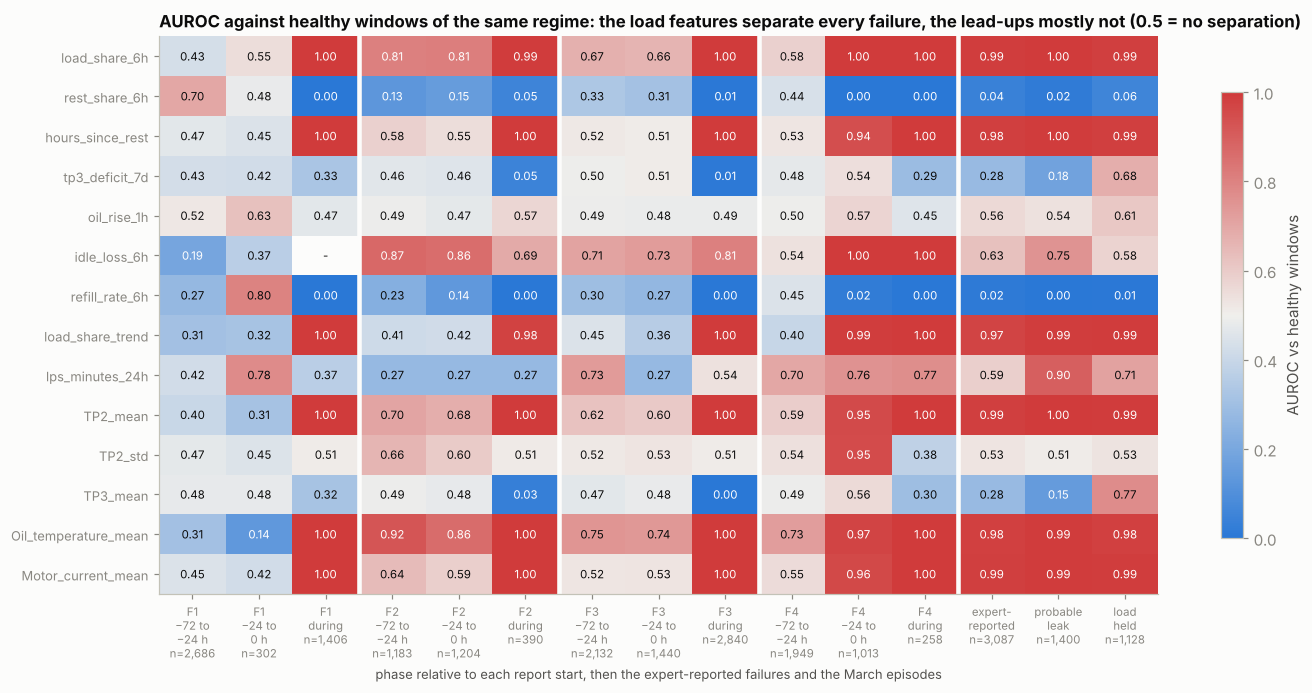

week from,Mar 01,Mar 08,Mar 15,Mar 22,Mar 29,Apr 05,Apr 19,Apr 26,May 03,May 10,May 17
oil temperature (deg C),65.1,61.9,57.3,60.3,61.3,59.8,56.8,58.7,58.4,56.7,66.0
load share (6 h),0.15,0.12,0.08,0.10,0.11,0.10,0.07,0.10,0.08,0.08,0.19


In [44]:
def auroc(pos, neg):
    """Probability that a window from `pos` scores above one from `neg` (0.5 = no separation)."""
    pos, neg = pos[~np.isnan(pos)], neg[~np.isnan(neg)]
    if len(pos) < 30:
        return np.nan
    ranks = pd.Series(np.concatenate([pos, neg])).rank().to_numpy()
    return (ranks[:len(pos)].sum() - len(pos) * (len(pos) + 1) / 2) / (len(pos) * len(neg))


EVIDENCE = ['load_share_6h', 'rest_share_6h', 'hours_since_rest', 'tp3_deficit_7d', 'oil_rise_1h',
            'idle_loss_6h', 'refill_rate_6h', 'load_share_trend', 'lps_minutes_24h',
            'TP2_mean', 'TP2_std', 'TP3_mean', 'Oil_temperature_mean', 'Motor_current_mean']
healthy_w = windows[windows.zone == 'negative']
auc_cols, sizes = {}, {}
for i, (s, e, _) in enumerate(FAILURE_WINDOWS, start=1):
    ref = healthy_w[healthy_w.regime == ('normal' if s < REGIME_SPLITS[1] else 'dv_pressure_flat')].iloc[::3]
    phases = [('−72 to\n−24 h', s - pd.Timedelta(hours=72), s - pd.Timedelta(hours=24)),
              ('−24 to\n0 h', s - pd.Timedelta(hours=24), s), ('during', s, e)]
    for label, a, b in phases:
        m = (windows.window_end > a) & (windows.window_end <= b)
        key = f'F{i}\n{label}'
        sizes[key] = int(m.sum())
        auc_cols[key] = [auroc(windows.loc[m, f].to_numpy(float), ref[f].to_numpy(float)) for f in EVIDENCE]
ref = healthy_w[healthy_w.regime == 'normal'].iloc[::3]
groups = [('expert-\nreported', (windows.zone_detail == 'expert_reported') & (windows.expert_failure != 'none')),
          ('probable\nleak', windows.zone_detail == 'uncertain:probable_leak'),
          ('load\nheld', windows.zone_detail == 'uncertain:load_held')]
for label, m in groups:
    sizes[label] = int(m.sum())
    auc_cols[label] = [auroc(windows.loc[m, f].to_numpy(float), ref[f].to_numpy(float)) for f in EVIDENCE]
evidence = pd.DataFrame(auc_cols, index=EVIDENCE)

fig, ax = plt.subplots(figsize=(13, 6.4))
im = ax.imshow(evidence.to_numpy(float), cmap=DIVERGING, vmin=0, vmax=1, aspect='auto')
ax.set_xticks(range(evidence.shape[1]), [f'{k}\nn={sizes[k]:,}' for k in evidence.columns], fontsize=7.5)
ax.set_xlabel('phase relative to each report start, then the expert-reported failures and the March episodes', fontsize=8.5)
ax.set_yticks(range(len(EVIDENCE)), EVIDENCE, fontsize=8.5)
for r in range(evidence.shape[0]):
    for c in range(evidence.shape[1]):
        v = evidence.iat[r, c]
        ax.text(c, r, '-' if np.isnan(v) else f'{v:.2f}', ha='center', va='center', fontsize=7.5,
                color=INK if np.isnan(v) or abs(v - 0.5) < 0.3 else '#ffffff')
for x in (2.5, 5.5, 8.5, 11.5):
    ax.axvline(x, color=SURFACE, lw=3)
ax.set_title('AUROC against healthy windows of the same regime: the load features separate every failure, '
             'the lead-ups mostly not (0.5 = no separation)')
ax.grid(False)
fig.colorbar(im, ax=ax, shrink=0.8, label='AUROC vs healthy windows')
fig.tight_layout()
plt.show()

# Season check for the F2/F3 lead-ups: healthy windows of their regime, week by week from Mar 1.
healthy_weeks = (healthy_w[healthy_w.regime == 'normal'].set_index('window_end')
                 [['Oil_temperature_mean', 'load_share_6h']]
                 .resample('168h', origin=REGIME_SPLITS[0]).mean().dropna())
healthy_weeks.index = healthy_weeks.index.strftime('%b %d').rename('week from')
pd.DataFrame({'oil temperature (deg C)': healthy_weeks.Oil_temperature_mean.map('{:.1f}'.format),
              'load share (6 h)': healthy_weeks.load_share_6h.map('{:.2f}'.format)}).T

### 8.3 · The engineered channels over the campaign

Four of the engineered channels, as hourly extremes, show how specific they are. Load share and hours since
rest jump in every report window, in every expert-reported failure long enough to show at this scale, and in
the three March episodes (the yellow bands).

The pressure deficit falls in the leaks, but most of its deepest dips come from restarts. The first table
lists the deepest window of each day for the ten deepest days: nearly all are the first complete window after
recording resumes, 10–11 minutes in, with TP3 at 0.7–3.0 bar on resume; those fall in gap edges or the Jun 8
grey period. The one that does not, Jul 8 at 18:06, has no missing point in the hour before it: TP3 falls from
about 9 bar to under 2 between 17:45 and 18:00 with the motor loaded, bottoms at 1.2 and is back above 9 by
18:15. The expert logged it: failure #19, a week before F4.

Recording gaps also act as a leak-down test that nobody planned (second table). Across the gaps of 5 to 120
minutes, TP3 loses a fraction of a bar as a rule, but a few lose 6 to 9 bar in under an hour: twice on the
afternoon of Mar 12, a few hours after that morning's load-held episode, once in the Jun 8 grey period before
F3's repair, and on Apr 19 at 02:14, a restart inside F1's guard band. None is detector training data. Whether
they are leaks or the system being vented needs the maintenance records; the check that reads them (C8) now
has `gap_leak_down` as its input, and the events go to `events.yaml` as data-quality events.

Read together, the channels suggest how to tell the cases apart. Sustained load points to a failure the expert
would report, whether pressure falls or holds; low pressure right after recording resumes, or with the motor
off, is a data-quality case. No single feature does this, which is the argument for a multivariate detector
followed by the agent's deterministic checks.

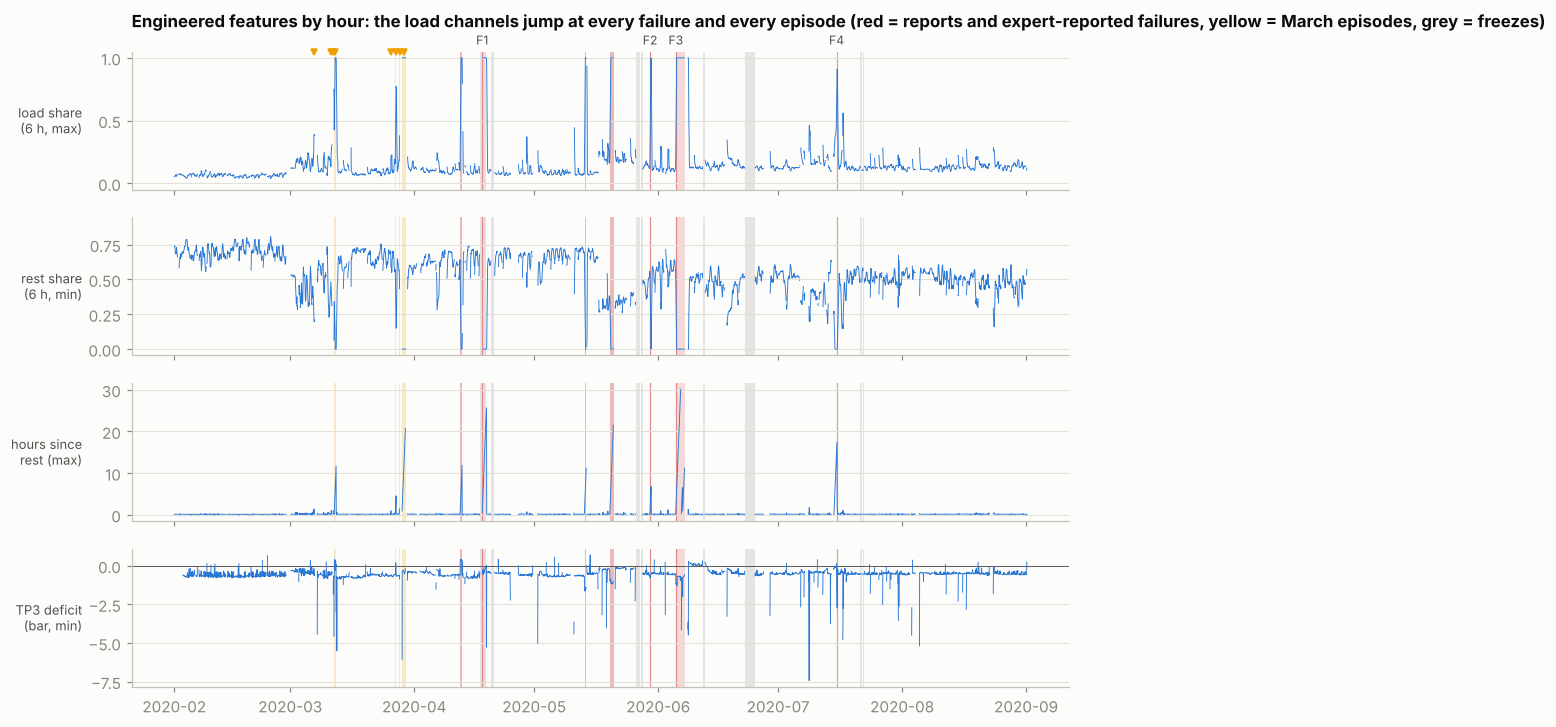

In [45]:
# Hourly extremes in the direction each channel moves in a leak.
hourly_feats = (windows.set_index('window_end')
                [['load_share_6h', 'rest_share_6h', 'hours_since_rest', 'tp3_deficit_7d']]
                .resample('h').agg({'load_share_6h': 'max', 'rest_share_6h': 'min',
                                    'hours_since_rest': 'max', 'tp3_deficit_7d': 'min'}))
labels = ['load share\n(6 h, max)', 'rest share\n(6 h, min)', 'hours since\nrest (max)', 'TP3 deficit\n(bar, min)']
fig, axes = plt.subplots(4, 1, figsize=(11, 7.5), sharex=True)
for ax, col, lab in zip(axes, hourly_feats.columns, labels):
    ax.plot(hourly_feats.index, hourly_feats[col], color=BLUE, lw=0.6, zorder=3)
    for s, e, _ in UNCERTAIN:
        ax.axvspan(s, e, color=YELLOW, alpha=0.22, lw=0)
    shade_expert(ax)
    for s, e, _ in FAILURE_WINDOWS:
        ax.axvline(s, color=CRITICAL, lw=0.8, alpha=0.5, zorder=1)
    shade_failures(ax)
    shade_freezes(ax)
    ax.set_ylabel(lab, rotation=0, ha='right', va='center', fontsize=8.5)
    ax.grid(axis='x', visible=False)
top = axes[0].get_xaxis_transform()
for i, (s, e, _) in enumerate(FAILURE_WINDOWS, start=1):
    axes[0].text(s, 1.03, f'F{i}', transform=top, ha='center', va='bottom', fontsize=8, color=INK2)
for s, e, tag in UNCERTAIN:
    axes[0].plot([s + (e - s) / 2], [1.0], marker='v', ms=4, color=YELLOW, transform=top, clip_on=False)
axes[3].axhline(0, color=INK2, lw=0.6)
axes[0].set_title('Engineered features by hour: the load channels jump at every failure and every episode '
                  '(red = reports and expert-reported failures, yellow = March episodes, grey = freezes)', pad=16)
fig.align_ylabels(axes)
plt.show()

In [46]:
# The deepest pressure dips: the lowest window of each day, then the ten lowest days, with
# what the raw channels do in the hour before each window ends.
tp3v_grid, missing_grid = np.where(grid_valid, grid.TP3.to_numpy(), np.nan), ~grid_valid
rid = np.cumsum(np.r_[True, missing_grid[1:] != missing_grid[:-1]])
rlen = np.bincount(rid)[rid]
masked_run = np.bincount(rid, weights=(grid.zone_code.to_numpy() == CODE['masked'])) > 0
gap_rows = []
for i in np.flatnonzero(missing_grid & np.r_[True, ~missing_grid[:-1]]):
    n = rlen[i]
    if 0 < i and i + n < len(grid) and not masked_run[rid[i]] and (n + 1) * 10 >= 300:
        gap_rows.append({'gap start': grid.index[i], 'resume': grid.index[i + n], 'minutes': round((n + 1) / 6, 1),
                         'TP3 before': tp3v_grid[i - 1], 'TP3 after': tp3v_grid[i + n]})
gaps5 = pd.DataFrame(gap_rows)
gaps5['bar lost'] = gaps5['TP3 before'] - gaps5['TP3 after']

deficit = windows.set_index('window_end').tp3_deficit_7d.dropna()
deepest = deficit.loc[deficit.groupby(deficit.index.floor('D')).idxmin().to_numpy()].nsmallest(10)
zone_at = windows.set_index('window_end').zone_detail
expert_at = windows.set_index('window_end').expert_failure
dip_rows = []
for end, value in deepest.items():
    hour = grid.loc[end - pd.Timedelta(hours=1):end - pd.Timedelta(STEP)]
    raw = hour[hour.observed | hour.bridged]
    gap = gaps5[(gaps5.resume > end - pd.Timedelta(hours=1)) & (gaps5.resume < end)].tail(1)
    dip_rows.append({'window end': end, 'deficit (bar)': round(value, 2), 'zone': zone_at.loc[end],
                     'expert #': expert_at.loc[end],
                     'missing points': len(hour) - len(raw),
                     'gap before (min)': f'{gap.minutes.iat[0]:.0f}' if len(gap) else '',
                     'resumed (min before)': f'{(end - gap.resume.iat[0]).total_seconds() / 60:.0f}' if len(gap) else '',
                     'TP3 at resume (bar)': f'{gap["TP3 after"].iat[0]:.2f}' if len(gap) else '',
                     'TP3 lowest (bar)': round(raw.TP3.min(), 2),
                     'motor loaded (%)': round(100 * (raw.Motor_current > LOADED_A).mean()),
                     'load commanded, motor off (%)':
                         round(100 * ((raw.DV_eletric == 1) & (raw.Motor_current < REST_A)).mean())})
print(pd.DataFrame(dip_rows).set_index('window end').to_string())
off = windows[windows.cmd_motor_off > 0]
print(f'deepest deficit in a window with load commanded and the motor off: {off.tp3_deficit_7d.min():.2f} bar '
      f'({off.window_end[off.tp3_deficit_7d.idxmin()]:%b %d %H:%M})')

# The Jul 8 drop in 5-minute means: the expert's failure #19.
print('\nJul 8, 17:40 to 18:25 (5-minute means), the expert\'s failure #19:')
jul8 = grid.loc['2020-07-08 17:40':'2020-07-08 18:24:50', ['TP3', 'Motor_current', 'DV_eletric', 'LPS']]
print(jul8.resample('5min').mean().round(2).T.to_string())

                     deficit (bar)             zone expert #  missing points gap before (min) resumed (min before) TP3 at resume (bar)  TP3 lowest (bar)  motor loaded (%)  load commanded, motor off (%)
window end                                                                                                                                                                                               
2020-07-08 18:06:00          -7.43  expert_reported       19               0                                                                        1.20                44                              0
2020-03-28 23:16:00          -6.06         gap_edge     none             297              856                   10                0.73              0.73               100                              0
2020-03-12 15:39:00          -5.51         gap_edge     none             286               48                   10                0.93              0.93                85                      

In [47]:
# Pressure lost across recording gaps of 5 to 120 minutes, a leak-down test nobody planned,
# with the zone of the first complete window after each. The large losses go to events.yaml.
leak_down = gaps5[gaps5.minutes <= 120].copy()
first_after = windows.window_start.searchsorted(leak_down.resume)
leak_down['next window'] = [windows.zone_detail.iat[k] if k < len(windows) else '' for k in first_after]
print(f'TP3 lost across the {len(leak_down)} recording gaps of 5 to 120 min: median '
      f'{leak_down["bar lost"].median():.2f} bar, 90th percentile {leak_down["bar lost"].quantile(0.9):.2f}; the largest losses:')
big_loss = leak_down.nlargest(6, 'bar lost')
print(big_loss.set_index('gap start').drop(columns='resume').round(2).to_string())
LOSS_FLOOR = 5.0
print(f'\nevents.yaml v0.3, data_quality_events.gap_pressure_loss (losses above {LOSS_FLOOR:.0f} bar):')
for r in leak_down[leak_down['bar lost'] > LOSS_FLOOR].sort_values('gap start').itertuples(index=False):
    print(f'    - {{gap_start: {r[0]:%Y-%m-%d %H:%M:%S}, resume: {r[1]:%Y-%m-%d %H:%M:%S}, minutes: {r[2]:.0f}, '
          f'tp3_before_bar: {r[3]:.2f}, tp3_after_bar: {r[4]:.2f}, next_window: {r[6]}}}')

TP3 lost across the 149 recording gaps of 5 to 120 min: median 0.39 bar, 90th percentile 2.43; the largest losses:
                     minutes  TP3 before  TP3 after  bar lost      next window
gap start                                                                     
2020-03-12 14:40:50     47.8        9.64       0.93      8.71         gap_edge
2020-03-12 16:18:10     19.2        9.20       0.89      8.31  after_uncertain
2020-06-08 13:07:20     33.0        8.04       1.01      7.03      grey_period
2020-04-19 02:14:30     22.5        7.74       1.00      6.74          failure
2020-03-03 10:29:20     68.3        9.93       5.05      4.87         gap_edge
2020-07-17 00:58:40     15.8        6.55       1.89      4.66  expert_reported

events.yaml v0.3, data_quality_events.gap_pressure_loss (losses above 5 bar):
    - {gap_start: 2020-03-12 14:40:50, resume: 2020-03-12 15:28:30, minutes: 48, tp3_before_bar: 9.64, tp3_after_bar: 0.93, next_window: gap_edge}
    - {gap_start: 2020-03-1

### 8.4 · Redundancy

On healthy windows, a dozen pairs among the 30 summary-and-engineered features correlate at |r| ≥ 0.9. Most
pair TP2 with H1, which mirror each other (Section 3), or statistics within one signal. For the tabular
baselines (z-score, PCA), a greedy pass that keeps the first feature of each remaining pair gives the drop list
printed below, which is also a column of the feature dictionary (`drop_for_tabular`), so no consumer types
it in. The 21 inputs the Oct 1 detector was frozen on are the 30 less the nine the v3.3 pass dropped; they are
flagged in the dictionary as `detector_v1` whatever this run's pass says, and the cell prints whether the two
lists still agree. The deep detectors take the sequences and need no pruning. The two data-quality flags are
non-zero in under half a percent of healthy windows, which is why they stay out of the detector, and the state
and leak groups are for the state-aware detector and the checks, not for PCA v1.

In [48]:
TABULAR = list(FEATURE_DICT.feature[FEATURE_DICT.role.isin(['summary statistic', 'engineered'])])
DROPPED_V33 = ['H1_std', 'H1_min', 'TP2_max', 'H1_slope', 'Oil_temperature_max', 'rest_share_6h',
               'H1_mean', 'Oil_temperature_min', 'Oil_temperature_slope']      # EDA v3.3 Section 8.4
DETECTOR_V1 = [f for f in TABULAR if f not in DROPPED_V33]                   # the frozen detector's 21 inputs

sample = healthy_w.iloc[::5][TABULAR]
corr = sample.corr()
pairs = [(a, b, round(corr.loc[a, b], 3)) for i, a in enumerate(TABULAR) for b in TABULAR[i + 1:]
         if abs(corr.loc[a, b]) >= 0.9]
spread = healthy_w[FEATURES].quantile(0.75) - healthy_w[FEATURES].quantile(0.25)
print('features with zero interquartile range on healthy windows: ' + ', '.join(spread.index[spread == 0]))
flags = (healthy_w[['cmd_motor_off', 'n_bridged']] > 0).mean()
print('healthy windows where a data-quality flag is non-zero: '
      + ', '.join(f'{k} {v:.2%}' for k, v in flags.items()))
drop = []
for a, b, r in sorted(pairs, key=lambda p: -abs(p[2])):
    if (a, b) == ('TP3_mean', 'tp3_deficit_7d') or a in drop or b in drop:
        continue
    drop.append(b)
print(f'{len(pairs)} pairs at |r| >= 0.9; suggested drops for the tabular baselines: ' + ', '.join(drop))
print('same list as v3.3 (the frozen detector\'s): ' + ('yes' if sorted(drop) == sorted(DROPPED_V33) else
      'NO: ' + ', '.join(sorted(set(drop) ^ set(DROPPED_V33))) + ' differ; detector_v1 keeps the frozen list'))
FEATURE_DICT['detector_v1'] = FEATURE_DICT.feature.isin(DETECTOR_V1)
FEATURE_DICT['drop_for_tabular'] = FEATURE_DICT.feature.isin(drop)
(pd.DataFrame(pairs, columns=['feature', 'redundant with', 'r on healthy windows'])
   .sort_values('r on healthy windows', key=abs, ascending=False).reset_index(drop=True))

features with zero interquartile range on healthy windows: minutes_since_data_resumed, gap_hours, cmd_motor_off, n_bridged
healthy windows where a data-quality flag is non-zero: cmd_motor_off 0.42%, n_bridged 0.15%
15 pairs at |r| >= 0.9; suggested drops for the tabular baselines: H1_std, H1_min, TP2_max, H1_slope, TP2_std, rest_share_6h, Oil_temperature_max, Oil_temperature_min, H1_mean, Oil_temperature_slope
same list as v3.3 (the frozen detector's): NO: TP2_std differ; detector_v1 keeps the frozen list


,feature,redundant with,r on healthy windows
0,TP2_std,H1_std,0.996
1,TP2_max,H1_min,-0.988
2,TP2_std,TP2_max,0.969
3,TP3_mean,tp3_deficit_7d,0.969
4,TP2_max,H1_std,0.963
5,TP2_slope,H1_slope,-0.952
6,TP2_std,H1_min,-0.947
7,H1_std,H1_min,-0.946
8,load_share_6h,rest_share_6h,-0.940
9,TP2_mean,TP2_std,0.940


### 8.5 · Leakage checks

Four checks, all printed below:

1. **Causality.** At twelve cut instants, the features are rebuilt two ways and compared with the full run over
   the last day before the cut. The cuts cover ordinary days, a load episode, the four reports and F4's guard
   band, minutes after a restart, hours after a freeze and minutes after a bridged point. On a grid truncated at
   the cut, every window that ends by the cut matches, so no feature reads past a window's last point. On a
   grid rebuilt from the raw rows before the cut, every window that ends 30 s or more before it matches, so
   bridging is the only step there that looks ahead. The largest differences are floating-point rounding
   (the trailing sums are running totals, so a sum started at a different point can differ in the last digits).
2. **No labels.** No zone, event, block, look-back, split, role, key or time column is among the features.
3. **Hindsight upstream.** Bridging fills at most two points from a later sample, so a streaming scorer has to
   wait up to 20 s after a window ends before it can score it. The freeze masks use hindsight too: a run is only
   known to be a freeze once it has lasted 30 minutes, so the streaming path needs its own freeze check.
4. **Scaling.** The scaling statistics saved with the features come from the negative windows with the `fit`
   role that read no test block, so one scaler is valid in every fold. Two scalers are saved: the median and
   interquartile range, with per-regime medians, and the mean and standard deviation, which is what the
   detector-selection run fitted, because three features are bimodal with an interquartile range near zero.
   The medians over the fit windows are also the values a missing feature takes at scoring time.

In [49]:
# 1. Causality, tested two ways at twelve cut instants. Each test uses the 8 days before the cut and
#    compares the windows of the last day with the full run.
#    (a) Features from a grid truncated at the cut match for every window that ends by the cut:
#        window_features reads nothing past a window's last point.
#    (b) A grid rebuilt from the raw rows before the cut matches for every window that ends at
#        least 30 s before it: bridging is the only step that looks ahead.
CUTS = [T(c) for c in ['2020-02-20 08:00', '2020-03-12 06:00', '2020-04-18 12:00', '2020-05-10 23:00',
                       '2020-05-30 03:00', '2020-06-06 20:00', '2020-06-08 12:00', '2020-06-25 09:00',
                       '2020-07-15 12:00', '2020-07-15 17:30', '2020-08-20 10:00']]
bridged_at = grid.index[grid.bridged.to_numpy()]
if len(bridged_at):
    CUTS.append(bridged_at[len(bridged_at) // 2] + pd.Timedelta(STEP))
SPAN, DAY_TD = pd.Timedelta(days=8, hours=1), pd.Timedelta(days=1)
TOLERANCE = 1e-6                     # running totals started at different points differ in the last digits
F_FULL = feats.to_numpy(float)


def compare(sub_grid, keep_until):
    """Features on sub_grid against the full run, for windows ending in (cut - 1 day, keep_until]."""
    ends = window_ends(sub_grid)
    f_sub = window_features(sub_grid, ends).to_numpy(float)
    end_t = sub_grid.index[ends] + pd.Timedelta(STEP)
    keep = (end_t > cut - DAY_TD) & (end_t <= keep_until)
    pos = grid.index.searchsorted(sub_grid.index[0]) + ends[keep]
    rows = np.searchsorted(win_end_pos, pos)
    assert (win_end_pos[rows] == pos).all()
    a, b = f_sub[keep], F_FULL[rows]
    same_nan = bool((np.isnan(a) == np.isnan(b)).all())
    n_complete = int(windows_all.complete.to_numpy()[rows].sum())
    return int(keep.sum()), n_complete, float(np.nanmax(np.abs(a - b))), same_nan


causal = []
for cut in CUTS:
    lo = cut - SPAN
    sub = grid.iloc[grid.index.searchsorted(lo):grid.index.searchsorted(cut)]
    n_a, full_a, diff_a, nan_a = compare(sub, cut)
    raw_rows = ((df.timestamp >= lo) & (df.timestamp < cut)).to_numpy()
    n_b, full_b, diff_b, nan_b = compare(to_grid(df[raw_rows], frozen[raw_rows]), cut - pd.Timedelta(seconds=30))
    before = grid.index.searchsorted(cut) - 1
    causal.append({'cut': cut, 'zone at cut': ZONE_DETAIL[grid.zone_code.iat[before]],
                   'min since missing data': round((cut - gap_t[gap_t.searchsorted(cut) - 1]).total_seconds() / 60),
                   'windows (a)': n_a, 'complete (a)': full_a, 'largest difference (a)': diff_a,
                   'windows (b)': n_b, 'largest difference (b)': diff_b, 'same missing values': nan_a and nan_b})
causal = pd.DataFrame(causal).set_index('cut')
print(causal.to_string())
print(f'all {len(CUTS)} cuts match within {TOLERANCE:g}: '
      f'{bool(((causal.filter(like="difference") < TOLERANCE).all(axis=None)) and causal["same missing values"].all())}')

# 2. No labels among the features.
label_cols = {'zone', 'zone_detail', 'regime', 'neg_split', 'neg_role', 'window_start', 'window_end', 'event',
              'expert_failure', 'aligned', 'group_id',
              *[f'{k}_F{i}' for k in ('block', 'lookback') for i in range(1, 5)]}
print('\nlabel or time columns among the features:', sorted(label_cols & set(FEATURES)) or 'none')

# 3. Bridging looks ahead by at most one gap of 30 s.
run_id = np.cumsum(np.r_[True, grid.bridged.to_numpy()[1:] != grid.bridged.to_numpy()[:-1]])
longest = int(np.bincount(run_id, weights=grid.bridged.to_numpy()).max())
print(f'longest bridged run: {longest} points ({longest * 10} s)')

# 4. Scaling statistics from the fit-role negative windows only, leaving out every window whose
#    look-back reaches a test block, so one scaler is valid in every fold.
fit_w = healthy_w[(healthy_w.neg_role == 'fit') & ~healthy_w.filter(like='lookback_F').any(axis=1)]
iqr = fit_w[FEATURES].quantile(0.75) - fit_w[FEATURES].quantile(0.25)
scaler = pd.DataFrame({'median': fit_w[FEATURES].median(), 'iqr': iqr.where(iqr > 0),      # per feature, over the
                       'mean': fit_w[FEATURES].mean(), 'std': fit_w[FEATURES].std(ddof=0),  # windows where it is present
                       'present': fit_w[FEATURES].notna().sum()})
for reg in ['light_duty', 'normal', 'dv_pressure_flat']:
    scaler[f'median_{reg}'] = fit_w.loc[fit_w.regime == reg, FEATURES].median()
print(f'scaler from {len(fit_w):,} fit-role negative windows with no look-back into a test block; each statistic '
      f'is taken over the windows where the feature is present ({int(scaler.present.min()):,} to {int(scaler.present.max()):,}); '
      'IQR left empty where it is zero: ' + ', '.join(iqr.index[iqr == 0]))
scaler.loc[['load_share_6h', 'rest_share_6h', 'hours_since_rest', 'tp3_deficit_7d', 'Oil_temperature_mean',
            'TP2_slope', 'Motor_current_min', 'idle_loss_6h', 'refill_rate_6h']].round(3)

                             zone at cut  min since missing data  windows (a)  complete (a)  largest difference (a)  windows (b)  largest difference (b)  same missing values
cut                                                                                                                                                                          
2020-02-20 08:00:00             negative                     206         1440           909            1.113598e-11         1439            1.113598e-11                 True
2020-03-12 06:00:00  uncertain:load_held                     442         1440           829            6.144862e-11         1439            6.144862e-11                 True
2020-04-18 12:00:00              failure                     696         1440           687            1.127098e-11         1439            1.127098e-11                 True
2020-05-10 23:00:00             gap_edge                      11         1440            68            6.478640e-11         1439  

,median,iqr,mean,std,present,median_light_duty,median_normal,median_dv_pressure_flat
load_share_6h,0.099,0.053,0.101,0.041,75915,0.059,0.094,0.120
rest_share_6h,0.619,0.168,0.608,0.114,75915,0.713,0.636,0.532
hours_since_rest,0.000,0.058,0.033,0.054,76662,0.000,0.000,0.000
tp3_deficit_7d,0.043,0.581,0.041,0.369,76488,0.018,0.063,0.032
Oil_temperature_mean,60.950,8.201,60.948,5.221,76662,56.815,60.042,65.641
TP2_slope,0.000,0.004,0.001,4.012,76662,0.000,0.000,0.000
Motor_current_min,0.038,0.002,0.085,0.412,76662,0.035,0.040,0.040
idle_loss_6h,5.431,2.685,5.840,1.882,75617,4.191,5.266,7.038
refill_rate_6h,1.058,0.148,1.076,0.128,75595,1.265,1.050,1.024


### 8.6 · Saved for the modeling phase

Everything the next phase needs goes to a `processed/` folder beside the data file, which is
`data/processed/` in the repository and ignored by git:

- `grid_10s.csv.gz`: the 10 s grid with the observed and bridged flags and both zone columns, one row per
  grid point;
- `windows_10min.csv.gz` (and `windows_10min.parquet` when pyarrow is installed): one row per complete
  window, with zones, regime, event, the expert's failure numbers, test blocks, look-back flags, the splits,
  the `aligned` flag, the `group_id` and all 42 features;
- `feature_dictionary.csv` (definition, unit, look-back, role, `detector_v1`, `drop_for_tabular`) and
  `scaler_negative.csv` (median, IQR, mean, std, per-regime medians);
- `manifest.json`: the source file's SHA-256, every zone and fold input (failure windows, repairs, the
  expert's log and its band, masks, uncertain and grey periods, the gap edges, regime splits, test blocks),
  the feature parameters, and the counts a pipeline test should reproduce.

The two tables are gzip-compressed CSV and the rest plain CSV and JSON, so reading them needs nothing beyond
pandas. A consumer that wants the frozen detector's inputs reads `feature_dictionary.csv` and keeps the rows
with `detector_v1`; one that wants the three-way split reads `neg_role`.

In [50]:
import hashlib
import json

OUT = DATA_PATH.parent / 'processed'
OUT.mkdir(parents=True, exist_ok=True)
gz = {'method': 'gzip', 'compresslevel': 1}
grid.drop(columns='zone_code').to_csv(OUT / 'grid_10s.csv.gz', float_format='%.7g', compression=gz)
windows.to_csv(OUT / 'windows_10min.csv.gz', index=False, float_format='%.6g', compression=gz)
try:
    windows.to_parquet(OUT / 'windows_10min.parquet', index=False)
    parquet = {'rows': len(windows), 'columns': windows.shape[1]}
except (ImportError, ValueError) as exc:
    parquet = f'not written ({type(exc).__name__}: install pyarrow)'
FEATURE_DICT.to_csv(OUT / 'feature_dictionary.csv', index=False)
scaler.to_csv(OUT / 'scaler_negative.csv', index_label='feature')

sha = hashlib.sha256()
with open(DATA_PATH, 'rb') as fh:
    for chunk in iter(lambda: fh.read(1 << 20), b''):
        sha.update(chunk)
iso = lambda t: None if t is None else pd.Timestamp(t).isoformat()
role_counts = windows.neg_role.value_counts().to_dict()
manifest = {
    'created_by': 'notebooks/metropt3_eda.ipynb v4, Sections 7-8',
    'source': {'file': DATA_PATH.name, 'rows': len(df), 'sha256': sha.hexdigest()},
    'label_sources': {'failures': 'UCI description PDF: the four air leaks that forced a repair (F1-F4), day-granular',
                      'expert_reported': 'Davari et al. (2021), Table II: 21 failures reported by the maintenance expert, April-July, to the minute'},
    'grid': {'step': STEP, 'bins': 'epoch-aligned; analog mean, digital last', 'max_bridge_s': MAX_BRIDGE_S,
             'bridge_rule': 'interior runs with (run + 1) x step <= max_bridge_s',
             'freeze_masks': [[iso(s), iso(e)] for s, e in FREEZE_MASKS]},
    'zones': {'precedence': ZONE_DETAIL[::-1], 'guard_band': [str(GUARD_BEFORE), str(GUARD_AFTER)],
              'expert_band': [str(EXPERT_BEFORE), str(EXPERT_AFTER)],
              'healthy_buffer': {'before_report': str(BUFFER_BEFORE), 'after_repair': str(BUFFER_AFTER),
                                 'no_repair': 'counted from the report end'},
              'gap_edge': {'after_gaps_of': str(STOP_MIN), 'length': str(GAP_EDGE),
                           'gaps': 'raw timestamp gaps; freezes keep their timestamps and are not gaps',
                           'spans': [[iso(s), iso(e)] for s, e in GAP_EDGES]},
              'failures': [{'id': f'F{i}', 'start': iso(s), 'end': iso(e), 'repair': iso(r)}
                           for i, ((s, e, _), r) in enumerate(zip(FAILURE_WINDOWS, REPAIRS), start=1)],
              'expert_reported': [{'n': n, 'start': iso(s), 'end': iso(e)} for n, s, e in EXPERT_REPORTED],
              'uncertain_periods': [[iso(s), iso(e), tag] for s, e, tag in UNCERTAIN],
              'grey_periods': [[iso(s), iso(e)] for s, e in GREY],
              'regime_splits': [iso(t) for t in REGIME_SPLITS]},
    'windows': {'length': str(WIN_LEN), 'stride': '1min', 'complete': 'all points observed or bridged',
                'lookback': str(LOOKBACK),
                'after_uncertain': 'negative window whose look-back reaches an uncertain period, an expert-reported episode or a report',
                'aligned': 'window_start on a ten-minute boundary: the non-overlapping subset',
                'group_id': 'the hour of window_start, for grouped validation splits'},
    'folds': {'test_blocks': {k: [iso(a), iso(b)] for k, (a, b) in BLOCKS.items()}, 'paired': ['F2', 'F3'],
              'lookback_days': 7,
              'lookback_columns': 'negative windows whose 7-day look-back reaches a block; leave them out of that fold',
              'neg_split': 'ISO week of window_start: even = fit, odd = calibrate (kept for older readers)',
              'neg_role': 'ISO week of window_start: even = fit; odd and week mod 4 = 1 calibrate; odd and week mod 4 = 3 check',
              'none_label': 'none'},
    'features': {'inputs': INPUTS, 'loaded_above_A': LOADED_A, 'stopped_below_A': REST_A, 'cut_out_bar': CUT_OUT_BAR,
                 'share_window': '6h', 'share_min_data': '1h', 'stop': f'{int(STOP_MIN.total_seconds() // 60)}min gap or freeze',
                 'deficit_baseline': 'median of per-minute TP3 over the 7 days before the window', 'deficit_min_coverage': 0.25,
                 'state_horizon': '6h', 'refill_min_minutes': 5, 'idle_loss_min_minutes': 60, 'lps_window': '24h',
                 'roles': FEATURE_DICT.role.value_counts().to_dict(),
                 'detector_v1': DETECTOR_V1, 'drop_for_tabular': drop},
    'expected_counts': {'grid_points': len(grid), 'complete_windows': len(windows),
                        'negative_windows': int((windows.zone == 'negative').sum()),
                        'aligned_negative_windows': int((windows.aligned & (windows.zone == 'negative')).sum()),
                        'negative_by_role': {k: int(v) for k, v in role_counts.items() if k != 'none'},
                        'expert_reported_windows': int((windows.zone_detail == 'expert_reported').sum()),
                        'aligned_negative_section6_exclusions': len(base)},
    'outputs': {'grid_10s.csv.gz': {'rows': len(grid), 'columns': grid.shape[1]},   # timestamp in, zone_code out
                'windows_10min.csv.gz': {'rows': len(windows), 'columns': windows.shape[1]},
                'windows_10min.parquet': parquet,
                'feature_dictionary.csv': {'rows': len(FEATURE_DICT)},
                'scaler_negative.csv': {'rows': len(scaler),
                                        'fitted_on': 'negative windows, fit role, no look-back into a test block'}},
}
(OUT / 'manifest.json').write_text(json.dumps(manifest, indent=2))

back = pd.read_csv(OUT / 'windows_10min.csv.gz', nrows=1000)
print('read back windows_10min.csv.gz: columns match' if list(back.columns) == list(windows.columns)
      else 'read back: COLUMN MISMATCH')
pd.DataFrame({'MB': {p.name: round(p.stat().st_size / 1e6, 1) for p in sorted(OUT.iterdir()) if p.is_file()}})

read back windows_10min.csv.gz: columns match


,MB
feature_dictionary.csv,0.0
grid_10s.csv.gz,28.1
manifest.json,0.0
scaler_negative.csv,0.0
windows_10min.csv.gz,27.7


## 9 · Fact sheet and implications

The fact sheet is printed from the run's own variables, so it is the record of this execution; the prose in
the sections above quotes only the few numbers that carry an argument and points to the tables for the rest.

In [51]:
healthy_s6 = int(w.healthy.sum())
FACTS = {
    'records': f'{len(df):,}',
    'span': f'{df.timestamp.min():%Y-%m-%d} -> {df.timestamp.max():%Y-%m-%d}, fixed UTC clock',
    'sampling step': f'{step:g} s ({1 / step:.3g} Hz); real steps 9-10 s',
    f'gaps > {GAP_FACTOR}x step': f'{len(big):,} ({big.delta_s.sum() / 3600:,.1f} h); {len(long_)} of 12 h or more ({long_.delta_s.sum() / 3600:.0f} h)',
    'restarts after gaps >= 30 min': f'{len(restarts)}; TP3 below {RECOVER_BAR:.0f} bar at resume in {(restarts["TP3 at resume"] < RECOVER_BAR).mean():.0%}',
    'logger freezes': f'{len(freezes)} runs, {freezes.hours.sum():.1f} h, {frozen.mean():.1%} of rows',
    'repair-forcing failures (F1-F4)': f'{len(FAILURE_WINDOWS)} air leaks, {sum((e - s).total_seconds() for s, e, _ in FAILURE_WINDOWS) / 3600:.1f} h of report windows',
    'expert-reported failures': f'{len(EXPERT_REPORTED)} (Apr-Jul), {len(EXPERT_REPORTED) - 8} outside F1-F4',
    'continuous-load runs >= 30 min': f'{len(episodes)}; with no report in either source: {len(unrep)}, all in March, all uncertain periods',
    'LPS activity': f'{int((lps_minutes >= 60).sum())} days with an hour or more, {int((lps_minutes >= 20).sum())} with 20 min or more',
    'motor-off command spells': f'{len(spells)} of 5 min or more, {int(spells.minutes.sum())} min in all',
    'healthy windows (Section 6)': f'{healthy_s6:,} x 10 min (~{healthy_s6 * 10 / 1440:.0f} days); longest unbroken stretch {run_len.max() * 10 / 60:.0f} h',
    '10 s grid': f'{len(grid):,} points; {int(grid.bridged.sum())} bridged, {(~grid_valid).sum() / 360:,.0f} h missing',
    'zone hours with data': ', '.join(f'{z} {h:,.0f}' for z, h in grid[grid_valid].groupby("zone", observed=False).size().div(360).items()),
    'model-ready windows': f'{len(windows):,} complete (10 min, 1 min stride); {int((windows.zone == "negative").sum()):,} negative, '
                           f'{int((windows.aligned & (windows.zone == "negative")).sum()):,} of them non-overlapping',
    'negative windows by role': ', '.join(f'{k} {v:,}' for k, v in windows.neg_role.value_counts().items() if k != 'none'),
    'expert-reported windows': f'{int((windows.zone_detail == "expert_reported").sum()):,}',
    'features per window': f'{len(FEATURES)} (' + ', '.join(f'{v} {k}' for k, v in FEATURE_DICT.role.value_counts().items()) + ')',
    'frozen detector inputs': f'{len(DETECTOR_V1)} (detector_v1 in the dictionary)',
    'saved to': str(OUT),
}
print('EDA fact sheet (v4, run of ' + pd.Timestamp.now(tz='UTC').strftime('%Y-%m-%d %H:%M UTC') + ')')
with pd.option_context('display.max_colwidth', None, 'display.width', 200):
    print(pd.Series(FACTS).rename('value').to_frame().to_string())

EDA fact sheet (v4, run of 2026-10-04 18:08 UTC)
                                                                                                                     value
records                                                                                                          1,516,948
span                                                                             2020-02-01 -> 2020-09-01, fixed UTC clock
sampling step                                                                             10 s (0.1 Hz); real steps 9-10 s
gaps > 5x step                                                                   331 (909.5 h); 15 of 12 h or more (340 h)
restarts after gaps >= 30 min                                                        190; TP3 below 8 bar at resume in 57%
logger freezes                                                                              10 runs, 169.8 h, 3.3% of rows
repair-forcing failures (F1-F4)                                                      4 air

### What the data establishes

1. **Sampling rate: 0.1 Hz** — median delta 10 s; real steps are 9–10 s, and almost all of the 11–13 s steps
   are logger freezes.
2. **Record count: 1,516,948** — exact match to the UCI figure; the PDF's 15,169,480 is the 1 Hz count.
3. **Clean file, gappy and partly frozen recording** — no nulls, no duplicate timestamps, strictly binary
   digitals; ~38 days missing across 331 gaps, nearly half of it in 3–12 h overnight stops; ten logger freezes
   that must be masked before anything else.
4. **Failure signature: continuous load replaces cycling** — and in the months the expert's log covers,
   sustained load of 30 minutes or more is a reported failure in all but one case (Section 5.1). The three
   runs without a report are in March, before the log, and stay uncertain.
5. **Lead time is event-specific.** Cycling carries none once freezes are masked. Before F4 the compressor
   stops resting about 14 hours out, and the change began inside a 14-hour recording gap, so the true lead may
   be longer. Before F3 the rule's early alarm is the expert's failure #15 two days earlier, not a precursor;
   F2's lead-up shifts moderately on the load features without tripping the rule; and most of the last 24 h
   before F1 are frozen. What the log does show is clustering: each repair-forcing failure came four to seven
   days after a shorter reported one.
6. **Low-pressure-switch activity is minutes a day**, and every busy day is a failure, a restart refill or a
   motor-off spell; there are no LPS-heavy days to exclude.
7. **Model-ready data exists.** Complete 10-minute windows on a regular 10 s grid with zones for both label
   sources, evaluation blocks, look-back flags, the three-way split, the non-overlapping flag and grouping key,
   and 42 features each, causal apart from bridging and the freeze masks, saved to `data/processed/`.
8. **Open items** — the gap edge (fixed 15 minutes or state-based; Section 2.3 has the numbers); the band
   around the expert-reported failures (1 h before, 6 h after by default); whether DV_pressure stays out for
   good or is split at Jun 8 (the features leave it out, the grid keeps it); Oil_level's polarity before the
   2022 transfer test.

### What this feeds in PdM-Agent

- **R1b models** — read `data/processed/`: the window table for the tabular detectors, the grid for sequence
  models. Fit on negative windows with the `fit` role, set thresholds on the `calibrate` role, measure false
  alarms on the `check` role, leaving out `lookback_F{i}` in fold *i*. Test on `block_F{i}`, score positives
  by `event`, score the expert's log by `expert_failure`, and report F2 and F3 as a pair. The frozen detector's
  inputs are the dictionary's `detector_v1` rows; the state-aware detector adds the `state` group.
- **`pdm_common` (build plan T5–T7, T12a)** — takes the eight functions of Sections 2.2 and 7–8, with the
  notebook constants moved into the profile and events files. Its tests should reproduce the counts in
  `manifest.json` (`expected_counts`).
- **`events.yaml` v0.3** — the expert's log with its band, the three March episodes as the only uncertain
  periods, the "heavy LPS" periods gone, the data-quality events of Sections 5.3 and 8.3 as lists, H1 and H5
  back among the healthy candidates. The detector-selection run reads the labels from here, so its threshold,
  false-alarm rate and lead times move with this file.
- **`asset_profile.yaml`** — unchanged at v0.2 (its schema forbids new keys); the feature declarations live in
  `profiles/metropt3_apu/features.yaml` until the schema bump that lets `features.engineered` carry the state
  and leak channels.
- **Diagnostic checks** — before a pressure drop is read as a leak, check whether recording has just resumed
  (`minutes_since_data_resumed`, `panel_pressure_at_resume`), whether load is commanded with the motor off
  (`cmd_motor_off`), and what the panel lost across the last gap (`gap_leak_down`); the leak channels are the
  checks' inputs, computed once here.
- **Evaluation** — lead time at 2, 24 and 72 h under leave-one-event-out against F1–F4, event-level recall and
  false alarms against the expert's 21, FAR per week of `check` time reported with and without the uncertain
  periods and the motor-off spells.

### Action plan (Oct 4, 2026)

1. **First action (2 minutes):** commit this notebook and `events.yaml` v0.3 on `r1b-detector-selection`
   and push.
2. **Hard thing first (today, 20 minutes):** point `detector_selection.ipynb` at this run's `data/processed/`
   (`PDM_PROCESSED`), switch its feature selection to the dictionary's `detector_v1` rows and its roles to
   `neg_role`, run Sections 1–7, and write down the four numbers that move: PCA's threshold percentile, its
   calibrate incidents, the check-week false-alarm rate and the leads at the threshold. **If** any lead or the
   rate moves beyond the re-draw interval, **then** Ashok gets the corrected calibrate scores before he fits
   SPOT on Oct 9 and the two sequence models are retrained in Colab; if not, record "no change".
3. **Version Zero (90 minutes, by Oct 7):** the eight pipeline functions into `pdm_common` with a test that
   reproduces `manifest.json`'s `expected_counts`, before the freeze on Oct 11.
4. **Capped at 30 minutes:** put Section 2.3's restart numbers and the two gap-edge options on the sync
   agenda; the default if nobody answers is the fixed 15 minutes.
5. **Accountability:** the Section 5.1 reconciliation table and `events.yaml` v0.3 go to Gayatri and Ashok
   with the two decisions that are theirs: the band around the expert-reported failures, and whether the
   motor-off spells are false alarms, a third class, or reported both ways. Silence means 1 h before, 6 h after,
   and "report both".